# **Análisis exploratorio de datos | Alzheimer esporádico en el Atlántico**

## **Objetivo general**

Realizar un análisis exploratorio de datos (EDA) exhaustivo, reproducible y orientado a la investigación sobre **Edad de Inicio de la enfermedad de Alzheimer (AOO, Age of Onset)**, utilizando tres fuentes:

- `hxgen.xlsx`
- `neuropsicologia-casos.xlsx`
- `moca.xlsx`

La cohorte clínica maestra corresponde a los **391 pacientes con historia clínico-genética reconstruida**.

## **Pregunta orientadora**

> **¿Qué variables clínicas, demográficas y, posteriormente, genéticas están asociadas con una edad de inicio más temprana o más tardía de la enfermedad de Alzheimer?**

## **Decisiones metodológicas clave**

- `hxgen.xlsx` se usará como **cohorte maestra**.
- Se conservará la cohorte completa para la caracterización general.
- AOO es la variable objetivo principal.
- Actualmente hay pacientes con AOO faltante; esos valores están siendo solicitados por el profesor.
- Por tanto:
  - `base_full` = cohorte clínica completa.
  - `base_aoo` = subconjunto temporal con AOO válida.
- **AOO no se imputará**.
- Las variables demográficas/sociales y neuropsicológicas se definen mediante **listas explícitas entregadas por el equipo**, no por color.
- Todas las neuropsicológicas se exploran para calidad, redundancia y estructura.
- El análisis profundo se prioriza en **MMSE, MoCA y FAST**, y eventualmente en una variable representativa por dominio.
- No se interpretará asociación como causalidad.

## **1. Preparación del entorno**

In [1]:
#%pip install pandas numpy matplotlib scipy statsmodels scikit-learn openpyxl

from pathlib import Path
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import openpyxl

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

#Para los gráficos
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

print("Entorno cargado correctamente.")

Entorno cargado correctamente.


## **2. Carga de archivos**

In [2]:
DATA_DIR = Path(".")

PATH_NEURO = DATA_DIR / "neuropsicologia-casos.xlsx"
PATH_MOCA  = DATA_DIR / "moca.xlsx"
PATH_HXGEN = DATA_DIR / "hxgen.xlsx"

In [3]:
df_neuro_raw = pd.read_excel(PATH_NEURO)
df_moca_raw  = pd.read_excel(PATH_MOCA)
df_hxgen_raw = pd.read_excel(PATH_HXGEN)

print("Archivos cargados.")

Archivos cargados.


## **3. Reconocimiento inicial de cada fuente**

Antes de limpiar, transformar o unir, revisemos:
- `shape`
- `head`
- `tail`
- `columns`
- `info`
- tipos de datos
- cardinalidad

In [4]:
def inspeccion_inicial(df, nombre):
    print("=" * 90)
    print(nombre)
    print("=" * 90)
    print("Shape:", df.shape)

    print("\nHEAD:")
    display(df.head())

    print("\nTAIL:")
    display(df.tail())

    print("\nCOLUMNAS:")
    for i, c in enumerate(df.columns, 1):
        print(f"{i:03d}. {repr(c)}")

    print("\nINFO:")
    df.info()

    print("\nVALORES ÚNICOS:")
    display(df.nunique(dropna=False).sort_values().to_frame("n_unicos"))

inspeccion_inicial(df_neuro_raw, "NEUROPSICOLOGÍA")

NEUROPSICOLOGÍA
Shape: (399, 123)

HEAD:


,CODIGO,genero,Dx,mes y año de nacimiento,EDAD,IDIOMA,OTRO IDOMA,Nivel educativo,Estado civil,Estado Habitacional,Nivel de independencia,Tipo de residencia,Lateralidad,Relación del Informante,Tiempo (años de conocerce),¿Vive el informante con el sujeto?,"Si el informante no vive con el sujeto, ¿con qué\nfrecuencia visita personalmente al sujeto?","Si el informante no vive con el sujeto, ¿con qué\nfrecuencia tiene contacto telefónico con él?","¿Hay miembros afectados de la familia (padres biológicos, hermanos consanguíneos completos (comparten ambos padres), o hijos biológicos)?",Familiar afectado,Edad de inicio,Edad de inicio actualizada,Peso,Talla,MEDICAMENTO DEL SUJETO 1,MEDICAMENTO DEL SUJETO 2,MEDICAMENTO DEL SUJETO 3,MEDICAMENTO DEL SUJETO 4,MEDICAMENTO DEL SUJETO 5,MEDICAMENTO DEL SUJETO 6,MEDICAMENTO DEL SUJETO 7,MEDICAMENTO DEL SUJETO 8,MEDICAMENTO DEL SUJETO 9,El sujeto ha fumado en los pasados 30 días,¿El sujeto ha fumado más de 100 cigarros / cigarrillos\n en su vida?,Número total de años que ha fumado el sujeto (99 = desconocido):,Ataque cardiaco o paro cardíaco,Fibrilación auricular,Angioplastía/ endarterectomía/ stent,Bypass cardíaco/coronario,Marcapasos y/o desfibrilador,Insuficiencia cardíaca congestiva,ENFERMEDAD CEREBRO-VASCULAR (ECV),PARKINSON,CONVULSIONES,TRAUMATISMO DE CRÁNEO-ENCEFÁLICO (TCE),DIABETES,CANCER,Hipercholesterolemia,Hipertensión arterial,NIVELES DE VITAMINA D,Deficiencia de B12,Enfermedad tiroidea,Artritis,Artrosis,Osteoporosis,Incontinencia — urinaria,Incontinencia — fecal,Apnea del sueño U OTRO,Trastorno de estrés postraumático (TEPT),Trastorno bipolar,Esquizofrenia,Depresión,Ansiedad,Trastorno obsesivo-compulsivo (TOC),"Trastornos neuropsiquiátricos del desarrollo (por ejemplo, trastorno del espectro autista (TEA), déficit de atención con hiperactividad (TDAH), dislexia)",Estudio Cerebral Electroencefalograma (EEG),¿Hay valoración NPS anterior?,Si tiene anteriormente valoración NPS ¿en que fecha se aplico?,MMSE,CMWESCHLER,FVSa,Perdida Categoria FVSA,Perseveraciones FVSA,FVSc,Perdida Categoria FVSC,Perseveraciones FVSC,FVFf,Perdida Categoria FVFf,Perseveraciones FVFf,FVFa,Perdida Categoria FVFa,Perseveraciones FVFa,FVFs,Perdida Categoria FVFs,Perseveraciones FVFs,FCROCOP,FCROEVO,TOKEN,TAAVREY1,TAAVREY2,TAAVREY3,TAAVREY4,TAAVREY5,TAAVREYB1,TAAVREY6,TAAVREY7,TAAVREY REC si,TAAVREY REC no,TBN espontanea,TBN semántica,TBN total,TSPAL,TSCOL,TSPALCOL,TMTA,TMTB,TSMYDORAL,TSMYD ESCR,TEAC,BENTON,RELOJ,TWISCAT,TWISENP,TWISEP,TWISCORRESCTAS,QUEJAS SUBJETIVAS,YESAVAGE,BARTHEL,LAWTON Y BRODY,IKATZ,FAST,ESC DETERIOROGLOBAL
0,16,1,1,1961-07-02 00:00:00,61,2,2,5.0,2,3,2.0,1.0,2,2,30,1,-,-,0,0,59 AÑOS,0,78,1.7,NEBOPURIXINA,-,-,-,-,-,-,-,-,0,0,0,0,0.0,0,0,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0.0,0,0,0.0,0,0.0,0.0,0,0,0,1,0,-,6,-,2,0,0,4,0,0,1,0,0,0,2,0,2,1,0,0,0,-,0,1,1,1,0,0,0,0,0,15,11,2,13,-,-,-,-,-,-,-,-,0,-,-,-,-,-,3,16,0,3,4,4,4.0
1,17,1,1,1950-04-13 00:00:00,72,2,2,5.0,7,7,1.0,1.0,2,2,35,1,-,-,0,0,70 AÑOS,0,56,1.58,-,-,-,-,-,-,-,-,-,0,0,0,0,0.0,0,0,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0.0,0,0,0.0,0,0.0,0.0,0,0,0,1,0,-,30,8,4,0,0,9,0,0,9,0,0,6,0,0,3,2,0,18,8,30,2,5,6,7,11,5,7,6,14,13,37,0,37,51,41,13,179,300,7,6,16,3,4,2,33,36,59,0,0,50,0,0,3,3.0
2,18,1,1,1951-03-01 00:00:00,71,2,2,12.0,1,3,2.0,1.0,2,1,40,1,-,-,1,1 Y 2,67 AÑOS,0,65,1.66,MEMANTINA,-,-,-,-,-,-,-,-,0,1,20 AÑOS,0,0.0,0,0,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0.0,0,0,0.0,0,0.0,0.0,0,0,0,1,0,-,3,-,1,0,0,0,0,0,-,-,-,-,-,-,-,-,-,0,0,7,0,0,0,0,2,1,0,0,12,3,1,0,1,-,-,-,-,-,-,-,-,-,-,0,42,6,0,3,16,0,3,6,4,4.0
3,19,1,1,1947-02-14 00:00:00,76,2,2,12.0,1,7,2.0,1.0,2,2,40,1,-,-,0,0,72 AÑOS,0,52,1.67,ALODIPINA,-,-,-,-,-,-,-,-,0,1,15 AÑOS,0,0.0,0,0,0,0.0,0.0,0.0,0,0,1,0.0,0.0,1.0,0,0,0,0,0,0,0.0,0,0,0.0,0,0.0,0.0,0,0,0,1,0,-,12,0,2,0,0,1,0,0,-,-,-,-,-,-,-,-,-,0,-,2,1,2,2,2,2,1,0,0,-,-,15,0,15,-,-,-,-,-,-,-,-,-,-,-,-,-,-,3,16,0,3,6,4,6.0
4,20,1,1,1933-03-27 00:00:00,89,2,2,5.0,2,5,1.0,1.0,2,2,49,1,-,-,0,0,NaN,83,40,1.5,LOSARTAN,METROP


TAIL:


,CODIGO,genero,Dx,mes y año de nacimiento,EDAD,IDIOMA,OTRO IDOMA,Nivel educativo,Estado civil,Estado Habitacional,Nivel de independencia,Tipo de residencia,Lateralidad,Relación del Informante,Tiempo (años de conocerce),¿Vive el informante con el sujeto?,"Si el informante no vive con el sujeto, ¿con qué\nfrecuencia visita personalmente al sujeto?","Si el informante no vive con el sujeto, ¿con qué\nfrecuencia tiene contacto telefónico con él?","¿Hay miembros afectados de la familia (padres biológicos, hermanos consanguíneos completos (comparten ambos padres), o hijos biológicos)?",Familiar afectado,Edad de inicio,Edad de inicio actualizada,Peso,Talla,MEDICAMENTO DEL SUJETO 1,MEDICAMENTO DEL SUJETO 2,MEDICAMENTO DEL SUJETO 3,MEDICAMENTO DEL SUJETO 4,MEDICAMENTO DEL SUJETO 5,MEDICAMENTO DEL SUJETO 6,MEDICAMENTO DEL SUJETO 7,MEDICAMENTO DEL SUJETO 8,MEDICAMENTO DEL SUJETO 9,El sujeto ha fumado en los pasados 30 días,¿El sujeto ha fumado más de 100 cigarros / cigarrillos\n en su vida?,Número total de años que ha fumado el sujeto (99 = desconocido):,Ataque cardiaco o paro cardíaco,Fibrilación auricular,Angioplastía/ endarterectomía/ stent,Bypass cardíaco/coronario,Marcapasos y/o desfibrilador,Insuficiencia cardíaca congestiva,ENFERMEDAD CEREBRO-VASCULAR (ECV),PARKINSON,CONVULSIONES,TRAUMATISMO DE CRÁNEO-ENCEFÁLICO (TCE),DIABETES,CANCER,Hipercholesterolemia,Hipertensión arterial,NIVELES DE VITAMINA D,Deficiencia de B12,Enfermedad tiroidea,Artritis,Artrosis,Osteoporosis,Incontinencia — urinaria,Incontinencia — fecal,Apnea del sueño U OTRO,Trastorno de estrés postraumático (TEPT),Trastorno bipolar,Esquizofrenia,Depresión,Ansiedad,Trastorno obsesivo-compulsivo (TOC),"Trastornos neuropsiquiátricos del desarrollo (por ejemplo, trastorno del espectro autista (TEA), déficit de atención con hiperactividad (TDAH), dislexia)",Estudio Cerebral Electroencefalograma (EEG),¿Hay valoración NPS anterior?,Si tiene anteriormente valoración NPS ¿en que fecha se aplico?,MMSE,CMWESCHLER,FVSa,Perdida Categoria FVSA,Perseveraciones FVSA,FVSc,Perdida Categoria FVSC,Perseveraciones FVSC,FVFf,Perdida Categoria FVFf,Perseveraciones FVFf,FVFa,Perdida Categoria FVFa,Perseveraciones FVFa,FVFs,Perdida Categoria FVFs,Perseveraciones FVFs,FCROCOP,FCROEVO,TOKEN,TAAVREY1,TAAVREY2,TAAVREY3,TAAVREY4,TAAVREY5,TAAVREYB1,TAAVREY6,TAAVREY7,TAAVREY REC si,TAAVREY REC no,TBN espontanea,TBN semántica,TBN total,TSPAL,TSCOL,TSPALCOL,TMTA,TMTB,TSMYDORAL,TSMYD ESCR,TEAC,BENTON,RELOJ,TWISCAT,TWISENP,TWISEP,TWISCORRESCTAS,QUEJAS SUBJETIVAS,YESAVAGE,BARTHEL,LAWTON Y BRODY,IKATZ,FAST,ESC DETERIOROGLOBAL
394,785,1,1,1937-12-08 00:00:00,86,2,2,5.0,1,5,4.0,1.0,2,2,-,1,1,1,0,-,80,0,65,162,METOPROLOL,ESCITALOPRAM,FUROCEMIDA,ATORVASTATINA,LEVOTIROXINA,CLOPIDOGREL,VALSARTAN,VASTAREL,-,0,0,0,1,0.0,0,0,0,0.0,1.0,0.0,0,0,0,0.0,0.0,1.0,0,0,0,0,0,0,0.0,0,0,0.0,0,0.0,0.0,0,0,0,1,0,-,25,0,4,0,0,6,0,0,3,0,0,0,0,0,1,0,0,0,0,14,2,4,5,3,6,2,1,1,12,10,36,3,39,42,28,10,0,0,0,0,0,0,0,2,3,32,13,2,6,20,3,4,4,4.0
395,786,0,1,1937-07-09 00:00:00,87,2,2,5.0,1,5,2.0,1.0,2,2,-,1,1,1,1,2,86,0,70,170,FUROSEMIDA,VASTAREL-SACUBITRIL,ACIDO ACETILSALICILICO,TAMSULOSINA,ESTALAN,ENTRESTO,BETALOC,EPNONE,FORXIGA,0,0,0,1,0.0,0,0,0,0.0,0.0,0.0,0,0,1,0.0,0.0,1.0,0,0,0,0,0,0,0.0,0,0,0.0,0,0.0,0.0,0,0,0,1,0,-,25,0,8,0,0,11,0,0,9,0,0,5,0,0,6,0,0,26,1,25,3,2,4,4,5,2,0,0,9,11,27,6,33,59,42,24,"124""",0,0,0,16,2,10,4,10,9,29,2,7,50,1,0,3,4.0
396,787,0,1,10/0571958,66,2,2,12.0,5,5,1.0,1.0,2,6,-,-,-,-,1,4,66,0,70,172,-,-,-,-,-,-,-,-,-,1,1,9,0,0.0,0,0,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0.0,0,0,0.0,0,0.0,0.0,0,0,0,1,0,-,30,5,9,0,0,9,0,0,5,0,0,5,0,0,5,0,0,31,10,34,5,4,5,5,8,3,4,4,7,14,35,2,37,66,52,25,"112""",0,23,20,16,6,10,1,14,20,14,0,3,50,0,0,3,4.0
397,788,0,1,1936-05-17 00:00:00,88,2,2,16.0,1,2,4.0,1.0,2,4,-,1,1,1,0,-,72,0,78,170,QUETIAPINA,MEMANTINA,AVODART,DEFAL,DONEPEZILO,-,-,-,-,0,0,0,0,0.0,0,0,0,0.0,0.0,0.0,0,0,0,0.0,0.0,1.0,0,0,0,0,0,0,0.0,0,0,0.0,0,0.0,0.0,0,0,0,1,0,-,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,


COLUMNAS:
001. 'CODIGO'
002. 'genero'
003. 'Dx'
004. 'mes y año de nacimiento'
005. 'EDAD'
006. 'IDIOMA'
007. 'OTRO IDOMA '
008. 'Nivel educativo'
009. 'Estado civil '
010. 'Estado Habitacional'
011. 'Nivel de independencia'
012. 'Tipo de residencia '
013. 'Lateralidad'
014. 'Relación del Informante'
015. 'Tiempo (años de conocerce)'
016. '¿Vive el informante con el sujeto?'
017. 'Si el informante no vive con el sujeto, ¿con qué\nfrecuencia visita personalmente al sujeto?'
018. 'Si el informante no vive con el sujeto, ¿con qué\nfrecuencia tiene contacto telefónico con él?'
019. '¿Hay miembros afectados de la familia (padres biológicos, hermanos consanguíneos completos (comparten ambos padres), o hijos biológicos)? '
020. 'Familiar afectado'
021. 'Edad de inicio'
022. 'Edad de inicio actualizada'
023. 'Peso'
024. 'Talla'
025. 'MEDICAMENTO DEL SUJETO 1'
026. 'MEDICAMENTO DEL SUJETO 2'
027. 'MEDICAMENTO DEL SUJETO 3'
028. 'MEDICAMENTO DEL SUJETO 4'
029. 'MEDICAMENTO DEL SUJETO 5'
030. 'M

,n_unicos
Dx,1
IDIOMA,1
Bypass cardíaco/coronario,1
Trastorno bipolar,1
NIVELES DE VITAMINA D,1
TRAUMATISMO DE CRÁNEO-ENCEFÁLICO (TCE),1
Angioplastía/ endarterectomía/ stent,1
Trastorno obsesivo-compulsivo (TOC),1
"Trastornos neuropsiquiátricos del desarrollo (por ejemplo, trastorno del espectro autista (TEA), déficit de atención con hiperactividad (TDAH), dislexia)",1
CONVULSIONES,2


In [5]:
inspeccion_inicial(df_moca_raw, "MOCA")

MOCA
Shape: (791, 2)

HEAD:


,CODIGO,MoCA
0,1,26
1,2,28
2,3,26
3,4,26
4,5,27



TAIL:


,CODIGO,MoCA
786,796,26
787,797,29
788,798,23
789,799,24
790,800,22



COLUMNAS:
001. 'CODIGO'
002. 'MoCA'

INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 791 entries, 0 to 790
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   CODIGO  791 non-null    int64 
 1   MoCA    790 non-null    object
dtypes: int64(1), object(1)
memory usage: 12.5+ KB

VALORES ÚNICOS:


,n_unicos
MoCA,33
CODIGO,790


In [6]:
inspeccion_inicial(df_hxgen_raw, "HXGEN")

HXGEN
Shape: (391, 24)

HEAD:


,Código,Edad,Ciudad o municipio de residencia,Enfermedad actual,¿Qué síntomas presenta? \n,El Paciente necesita apoyo para realizar las siguientes tareas,Indique que estudios previos le han realizado.,"Si le han realizado estudios previos, ¿Encontraron hallazgos? ¿Cuales?",Antecedentes,¿Actualmente se encuentra en algún tratamiento farmacológico?,"Si la respuesta anterior fue SI, ¿Qué medicamentos está consumiendo?",¿Usted fuma?,"Si respuesta anterior fue afirmativa, ¿Hace cuantos años fuma?",¿Con que frecuencia consume alcohol?,¿Le han realizado algún procedimiento quirúrgico?,Si la respuesta anterior fue SI. ¿Qué cirugía le han realizado?,¿En que fecha le realizaron la cirugía?,¿Sufre de algún tipo de alergia?,Si la respuesta anterior es SI. ¿A que es alérgico?,Peso en Kilogramo,Altura en centímetro,¿Alguien más en su familia tiene o tuvo Alzheimer?,Si la respuesta anterior es afirmativa. ¿Cuántas personas han tenido o tienen Alzheimer en su familia ?,¿Qué parentesco tienen con usted?
0,16,61,Barranquilla,Demencia,"Olvidaba cosas (nombre de personas, lugares, etc.);Falla en orientación temporal;Falla en orientación espacial;Pregu...",Realizar su higiene personal;Movilizarse ;,Electroencefalograma (EEG);Resonancia magnética (RM);,Debilitamiento en la membrana del cerebro,Diabetes ;,SI,Quetiapina y memantina,NO,NaN,Nunca,SI,Histerectomía,1996-07-18 00:00:00,SI,Atópica,75,160,NO,NaN,NaN
1,17,71,Barranquilla,Alzheimer,"Olvidaba cosas (nombre de personas, lugares, etc.);Falla en orientación espacial;Falla en orientación temporal;Fallo...",No aplica;,Tomografía computarizada (TAC);,Quistes,Hipertensión ;Artrosis;,SI,"Micardio, anlodipino",NO,NaN,Nunca,NO,NaN,NaN,NO,NaN,70,62,SI,2,Mamá y tio abuelo
2,18,66,Barranquilla,Alzheimer,"Olvidaba cosas (nombre de personas, lugares, etc.);Falla en orientación temporal;Falla en orientación espacial;Pregu...",Realizar su higiene personal;Movilizarse ;,Resonancia magnética (RM);Electroencefalograma (EEG);,Esperando resultados,No aplica;,SI,"Memantina, clozapina, efexor",NO,Fumadora pasiva,Nunca,SI,Histerectomía,NaN,NO,NaN,56,167,SI,5,"Papá, prima, tios y hermanos"
3,19,74,Barranquilla,Alzheimer,"Olvidaba cosas (nombre de personas, lugares, etc.);Falla en orientación temporal;Falla en orientación espacial;Pregu...",Realizar su higiene personal;Movilizarse ;Comer ;,Tomografía computarizada (TAC);,"Atrofia cerebral, diminución del cerebro",Falla Renal ;Diabetes ;Hipertensión ;,SI,"Anlodipino, iirbesartan, acido fólico, atorvastatina asa",NO,Fumo 10 alos,Ocasionalmente (Una vez por semestre),SI,"Cesarea, histerectomía",NaN,SI,"Tramadol, clonidina",48,167,SI,1,Tia abuela
4,20,89,Barranquilla,Alzheimer,"Olvidaba cosas (nombre de personas, lugares, etc.);Falla en orientación espacial;Falla en orientación temporal;Pregu...",N/A;,Electroencefalograma (EEG);,NaN,Hipertensión ;Insuficiencia renal Et 4;,SI,"Metoprolol, amlodipino, furosemida",NO,NaN,Nunca,SI,Colecistectomía,2001-06-06 00:00:00,NO,NaN,42,148,NO,NaN,NaN



TAIL:


,Código,Edad,Ciudad o municipio de residencia,Enfermedad actual,¿Qué síntomas presenta? \n,El Paciente necesita apoyo para realizar las siguientes tareas,Indique que estudios previos le han realizado.,"Si le han realizado estudios previos, ¿Encontraron hallazgos? ¿Cuales?",Antecedentes,¿Actualmente se encuentra en algún tratamiento farmacológico?,"Si la respuesta anterior fue SI, ¿Qué medicamentos está consumiendo?",¿Usted fuma?,"Si respuesta anterior fue afirmativa, ¿Hace cuantos años fuma?",¿Con que frecuencia consume alcohol?,¿Le han realizado algún procedimiento quirúrgico?,Si la respuesta anterior fue SI. ¿Qué cirugía le han realizado?,¿En que fecha le realizaron la cirugía?,¿Sufre de algún tipo de alergia?,Si la respuesta anterior es SI. ¿A que es alérgico?,Peso en Kilogramo,Altura en centímetro,¿Alguien más en su familia tiene o tuvo Alzheimer?,Si la respuesta anterior es afirmativa. ¿Cuántas personas han tenido o tienen Alzheimer en su familia ?,¿Qué parentesco tienen con usted?
386,785,86,BARRANQUILLA,Alzheimer,"Olvidaba cosas (nombre de personas, lugares, etc.);Falla en orientación espacial; falla en orientación temporal","Comer ;Realizar su higiene personal;Movilizarse; Salir a la calle, horario medicamentos",EEG,Hallazgos compatibles con Alzheimer,"Paro cardiaco, Enfermedad Cerebrovascular, hipertensión",Sí,"Furocemida, METOPROLOL, levotiroxina, ESCITALOPRAM, ATORVASTATINA, vastarel, valsartran, CLOPIDOGREL",No,NaN,Nunca,No,NaN,NaN,No,NaN,65,162,No,NaN,NaN
387,786,87,BARRANQUILLA,Alzheimer,"Olvidaba cosas (nombre de personas, lugares, etc.);Falla en orientación espacial;Preguntas repetitivas;Trastornos af...","Comer ;Realizar su higiene personal;Movilizarse; Salir a la calle, horario medicamentos",EEG,Hallazgos compatibles con Alzheimer,"Paro cardiaco, hipertensión, diabetes",Si,"furocemida, VASTAREL-SACUBITRIL, ácido acetilsalicílico, estalan, betaloc, TAMSULOSINA, Epnone, ENTRESTO",No,NaN,Nunca,No,NaN,NaN,No,NaN,70,170,Sí,1,Hermano
388,787,66,BARRANQUILLA,Alzheimer,"Olvidaba cosas (nombre de personas, lugares, etc.);Falla en orientación espacial;Preguntas repetitivas;Trastornos af...","Comer ;Realizar su higiene personal;Movilizarse; Salir a la calle, horario medicamentos",EEG,Hallazgos compatibles con Alzheimer,NaN,No,NaN,No,NaN,Nunca,No,NaN,NaN,No,NaN,70,172,Sí,1,Tío
389,788,88,MAGDALENA,Alzheimer,"Olvidaba cosas (nombre de personas, lugares, etc.);Falla en orientación espacial;Preguntas repetitivas;Trastornos af...","Comer ;Realizar su higiene personal;Movilizarse; Salir a la calle, horario medicamentos",EEG,Hallazgos compatibles con Alzheimer,Hipertensión,Sí,"Quetiapina, memantina, defal, AVODART, DONEPEZILO",No,NaN,Nunca,No,NaN,NaN,No,NaN,78,170,No,NaN,NaN
390,789,71,BARRANQUILLA,Alzheimer,"Olvidaba cosas (nombre de personas, lugares, etc.);Falla en orientación espacial; falla en orientación temporal","Comer ;Realizar su higiene personal;Movilizarse; Salir a la calle, horario medicamentos",EEG,Hallazgos compatibles con Alzheimer,Hipertensión,S{i,Losartan,No,NaN,Nunca,No,NaN,NaN,No,NaN,-,160,No,NaN,NaN



COLUMNAS:
001. 'Código'
002. 'Edad\xa0'
003. 'Ciudad o municipio de residencia\xa0'
004. 'Enfermedad actual\xa0'
005. '¿Qué síntomas presenta?\xa0\n'
006. 'El Paciente necesita apoyo para realizar las siguientes tareas\xa0'
007. 'Indique que estudios previos le han realizado.'
008. 'Si le han realizado estudios previos, ¿Encontraron hallazgos? ¿Cuales?'
009. 'Antecedentes\xa0'
010. '¿Actualmente se encuentra en algún tratamiento farmacológico?\xa0'
011. 'Si la respuesta anterior fue SI, ¿Qué medicamentos está consumiendo?'
012. '¿Usted fuma?'
013. 'Si respuesta anterior fue afirmativa, ¿Hace cuantos años fuma?\xa0'
014. '¿Con que frecuencia consume alcohol?\xa0'
015. '¿Le han realizado algún procedimiento quirúrgico?'
016. 'Si la respuesta anterior fue SI. ¿Qué cirugía le han realizado?\xa0'
017. '¿En que fecha le realizaron la cirugía?\xa0'
018. '¿Sufre de algún tipo de alergia?\xa0'
019. 'Si la respuesta anterior es SI. ¿A que es alérgico?\xa0'
020. 'Peso en Kilogramo'
021. 'Altura 

,n_unicos
¿Usted fuma?,3
¿Sufre de algún tipo de alergia?,3
¿Le han realizado algún procedimiento quirúrgico?,4
Enfermedad actual,6
¿Alguien más en su familia tiene o tuvo Alzheimer?,8
¿Con que frecuencia consume alcohol?,8
¿Actualmente se encuentra en algún tratamiento farmacológico?,9
Si la respuesta anterior es SI. ¿A que es alérgico?,13
Si la respuesta anterior es afirmativa. ¿Cuántas personas han tenido o tienen Alzheimer en su familia ?,16
"Si respuesta anterior fue afirmativa, ¿Hace cuantos años fuma?",16



**Hallazgo importante de la inspección:** las columnas `Edad de inicio` y `Edad de inicio actualizada` (la variable AOO) se encuentran en `neuropsicologia-casos.xlsx`, no en `hxgen.xlsx`. El brief original de este proyecto asumía que la historia clínico-genética (`hxgen.xlsx`) contenía la AOO; la inspección directa de columnas muestra que no es así. `hxgen.xlsx` sí sigue siendo la cohorte maestra (391 pacientes con historia clínico-genética reconstruida), pero la variable AOO debe traerse desde `neuropsicologia-casos.xlsx` en el merge. Esto se documenta aquí y se retoma como discrepancia formal en la Sección 23.


## **4. Clasificación explícita de variables**

In [7]:
VARIABLES_DEMO_SOCIALES_ORIG = [
    "CODIGO",
    "genero",
    "Dx",
    "mes y año de nacimiento",
    "EDAD",
    "IDIOMA",
    "OTRO IDOMA ",
    "Nivel educativo",
    "Estado   civil ",
    "Estado   Habitacional",
    "Nivel de   independencia",
    "Tipo de   residencia ",
    "Lateralidad",
    "Relación del   Informante",
    "Tiempo (años de   conocerce)",
    "¿Vive el   informante con el sujeto?",
    "Si el   informante no vive con el sujeto, ¿con qué frecuencia visita personalmente al sujeto?",
    "Si el   informante no vive con el sujeto, ¿con qué frecuencia tiene contacto telefónico con él?",
    "¿Hay miembros   afectados de la familia (padres biológicos, hermanos consanguíneos completos   (comparten ambos padres), o hijos biológicos)? ",
    "Familiar   afectado",
    "Edad de inicio",
    "Edad de inicio   actualizada",
    "Peso",
    "Talla",
    "MEDICAMENTO DEL   SUJETO 1",
    "MEDICAMENTO DEL   SUJETO 2",
    "MEDICAMENTO DEL   SUJETO 3",
    "MEDICAMENTO DEL   SUJETO 4",
    "MEDICAMENTO DEL   SUJETO 5",
    "MEDICAMENTO DEL   SUJETO 6",
    "MEDICAMENTO DEL   SUJETO 7",
    "MEDICAMENTO DEL   SUJETO 8",
    "MEDICAMENTO DEL   SUJETO 9",
    "El sujeto ha   fumado en los pasados 30 días",
    "¿El sujeto ha   fumado más de 100 cigarros / cigarrillos en su vida?",
    "Número total de   años que ha fumado el sujeto (99 = desconocido): ",
    "Ataque cardiaco   o paro cardíaco",
    "Fibrilación   auricular",
    "Angioplastía/   endarterectomía/ stent",
    "Bypass   cardíaco/coronario",
    "Marcapasos y/o   desfibrilador",
    " Insuficiencia cardíaca congestiva",
    "ENFERMEDAD   CEREBRO-VASCULAR (ECV)",
    "PARKINSON",
    "CONVULSIONES",
    "TRAUMATISMO DE CRÁNEO-ENCEFÁLICO (TCE)",
    "DIABETES",
    "CANCER",
    "Hipercholesterolemia",
    "Hipertensión   arterial",
    "NIVELES DE   VITAMINA D",
    "Deficiencia de   B12",
    "Enfermedad   tiroidea",
    "Artritis",
    "Artrosis",
    "Osteoporosis",
    "Incontinencia — urinaria",
    "Incontinencia — fecal",
    "Apnea del sueño   U OTRO",
    "Trastorno de   estrés postraumático (TEPT)",
    "Trastorno bipolar",
    "Esquizofrenia",
    "Depresión",
    "Ansiedad",
    "Trastorno obsesivo-compulsivo (TOC)",
    "Trastornos neuropsiquiátricos del desarrollo (por ejemplo, trastorno del espectro   autista (TEA), déficit de atención con hiperactividad (TDAH), dislexia)",
    "Estudio Cerebral Electroencefalograma (EEG)"
]

In [8]:
VARIABLES_NEUROPSICOLOGICAS_ORIG = [
    "¿Hay valoración NPS anterior?",
    "Si tiene anteriormente  valoración NPS ¿en que fecha se aplico?",
    "MMSE",
    "CMWESCHLER",
    "FVSa",
    "Perdida Categoria FVSA",
    "Perseveraciones FVSA",
    "FVSc",
    "Perdida Categoria FVSC",
    "Perseveraciones FVSC",
    "FVFf",
    "Perdida Categoria FVFf",
    "Perseveraciones FVFf",
    "FVFa",
    "Perdida Categoria FVFa",
    "Perseveraciones FVFa",
    "FVFs",
    "Perdida Categoria FVFs",
    "Perseveraciones FVFs",
    "FCROCOP",
    "FCROEVO",
    "TOKEN",
    "TAAVREY1",
    "TAAVREY2",
    "TAAVREY3",
    "TAAVREY4",
    "TAAVREY5",
    "TAAVREYB1",
    "TAAVREY6",
    "TAAVREY7",
    "TAAVREY REC si",
    "TAAVREY REC no",
    "TBN espontanea",
    "TBN semántica",
    "TBN total",
    "TSPAL",
    "TSCOL",
    "TSPALCOL",
    "TMTA",
    "TMTB",
    "TSMYDORAL",
    "TSMYD ESCR",
    "TEAC",
    "BENTON",
    "RELOJ",
    "TWISCAT",
    "TWISENP",
    "TWISEP",
    "TWISCORRESCTAS",
    "QUEJAS   SUBJETIVAS",
    "YESAVAGE",
    "BARTHEL",
    "LAWTON Y BRODY",
    "IKATZ",
    "FAST",
    "ESC DETERIOROGLOBAL"
]

### **4.1 Subgrupos conceptuales**

Las variables se organizan por familias para facilitar el EDA.

In [9]:
GRUPOS_DEMO = {
    "identificacion_diagnostico": [
        "CODIGO", "Dx"
    ],
    "sociodemograficas": [
        "genero", "mes y año de nacimiento", "EDAD", "IDIOMA", "OTRO IDOMA ",
        "Nivel educativo", "Estado   civil ", "Estado   Habitacional",
        "Nivel de   independencia", "Tipo de   residencia ", "Lateralidad"
    ],
    "informante_red_apoyo": [
        "Relación del   Informante",
        "Tiempo (años de   conocerce)",
        "¿Vive el   informante con el sujeto?",
        "Si el   informante no vive con el sujeto, ¿con qué frecuencia visita personalmente al sujeto?",
        "Si el   informante no vive con el sujeto, ¿con qué frecuencia tiene contacto telefónico con él?"
    ],
    "historia_familiar": [
        "¿Hay miembros   afectados de la familia (padres biológicos, hermanos consanguíneos completos(comparten ambos padres), o hijos biológicos)? ",
        "Familiar   afectado"
    ],
    "outcome_aoo": [
        "Edad de inicio", "Edad de inicio   actualizada"
    ],
    "antropometria": [
        "Peso", "Talla"
    ],
    "medicamentos": [
        f"MEDICAMENTO DEL   SUJETO {i}" for i in range(1, 10)
    ],
    "tabaquismo": [
        "El sujeto ha   fumado en los pasados 30 días",
        "¿El sujeto ha   fumado más de 100 cigarros / cigarrillos en su vida?",
        "Número total de   años que ha fumado el sujeto (99 = desconocido): "
    ],
    "cardiovasculares_cerebrovasculares": [
        "Ataque cardiaco   o paro cardíaco",
        "Fibrilación   auricular",
        "Angioplastía/   endarterectomía/ stent",
        "Bypass   cardíaco/coronario",
        "Marcapasos y/o   desfibrilador",
        " Insuficiencia cardíaca congestiva",
        "ENFERMEDAD   CEREBRO-VASCULAR (ECV)"
    ],
    "neurologicos": [
        "PARKINSON", "CONVULSIONES",
        "TRAUMATISMO DE   CRÁNEO-ENCEFÁLICO (TCE)"
    ],
    "metabolicos_otros": [
        "DIABETES", "CANCER", "Hipercholesterolemia",
        "Hipertensión   arterial", "NIVELES DE   VITAMINA D",
        "Deficiencia de   B12", "Enfermedad   tiroidea",
        "Artritis", "Artrosis", "Osteoporosis",
        "Incontinencia —   urinaria", "Incontinencia —   fecal",
        "Apnea del sueño   U OTRO"
    ],
    "psiquiatricos": [
        "Trastorno de   estrés postraumático (TEPT)",
        "Trastorno   bipolar", "Esquizofrenia", "Depresión",
        "Ansiedad", "Trastorno   obsesivo-compulsivo (TOC)",
        "Trastornos   neuropsiquiátricos del desarrollo (por ejemplo, trastorno del espectro   autista (TEA), déficit de atención con hiperactividad (TDAH), dislexia)"
    ],
    "estudios_complementarios": [
        "Estudio Cerebral   Electroencefalograma (EEG)"
    ]
}

In [10]:
GRUPOS_NEURO = {
    "metadatos_nps": [
        "¿Hay   valoración NPS anterior?",
        "Si tiene   anteriormente  valoración NPS  ¿en que fecha se aplico?"
    ],
    "cognicion_global": [
        "MMSE", "ESC   DETERIOROGLOBAL"
    ],
    "memoria": [
        "CMWESCHLER",
        "TAAVREY1", "TAAVREY2", "TAAVREY3", "TAAVREY4", "TAAVREY5",
        "TAAVREYB1", "TAAVREY6", "TAAVREY7",
        "TAAVREY REC si", "TAAVREY REC no"
    ],
    "fluidez_verbal": [
        "FVSa", "Perdida   Categoria FVSA", "Perseveraciones   FVSA",
        "FVSc", "Perdida   Categoria FVSC", "Perseveraciones   FVSC",
        "FVFf", "Perdida   Categoria FVFf", "Perseveraciones   FVFf",
        "FVFa", "Perdida   Categoria FVFa", "Perseveraciones   FVFa",
        "FVFs", "Perdida   Categoria FVFs", "Perseveraciones   FVFs"
    ],
    "lenguaje": [
        "TOKEN", "TBN espontanea", "TBN semántica", "TBN total"
    ],
    "praxia_visuoconstruccion": [
        "FCROCOP", "FCROEVO", "RELOJ"
    ],
    "funcion_ejecutiva_atencion": [
        "TSPAL", "TSCOL", "TSPALCOL",
        "TMTA", "TMTB", "TEAC",
        "TWISCAT", "TWISENP", "TWISEP", "TWISCORRESCTAS"
    ],
    "memoria_semantica_conocimiento": [
        "TSMYDORAL", "TSMYD ESCR", "BENTON"
    ],
    "funcional_afectivo_quejas": [
        "QUEJAS   SUBJETIVAS", "YESAVAGE", "BARTHEL",
        "LAWTON Y BRODY", "IKATZ", "FAST"
    ]
}

## **5. Normalización de nombres de columnas**
Objetivo: limpiar espacios/saltos de línea/caracteres invisibles en los nombres de columnas (sin renombrar su significado) y estandarizar la columna identificadora del paciente en las tres bases para permitir el merge.

Justificación: los encabezados originales contienen saltos de línea, espacios no separables (`\xa0`) y espacios finales que romperían cualquier `merge`, `groupby` o referencia por nombre si no se normalizan primero.

* Se mantiene una tabla de equivalencia entre nombre original y nombre limpio.
* Es solo para el manejo interno de las variables y poder facilitar la estructura.

In [11]:
def normalizar_texto(s):
    if pd.isna(s):
        return s
    s = str(s).replace("\xa0", " ").strip()
    s = s.replace("ñ", "ni").replace("Ñ", "Ni")
    s = unicodedata.normalize("NFKD", s)
    s = "".join(
        ch for ch in s
        if not unicodedata.combining(ch)
    )
    s = s.lower()
    s = re.sub(r"\s+", " ", s)
    return s

def normalizar_columna(s):
    s = normalizar_texto(s)
    s = s.replace("<br>", " ")
    s = re.sub(r"[¿?()/,:;.%+\-]+", "_", s)
    s = re.sub(r"[^a-z0-9_ ]", "", s)
    s = s.replace(" ", "_")
    s = re.sub(r"_+", "_", s).strip("_")
    return s

def nombres_unicos(cols):
    vistos = {}
    salida = []
    for c in cols:
        base = normalizar_columna(c)
        if base not in vistos:
            vistos[base] = 1
            salida.append(base)
        else:
            vistos[base] += 1
            salida.append(f"{base}_{vistos[base]}")
    return salida

def mapa_columnas(df):
    nuevas = nombres_unicos(df.columns)
    return pd.DataFrame({"original": list(df.columns), "normalizada": nuevas}), nuevas

map_neuro, cols_neuro = mapa_columnas(df_neuro_raw)
map_moca, cols_moca = mapa_columnas(df_moca_raw)
map_hx, cols_hx = mapa_columnas(df_hxgen_raw)

df_neuro = df_neuro_raw.copy()
df_moca = df_moca_raw.copy()
df_hxgen = df_hxgen_raw.copy()

df_neuro.columns = cols_neuro
df_moca.columns = cols_moca
df_hxgen.columns = cols_hx

#mostrar los nombres de las columnas normalizadas vs los nombres originales
print("Columnas originales NEURO vs normalizadas:") 
display(map_neuro.head(5))
print("Columnas originales MOCA vs normalizadas:")
display(map_moca.head(5))
print("Columnas originales HXGEN vs normalizadas:")
display(map_hx.head(5))

Columnas originales NEURO vs normalizadas:


,original,normalizada
0,CODIGO,codigo
1,genero,genero
2,Dx,dx
3,mes y año de nacimiento,mes_y_anio_de_nacimiento
4,EDAD,edad


Columnas originales MOCA vs normalizadas:


,original,normalizada
0,CODIGO,codigo
1,MoCA,moca


Columnas originales HXGEN vs normalizadas:


,original,normalizada
0,Código,codigo
1,Edad,edad
2,Ciudad o municipio de residencia,ciudad_o_municipio_de_residencia
3,Enfermedad actual,enfermedad_actual
4,¿Qué síntomas presenta? \n,que_sintomas_presenta


## **6. Validación de listas explícitas contra el Excel real**

Aquí se comprueba qué variables de las listas entregadas aparecen exactamente en `neuropsicologia-casos.xlsx`.
* Queremos comprobar que ninguna variable demográfica o neuropsicológica se pierda por diferencias irrelevantes de escritura.

In [12]:
def normalizar_para_match(s):
    s = str(s).replace("\xa0", " ").replace("<br>", " ")
    s = unicodedata.normalize("NFKD", s)
    s = "".join(
        ch for ch in s
        if not unicodedata.combining(ch)
    )
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

columnas_excel_norm = {
    normalizar_para_match(c): c
    for c in df_neuro_raw.columns
}

#DEMOGRÁFICAS / SOCIALES
demo_encontradas = []
demo_no_encontradas = []

for variable in VARIABLES_DEMO_SOCIALES_ORIG:
    clave = normalizar_para_match(variable)

    if clave in columnas_excel_norm:
        demo_encontradas.append(columnas_excel_norm[clave])
    else:
        demo_no_encontradas.append(variable)

# NEUROPSICOLÓGICAS
neuro_encontradas = []
neuro_no_encontradas = []

for variable in VARIABLES_NEUROPSICOLOGICAS_ORIG:
    clave = normalizar_para_match(variable)

    if clave in columnas_excel_norm:
        neuro_encontradas.append(columnas_excel_norm[clave])
    else:
        neuro_no_encontradas.append(variable)

# RESULTADOS
print(
    "DEMO/SOCIALES encontradas:",
    len(demo_encontradas),
    "/",
    len(VARIABLES_DEMO_SOCIALES_ORIG)
)

print("DEMO/SOCIALES no encontradas:")
display(pd.DataFrame({
    "variable": demo_no_encontradas
}))

print(
    "NEUROPSICOLÓGICAS encontradas:",
    len(neuro_encontradas),
    "/",
    len(VARIABLES_NEUROPSICOLOGICAS_ORIG)
)

print("NEUROPSICOLÓGICAS no encontradas:")
display(pd.DataFrame({
    "variable": neuro_no_encontradas
}))

DEMO/SOCIALES encontradas: 67 / 67
DEMO/SOCIALES no encontradas:


,variable


NEUROPSICOLÓGICAS encontradas: 56 / 56
NEUROPSICOLÓGICAS no encontradas:


,variable


In [13]:
mapa_neuro_dict = dict(zip(
    map_neuro["original"],
    map_neuro["normalizada"]
))

demo_norm = [
    f"neuro__{mapa_neuro_dict[v]}"
    for v in demo_encontradas
    if v in mapa_neuro_dict
]

neuro_norm = [
    f"neuro__{mapa_neuro_dict[v]}"
    for v in neuro_encontradas
    if v in mapa_neuro_dict
]

print("Variables demo/sociales normalizadas:", len(demo_norm))
print("Variables neuropsicológicas normalizadas:", len(neuro_norm))

Variables demo/sociales normalizadas: 67
Variables neuropsicológicas normalizadas: 56


## **7. Diccionario y operacionalización de variables**

Se construye un diccionario con:

- variable original
- variable normalizada
- fuente
- grupo principal
- dominio/subgrupo
- tipo técnico
- cardinalidad
- faltantes
- uso propuesto
- riesgo de leakage para AOO

In [14]:
def dict_fuente(df, mapa, fuente):
    dic = mapa.copy()
    dic["fuente"] = fuente
    dic["dtype"] = [str(df[c].dtype) for c in df.columns]
    dic["n_unicos"] = [df[c].nunique(dropna=True) for c in df.columns]
    dic["n_faltantes"] = [df[c].isna().sum() for c in df.columns]
    dic["pct_faltantes"] = [df[c].isna().mean() * 100 for c in df.columns]
    return dic

dic_neuro = dict_fuente(
    df_neuro,
    map_neuro,
    "neuropsicologia"
)
dic_moca = dict_fuente(
    df_moca,
    map_moca,
    "moca"
)
dic_hx = dict_fuente(
    df_hxgen,
    map_hx,
    "hxgen"
)
diccionario = pd.concat(
    [dic_neuro, dic_moca, dic_hx],
    ignore_index=True
)
print("Diccionario creado:", diccionario.shape)

Diccionario creado: (149, 7)


In [15]:
# Preparar versiones normalizadas de las listas
demo_norm_match = {normalizar_para_match(v) for v in VARIABLES_DEMO_SOCIALES_ORIG}

neuro_norm_match = {normalizar_para_match(v) for v in VARIABLES_NEUROPSICOLOGICAS_ORIG}

grupos_demo_norm = {
    grupo: {
        normalizar_para_match(v)
        for v in variables
    }
    for grupo, variables in GRUPOS_DEMO.items()
}

grupos_neuro_norm = {
    grupo: {
        normalizar_para_match(v)
        for v in variables
    }
    for grupo, variables in GRUPOS_NEURO.items()
}


def detectar_grupo(original, fuente):
    clave = normalizar_para_match(original)
    if fuente == "neuropsicologia":
        if clave in demo_norm_match:
            return "demografica_social"
        if clave in neuro_norm_match:
            return "neuropsicologica"
    if fuente == "moca" and clave == "moca":
        return "neuropsicologica"
    if fuente == "hxgen":
        return "clinica_hxgen"
    return "otra"

def detectar_subgrupo(original, fuente):
    clave = normalizar_para_match(original)
    if fuente == "neuropsicologia":
        for grupo, variables in grupos_demo_norm.items():
            if clave in variables:
                return grupo
        for grupo, variables in grupos_neuro_norm.items():
            if clave in variables:
                return grupo
    if fuente == "moca" and clave == "moca":
        return "cognicion_global"
    if fuente == "hxgen":
        return "historia_clinica_genetica"
    return ""

diccionario["grupo_principal"] = diccionario.apply(
    lambda fila: detectar_grupo(
        fila["original"],
        fila["fuente"]
    ),
    axis=1
)

diccionario["subgrupo"] = diccionario.apply(
    lambda fila: detectar_subgrupo(
        fila["original"],
        fila["fuente"]
    ),
    axis=1
)

def asignar_uso(fila):
    grupo = fila["grupo_principal"]
    subgrupo = fila["subgrupo"]
    variable = normalizar_para_match(fila["original"])
    if "edad de inicio" == variable:
        return "Outcome principal"
    if "edad de inicio actualizada" == variable:
        return "Complemento para completar AOO faltante"
    if grupo == "demografica_social":
        return "Caracterización / covariable candidata"
    if grupo == "neuropsicologica":
        return "Caracterización clínica / reducción / análisis secundario"
    if grupo == "clinica_hxgen":
        return "Caracterización clínica / covariable candidata"
    return "Revisar"


def asignar_leakage(fila):

    fuente = fila["fuente"]
    grupo = fila["grupo_principal"]
    subgrupo = fila["subgrupo"]
    variable = normalizar_para_match(fila["original"])

    # 1. NO APLICA
    if variable in {
        "codigo",
        "edad de inicio",
        "edad de inicio actualizada"
    }:
        return "No aplica"

    # 2. BAJO RIESGO: Variables razonablemente previas al inicio
    bajo_riesgo = {
        "genero",
        "mes y anio de nacimiento",
        "idioma",
        "otro idoma",
        "nivel educativo",
        "lateralidad",
        "hay miembros afectados de la familia padres biologicos hermanos consanguineos completos comparten ambos padres o hijos biologicos",
        "familiar afectado"
    }
    if variable in bajo_riesgo:
        return "Bajo"

    # 3. ALTO RIESGO: Medidas claramente posteriores o contemporáneas al estado de enfermedad
    alto_riesgo = {
        "mmse",
        "moca",
        "fast",
        "esc deterioroglobal",
        "quejas subjetivas",
        "barthel",
        "lawton y brody",
        "ikatz",
        "yesavage",
        "enfermedad actual",
        "que sintomas presenta",
        "el paciente necesita apoyo para realizar las siguientes tareas",
        "actualmente se encuentra en algun tratamiento farmacologico",
        "si la respuesta anterior fue si que medicamentos esta consumiendo"
    }
    if variable in alto_riesgo:
        return "Alto"

    # 4. POTENCIAL: Batería neuropsicológica completa
    if grupo == "neuropsicologica":
        return "Potencial"

    # 5. REVISAR TEMPORALIDAD: Comorbilidades, hábitos, cirugía, medicación, residencia, antropometría, etc.
    #PASAR A RIESGO ALTO SI SE DETERMINA QUE SON POSTERIORES AL INICIO DE LA ENFERMEDAD (POR CONFIRMARRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRR)
    if fuente == "hxgen":
        return "Revisar temporalidad"

    if subgrupo in {
        "cardiovasculares_cerebrovasculares",
        "neurologicos",
        "metabolicos_otros",
        "psiquiatricos",
        "tabaquismo",
        "medicamentos",
        "antropometria",
        "informante_red_apoyo"
    }:
        return "Revisar temporalidad"
    if grupo == "demografica_social":
        return "Bajo / revisar temporalidad"
    return "Revisar"


diccionario["uso_propuesto"] = diccionario.apply(
    asignar_uso,
    axis=1
)

def asignar_descripcion(fila):
    """
    Asigna una descripción preliminar a cada variable.
    Las definiciones deben validarse posteriormente con el investigador.
    """

    variable = normalizar_para_match(fila["original"])
    fuente = fila["fuente"]

    # 1. IDENTIFICACIÓN Y VARIABLES SOCIODEMOGRÁFICAS
    descripciones = {
        "codigo":
            "Identificador asignado al participante.",
        "genero":
            "Género o sexo registrado del participante.",
        "dx":
            "Diagnóstico registrado para el participante.",
        "mes y ano de nacimiento":
            "Mes y año de nacimiento del participante.",
        "edad":
            "Edad registrada del participante.",
        "idioma":
            "Idioma principal registrado para el participante.",
        "otro idoma":
            "Registro de otro idioma reportado por el participante.",
        "nivel educativo":
            "Nivel educativo alcanzado por el participante.",
        "estado civil":
            "Estado civil registrado del participante.",
        "estado habitacional":
            "Situación habitacional registrada del participante.",
        "nivel de independencia":
            "Nivel de independencia registrado para realizar actividades cotidianas.",
        "tipo de residencia":
            "Tipo de residencia en la que vive el participante.",
        "lateralidad":
            "Lateralidad predominante registrada para el participante.",

        # 2. INFORMANTE Y RED DE APOYO

        "relacion del informante":
            "Relación o parentesco del informante con el participante.",
        "tiempo anos de conocerce":
            "Tiempo durante el cual el informante ha conocido al participante.",
        "vive el informante con el sujeto":
            "Indica si el informante convive con el participante.",
        "si el informante no vive con el sujeto con que frecuencia visita personalmente al sujeto":
            "Frecuencia con la que el informante visita personalmente al participante.",
        "si el informante no vive con el sujeto con que frecuencia tiene contacto telefonico con el":
            "Frecuencia de contacto telefónico entre el informante y el participante.",

        # 3. HISTORIA FAMILIAR Y EDAD DE INICIO

        "familiar afectado":
            "Registro del familiar reportado como afectado por la enfermedad.",
        "edad de inicio":
            "Edad registrada como inicio de la enfermedad.",
        "edad de inicio actualizada":
            "Valor actualizado o complementario de la edad de inicio.",

        # 4. ANTROPOMETRÍA
        "peso":
            "Peso registrado del participante.",
        "talla":
            "Talla o estatura registrada del participante.",

        # 5. MEDICAMENTOS
        "medicamento del sujeto 1":
            "Primer medicamento registrado para el participante.",
        "medicamento del sujeto 2":
            "Segundo medicamento registrado para el participante.",
        "medicamento del sujeto 3":
            "Tercer medicamento registrado para el participante.",
        "medicamento del sujeto 4":
            "Cuarto medicamento registrado para el participante.",
        "medicamento del sujeto 5":
            "Quinto medicamento registrado para el participante.",
        "medicamento del sujeto 6":
            "Sexto medicamento registrado para el participante.",
        "medicamento del sujeto 7":
            "Séptimo medicamento registrado para el participante.",
        "medicamento del sujeto 8":
            "Octavo medicamento registrado para el participante.",
        "medicamento del sujeto 9":
            "Noveno medicamento registrado para el participante.",
            
        # 6. TABAQUISMO

        "el sujeto ha fumado en los pasados 30 dias":
            "Indica si el participante reportó consumo reciente de cigarrillos.",
        "el sujeto ha fumado mas de 100 cigarros / cigarrillos en su vida":
            "Indica si el participante reportó haber fumado más de 100 cigarrillos durante su vida.",
        "numero total de anos que ha fumado el sujeto 99 = desconocido:":
            "Número total de años de consumo de cigarrillos registrado para el participante.",

        # 7. CARDIOVASCULARES Y CEREBROVASCULARES
        "ataque cardiaco o paro cardiaco":
            "Registro de antecedente de ataque cardíaco o paro cardíaco.",
        "fibrilacion auricular":
            "Registro de antecedente o presencia de fibrilación auricular.",
        "angioplastia/ endarterectomia/ stent":
            "Registro de antecedentes de procedimientos vasculares.",
        "bypass cardiaco/coronario":
            "Registro de antecedente de bypass cardíaco o coronario.",
        "marcapasos y/o desfibrilador":
            "Registro del uso o antecedente de marcapasos o desfibrilador.",
        "insuficiencia cardiaca congestiva":
            "Registro de antecedente o presencia de insuficiencia cardíaca congestiva.",
        "enfermedad cerebro-vascular ecv":
            "Registro de antecedente o presencia de enfermedad cerebrovascular.",


        # 8. NEUROLÓGICOS
        "parkinson":
            "Registro de antecedente o presencia de enfermedad de Parkinson.",
        "convulsiones":
            "Registro de antecedente o presencia de convulsiones.",
        "traumatismo de craneo-encefalico tce":
            "Registro de antecedente de traumatismo craneoencefálico.",

        # 9. OTRAS CONDICIONES MÉDICAS
        "diabetes":
            "Registro de antecedente o presencia de diabetes.",
        "cancer":
            "Registro de antecedente o presencia de cáncer.",
        "hipercholesterolemia":
            "Registro de antecedente o presencia de hipercolesterolemia.",
        "hipertension arterial":
            "Registro de antecedente o presencia de hipertensión arterial.",
        "niveles de vitamina d":
            "Información registrada relacionada con los niveles de vitamina D.",
        "deficiencia de b12":
            "Registro de antecedente o presencia de deficiencia de vitamina B12.",
        "enfermedad tiroidea":
            "Registro de antecedente o presencia de enfermedad tiroidea.",
        "artritis":
            "Registro de antecedente o presencia de artritis.",
        "artrosis":
            "Registro de antecedente o presencia de artrosis.",
        "osteoporosis":
            "Registro de antecedente o presencia de osteoporosis.",
        "incontinencia — urinaria":
            "Registro de presencia de incontinencia urinaria.",
        "incontinencia — fecal":
            "Registro de presencia de incontinencia fecal.",
        "apnea del sueno u otro":
            "Registro de apnea del sueño u otra condición relacionada.",

        # 10. PSIQUIÁTRICOS
        "trastorno de estres postraumatico tept":
            "Registro de antecedente o presencia de trastorno de estrés postraumático.",
        "trastorno bipolar":
            "Registro de antecedente o presencia de trastorno bipolar.",
        "esquizofrenia":
            "Registro de antecedente o presencia de esquizofrenia.",
        "depresion":
            "Registro de antecedente o presencia de depresión.",
        "ansiedad":
            "Registro de antecedente o presencia de ansiedad.",
        "trastorno obsesivo-compulsivo toc":
            "Registro de antecedente o presencia de trastorno obsesivo-compulsivo.",
        "eeg":
            "Información registrada relacionada con electroencefalograma.",


        # 11. EVALUACIÓN NEUROPSICOLÓGICA
        "hay valoracion nps anterior":
            "Indica si existe una valoración neuropsicológica previa.",
        "si tiene anteriormente valoracion nps en que fecha se aplico":
            "Fecha registrada de una valoración neuropsicológica previa.",
        "mmse":
            "Puntaje obtenido en una prueba de evaluación cognitiva global.",
        "cmweschler":
            "Resultado registrado de una prueba relacionada con memoria.",


        # 12. FLUIDEZ VERBAL
        "fvsa":
            "Resultado de una tarea de fluidez verbal.",
        "perdida categoria fvsa":
            "Registro de pérdida de categoría durante la tarea FVSa.",
        "perseveraciones fvsa":
            "Número o registro de perseveraciones observadas en FVSa.",
        "fvsc":
            "Resultado de una tarea de fluidez verbal.",
        "perdida categoria fvsc":
            "Registro de pérdida de categoría durante la tarea FVSc.",
        "perseveraciones fvsc":
            "Número o registro de perseveraciones observadas en FVSc.",
        "fvff":
            "Resultado de una tarea de fluidez verbal.",
        "perdida categoria fvff":
            "Registro de pérdida de categoría durante la tarea FVFf.",
        "perseveraciones fvff":
            "Número o registro de perseveraciones observadas en FVFf.",
        "fvfa":
            "Resultado de una tarea de fluidez verbal.",
        "perdida categoria fvfa":
            "Registro de pérdida de categoría durante la tarea FVFa.",
        "perseveraciones fvfa":
            "Número o registro de perseveraciones observadas en FVFa.",
        "fvfs":
            "Resultado de una tarea de fluidez verbal.",
        "perdida categoria fvfs":
            "Registro de pérdida de categoría durante la tarea FVFs.",
        "perseveraciones fvfs":
            "Número o registro de perseveraciones observadas en FVFs.",

        # 13. FIGURA COMPLEJA DE REY Y LENGUAJE
        "fcrocop":
            "Resultado obtenido en la tarea de copia de una figura compleja.",
        "fcroevo":
            "Resultado obtenido en la tarea de evocación de una figura compleja.",
        "token":
            "Resultado obtenido en una prueba relacionada con comprensión del lenguaje.",
            
        # 14. APRENDIZAJE Y MEMORIA - REY
        "taavrey1":
            "Resultado del primer ensayo de una prueba de aprendizaje y memoria verbal.",
        "taavrey2":
            "Resultado del segundo ensayo de una prueba de aprendizaje y memoria verbal.",
        "taavrey3":
            "Resultado del tercer ensayo de una prueba de aprendizaje y memoria verbal.",
        "taavrey4":
            "Resultado del cuarto ensayo de una prueba de aprendizaje y memoria verbal.",
        "taavrey5":
            "Resultado del quinto ensayo de una prueba de aprendizaje y memoria verbal.",
        "taavreyb1":
            "Resultado registrado en la lista o ensayo de interferencia de la prueba.",
        "taavrey6":
            "Resultado de un ensayo posterior de recuerdo en la prueba de memoria verbal.",
        "taavrey7":
            "Resultado de un ensayo posterior de recuerdo en la prueba de memoria verbal.",
        "taavrey rec si":
            "Número de respuestas afirmativas registradas en la fase de reconocimiento.",
        "taavrey rec no":
            "Número de respuestas negativas registradas en la fase de reconocimiento.",


        # 15. TEST DE BOSTON
        "tbn espontanea":
            "Resultado de denominación espontánea registrado en el Test de Boston.",
        "tbn semantica":
            "Resultado registrado con ayuda o clave semántica en el Test de Boston.",
        "tbn total":
            "Puntuación total registrada en el Test de Boston.",

        # 16. FUNCIÓN EJECUTIVA Y ATENCIÓN
        "tspal":
            "Resultado registrado en la condición de palabras de una prueba de atención y control ejecutivo.",
        "tscol":
            "Resultado registrado en la condición de colores de una prueba de atención y control ejecutivo.",
        "tspalcol":
            "Resultado registrado en una condición combinada de palabras y colores.",
        "tmta":
            "Resultado de la parte A de una prueba de seguimiento y atención.",
        "tmtb":
            "Resultado de la parte B de una prueba de seguimiento y función ejecutiva.",
        "teac":
            "Resultado registrado en una prueba relacionada con atención y funcionamiento ejecutivo.",

        # 17. MEMORIA SEMÁNTICA Y CONOCIMIENTO
        "tsmydoral":
            "Resultado de una evaluación oral relacionada con memoria semántica o conocimiento.",
        "tsmyd escr":
            "Resultado de una evaluación escrita relacionada con memoria semántica o conocimiento.",
        "benton":
            "Resultado registrado en la prueba de Benton.",
        "reloj":
            "Resultado obtenido en la prueba del dibujo del reloj.",

        # 18. WISCONSIN
        "twiscat":
            "Número o resultado de categorías alcanzadas en la prueba Wisconsin.",
        "twisenp":
            "Registro de errores no perseverativos en la prueba Wisconsin.",
        "twisep":
            "Registro de errores perseverativos en la prueba Wisconsin.",
        "twiscorresctas":
            "Número de respuestas correctas registrado en la prueba Wisconsin.",

        # 19. FUNCIONAL, AFECTIVO Y QUEJAS
        "quejas subjetivas":
            "Registro de quejas cognitivas subjetivas reportadas.",
        "yesavage":
            "Resultado obtenido en una escala de evaluación de síntomas depresivos.",
        "barthel":
            "Resultado de una escala de independencia en actividades de la vida diaria.",
        "lawton y brody":
            "Resultado de una escala de actividades instrumentales de la vida diaria.",
        "ikatz":
            "Resultado registrado en una escala de funcionamiento en actividades cotidianas.",
        "fast":
            "Resultado de una escala utilizada para valorar el estado funcional asociado al deterioro.",
        "esc deterioroglobal":
            "Resultado de una escala de valoración global del deterioro.",

        # 20. MOCA
        "moca":
            "Puntaje obtenido en una prueba de evaluación cognitiva global.",

        # 21. HXGEN
        "ciudad o municipio de residencia":
            "Ciudad o municipio de residencia registrado para el participante.",
        "enfermedad actual":
            "Enfermedad o condición actual registrada para el participante.",
        "que sintomas presenta":
            "Síntomas registrados para el participante.",
        "el paciente necesita apoyo para realizar las siguientes tareas":
            "Actividades para las que se reporta que el participante requiere apoyo.",
        "indique que estudios previos le han realizado.":
            "Estudios o evaluaciones previas realizadas al participante.",
        "si le han realizado estudios previos encontraron hallazgos cuales":
            "Hallazgos reportados en estudios previos.",
        "antecedentes":
            "Antecedentes clínicos registrados para el participante.",
        "actualmente se encuentra en algun tratamiento farmacologico":
            "Indica si el participante se encuentra actualmente en tratamiento farmacológico.",
        "si la respuesta anterior fue si que medicamentos esta consumiendo":
            "Medicamentos que el participante reporta consumir actualmente.",
        "usted fuma":
            "Indica si el participante reporta consumo actual de cigarrillos.",
        "si respuesta anterior fue afirmativa hace cuantos anos fuma":
            "Tiempo de consumo de cigarrillos reportado por el participante.",
        "con que frecuencia consume alcohol":
            "Frecuencia de consumo de alcohol reportada por el participante.",
        "le han realizado algun procedimiento quirurgico":
            "Indica si el participante reporta antecedentes de procedimientos quirúrgicos.",
        "si la respuesta anterior fue si. que cirugia le han realizado":
            "Procedimiento quirúrgico reportado por el participante.",
        "en que fecha le realizaron la cirugia":
            "Fecha registrada del procedimiento quirúrgico.",
        "sufre de algun tipo de alergia":
            "Indica si el participante reporta algún tipo de alergia.",
        "si la respuesta anterior es si. a que es alergico":
            "Sustancia o elemento al que se reporta alergia.",
        "peso en kilogramo":
            "Peso del participante registrado en kilogramos.",
        "altura en centimetro":
            "Altura del participante registrada en centímetros.",
        "alguien mas en su familia tiene o tuvo alzheimer":
            "Indica si se reportan familiares con antecedente de enfermedad de Alzheimer.",
        "si la respuesta anterior es afirmativa. cuantas personas han tenido o tienen alzheimer en su familia ?":
            "Número de familiares reportados con antecedente de enfermedad de Alzheimer.",
        "que parentesco tienen con usted":
            "Parentesco de los familiares reportados con enfermedad de Alzheimer."
    }

    # VARIABLES CON ENCABEZADOS MUY LARGOS:Se manejan por búsqueda de palabras
    if (
        "miembros afectados de la familia" in variable
        and "padres biologicos" in variable
    ):
        return "Indica si existen familiares biológicos reportados como afectados por la enfermedad."
    if "trastornos neuropsiquiatricos del desarrollo" in variable:
        return "Registro de antecedentes o presencia de trastornos neuropsiquiátricos del desarrollo."
    # Buscar primero en el diccionario
    if variable in descripciones:
        return descripciones[variable]

diccionario["descripcion"] = diccionario.apply(
    asignar_descripcion,
    axis=1
)

diccionario["riesgo_leakage_aoo"] = diccionario.apply(
    asignar_leakage,
    axis=1
)


tabla_dic = diccionario[
    [
        "original",
        "normalizada",
        "fuente",
        "dtype",
        "n_unicos",
        "n_faltantes",
        "pct_faltantes",
        "grupo_principal",
        "subgrupo",
        "descripcion",
        "uso_propuesto",
        "riesgo_leakage_aoo"
    ]
].copy()

tabla_dic = tabla_dic.rename(columns={
    "original": "Variable original",
    "normalizada": "Variable normalizada",
    "fuente": "Fuente",
    "dtype": "Tipo",
    "n_unicos": "N. únicos",
    "n_faltantes": "N. faltantes",
    "pct_faltantes": "% faltantes",
    "grupo_principal": "Grupo principal",
    "subgrupo": "Subgrupo",
    "descripcion": "Descripción",
    "uso_propuesto": "Uso propuesto",
    "riesgo_leakage_aoo": "Riesgo leakage AOO"
})

tabla_dic["% faltantes"] = tabla_dic["% faltantes"].round(2)

display(
    tabla_dic.head(8).style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal"
    })
    .set_table_styles([
        {"selector": "th", "props": [
            ("text-align", "left"),
            ("font-weight", "bold"),
            ("background-color", "#2f2f2f"),
            ("color", "white")
        ]},
        {"selector": "td", "props": [
            ("padding", "8px"),
            ("vertical-align", "top")
        ]}
    ])
)

Variable original,Variable normalizada,Fuente,Tipo,N. únicos,N. faltantes,% faltantes,Grupo principal,Subgrupo,Descripción,Uso propuesto,Riesgo leakage AOO
CODIGO,codigo,neuropsicologia,int64,398,0,0.000000,demografica_social,identificacion_diagnostico,Identificador asignado al participante.,Caracterización / covariable candidata,No aplica
genero,genero,neuropsicologia,int64,2,0,0.000000,demografica_social,sociodemograficas,Género o sexo registrado del participante.,Caracterización / covariable candidata,Bajo
Dx,dx,neuropsicologia,int64,1,0,0.000000,demografica_social,identificacion_diagnostico,Diagnóstico registrado para el participante.,Caracterización / covariable candidata,Bajo / revisar temporalidad
mes y año de nacimiento,mes_y_anio_de_nacimiento,neuropsicologia,object,384,2,0.500000,demografica_social,sociodemograficas,Mes y año de nacimiento del participante.,Caracterización / covariable candidata,Bajo / revisar temporalidad
EDAD,edad,neuropsicologia,int64,40,0,0.000000,demografica_social,sociodemograficas,Edad registrada del participante.,Caracterización / covariable candidata,Bajo / revisar temporalidad
IDIOMA,idioma,neuropsicologia,int64,1,0,0.000000,demografica_social,sociodemograficas,Idioma principal registrado para el participante.,Caracterización / covariable candidata,Bajo
OTRO IDOMA,otro_idoma,neuropsicologia,int64,3,0,0.000000,demografica_social,sociodemograficas,Registro de otro idioma reportado por el participante.,Caracterización / covariable candidata,Bajo
Nivel educativo,nivel_educativo,neuropsicologia,float64,9,1,0.250000,demografica_social,sociodemograficas,Nivel educativo alcanzado por el participante.,Caracterización / covariable candidata,Bajo


## **8. Estandarización del identificador y duplicados**

In [16]:
def limpiar_id(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    s = re.sub(r"\.0$", "", s)
    s = s.replace(" ", "")
    return s

print("ID neuro:", [c for c in df_neuro.columns if "codigo" in c or c == "id"])
print("ID moca :", [c for c in df_moca.columns if "codigo" in c or c == "id"])
print("ID hxgen:", [c for c in df_hxgen.columns if "codigo" in c or c == "id"])

ID neuro: ['codigo']
ID moca : ['codigo']
ID hxgen: ['codigo']


In [17]:
ID_NEURO = "codigo"
ID_MOCA  = "codigo"
ID_HXGEN = "codigo"

for df, col in [(df_neuro, ID_NEURO), (df_moca, ID_MOCA), (df_hxgen, ID_HXGEN)]:
    df[col] = df[col].apply(limpiar_id)

print("IDs únicos neuro:", df_neuro[ID_NEURO].nunique())
print("IDs únicos moca :", df_moca[ID_MOCA].nunique())
print("IDs únicos hxgen:", df_hxgen[ID_HXGEN].nunique())

IDs únicos neuro: 398
IDs únicos moca : 790
IDs únicos hxgen: 391


In [18]:
def reporte_duplicados(df, id_col, nombre):
    dup = df[df[id_col].duplicated(keep=False)].sort_values(id_col)
    print(f"{nombre}: {dup[id_col].nunique()} IDs duplicados; {len(dup)} filas implicadas.")
    return dup

dup_neuro = reporte_duplicados(df_neuro, ID_NEURO, "neuro")
dup_moca = reporte_duplicados(df_moca, ID_MOCA, "moca")
dup_hxgen = reporte_duplicados(df_hxgen, ID_HXGEN, "hxgen")

display(dup_neuro)
display(dup_moca)
display(dup_hxgen)

neuro: 1 IDs duplicados; 2 filas implicadas.
moca: 1 IDs duplicados; 2 filas implicadas.
hxgen: 0 IDs duplicados; 0 filas implicadas.


,codigo,genero,dx,mes_y_anio_de_nacimiento,edad,idioma,otro_idoma,nivel_educativo,estado_civil,estado_habitacional,nivel_de_independencia,tipo_de_residencia,lateralidad,relacion_del_informante,tiempo_anios_de_conocerce,vive_el_informante_con_el_sujeto,si_el_informante_no_vive_con_el_sujeto_con_que_frecuencia_visita_personalmente_al_sujeto,si_el_informante_no_vive_con_el_sujeto_con_que_frecuencia_tiene_contacto_telefonico_con_el,hay_miembros_afectados_de_la_familia_padres_biologicos_hermanos_consanguineos_completos_comparten_ambos_padres_o_hijos_biologicos,familiar_afectado,edad_de_inicio,edad_de_inicio_actualizada,peso,talla,medicamento_del_sujeto_1,medicamento_del_sujeto_2,medicamento_del_sujeto_3,medicamento_del_sujeto_4,medicamento_del_sujeto_5,medicamento_del_sujeto_6,medicamento_del_sujeto_7,medicamento_del_sujeto_8,medicamento_del_sujeto_9,el_sujeto_ha_fumado_en_los_pasados_30_dias,el_sujeto_ha_fumado_mas_de_100_cigarros_cigarrillos_en_su_vida,numero_total_de_anios_que_ha_fumado_el_sujeto_99_desconocido,ataque_cardiaco_o_paro_cardiaco,fibrilacion_auricular,angioplastia_endarterectomia_stent,bypass_cardiaco_coronario,marcapasos_y_o_desfibrilador,insuficiencia_cardiaca_congestiva,enfermedad_cerebro_vascular_ecv,parkinson,convulsiones,traumatismo_de_craneo_encefalico_tce,diabetes,cancer,hipercholesterolemia,hipertension_arterial,niveles_de_vitamina_d,deficiencia_de_b12,enfermedad_tiroidea,artritis,artrosis,osteoporosis,incontinencia_urinaria,incontinencia_fecal,apnea_del_suenio_u_otro,trastorno_de_estres_postraumatico_tept,trastorno_bipolar,esquizofrenia,depresion,ansiedad,trastorno_obsesivo_compulsivo_toc,trastornos_neuropsiquiatricos_del_desarrollo_por_ejemplo_trastorno_del_espectro_autista_tea_deficit_de_atencion_con_hiperactividad_tdah_dislexia,estudio_cerebral_electroencefalograma_eeg,hay_valoracion_nps_anterior,si_tiene_anteriormente_valoracion_nps_en_que_fecha_se_aplico,mmse,cmweschler,fvsa,perdida_categoria_fvsa,perseveraciones_fvsa,fvsc,perdida_categoria_fvsc,perseveraciones_fvsc,fvff,perdida_categoria_fvff,perseveraciones_fvff,fvfa,perdida_categoria_fvfa,perseveraciones_fvfa,fvfs,perdida_categoria_fvfs,perseveraciones_fvfs,fcrocop,fcroevo,token,taavrey1,taavrey2,taavrey3,taavrey4,taavrey5,taavreyb1,taavrey6,taavrey7,taavrey_rec_si,taavrey_rec_no,tbn_espontanea,tbn_semantica,tbn_total,tspal,tscol,tspalcol,tmta,tmtb,tsmydoral,tsmyd_escr,teac,benton,reloj,twiscat,twisenp,twisep,twiscorresctas,quejas_subjetivas,yesavage,barthel,lawton_y_brody,ikatz,fast,esc_deterioroglobal
352,701,0,1,1946-09-15 00:00:00,75,2,2,5.0,7,6,4.0,1.0,2,5,1,1,1,1,0,-,74,0,50,160,LOSARTAN,AMLODIPINO,-,-,-,-,-,-,-,0,0,0,0,0.0,0,0,0,0.0,0.0,0.0,0,0,0,0.0,0.0,1.0,0,0,0,0,0,0,0.0,0,0,0.0,0,0.0,0.0,0,0,0,1,0,-,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,16,10,3,5,4,4.0
353,701,1,1,1945-10-28 00:00:00,78,2,2,5.0,2,5,2.0,1.0,2,4,-,1,1,1,1,1,76,0,52,153,SERTRALINA,LOSARTAN,ATORVASTATINA,METFORMINA,CILOSTAZOL,LOPERAMIDA,QUETIAPINA,-,-,0,0,0,0,0.0,0,0,0,0.0,0.0,0.0,0,0,2,0.0,0.0,1.0,0,0,0,0,0,0,0.0,0,0,0.0,0,0.0,0.0,0,0,0,1,0,-,14,0,9,0,0,4,0,0,0,0,0,0,0,0,0,0,0,2,0,16,2,2,4,3,5,1,3,3,8,11,9,0,9,40,25,7,"120""",0,3,2,15,1,2,0,13,22,13,0,6,50,1,0,3,4.0


,codigo,moca
691,701,6
692,701,0


,codigo,edad,ciudad_o_municipio_de_residencia,enfermedad_actual,que_sintomas_presenta,el_paciente_necesita_apoyo_para_realizar_las_siguientes_tareas,indique_que_estudios_previos_le_han_realizado,si_le_han_realizado_estudios_previos_encontraron_hallazgos_cuales,antecedentes,actualmente_se_encuentra_en_algun_tratamiento_farmacologico,si_la_respuesta_anterior_fue_si_que_medicamentos_esta_consumiendo,usted_fuma,si_respuesta_anterior_fue_afirmativa_hace_cuantos_anios_fuma,con_que_frecuencia_consume_alcohol,le_han_realizado_algun_procedimiento_quirurgico,si_la_respuesta_anterior_fue_si_que_cirugia_le_han_realizado,en_que_fecha_le_realizaron_la_cirugia,sufre_de_algun_tipo_de_alergia,si_la_respuesta_anterior_es_si_a_que_es_alergico,peso_en_kilogramo,altura_en_centimetro,alguien_mas_en_su_familia_tiene_o_tuvo_alzheimer,si_la_respuesta_anterior_es_afirmativa_cuantas_personas_han_tenido_o_tienen_alzheimer_en_su_familia,que_parentesco_tienen_con_usted


## **9. Calidad inicial: datos faltantes por fuente**

In [19]:
def resumen_missing(df, nombre):
    out = pd.DataFrame({
        "n_faltantes": df.isna().sum(),
        "pct_faltantes": df.isna().mean() * 100,
        "n_disponibles": df.notna().sum()
    }).sort_values("pct_faltantes", ascending=False)
    print(nombre)
    display(out.head(50))
    return out

miss_neuro = resumen_missing(df_neuro, "NEURO")
miss_moca = resumen_missing(df_moca, "MOCA")
miss_hx = resumen_missing(df_hxgen, "HXGEN")

NEURO


,n_faltantes,pct_faltantes,n_disponibles
si_tiene_anteriormente_valoracion_nps_en_que_fecha_se_aplico,21,5.263158,378
edad_de_inicio,10,2.506266,389
peso,5,1.253133,394
hay_valoracion_nps_anterior,5,1.253133,394
medicamento_del_sujeto_3,4,1.002506,395
medicamento_del_sujeto_2,4,1.002506,395
tiempo_anios_de_conocerce,4,1.002506,395
medicamento_del_sujeto_9,3,0.751880,396
medicamento_del_sujeto_4,3,0.751880,396
medicamento_del_sujeto_1,3,0.751880,396


MOCA


,n_faltantes,pct_faltantes,n_disponibles
moca,1,0.126422,790
codigo,0,0.000000,791


HXGEN


,n_faltantes,pct_faltantes,n_disponibles
si_la_respuesta_anterior_es_si_a_que_es_alergico,379,96.930946,12
si_respuesta_anterior_fue_afirmativa_hace_cuantos_anios_fuma,376,96.163683,15
en_que_fecha_le_realizaron_la_cirugia,334,85.421995,57
si_la_respuesta_anterior_fue_si_que_cirugia_le_han_realizado,316,80.818414,75
si_la_respuesta_anterior_es_afirmativa_cuantas_personas_han_tenido_o_tienen_alzheimer_en_su_familia,221,56.521739,170
que_parentesco_tienen_con_usted,217,55.498721,174
antecedentes,92,23.529412,299
si_la_respuesta_anterior_fue_si_que_medicamentos_esta_consumiendo,68,17.391304,323
alguien_mas_en_su_familia_tiene_o_tuvo_alzheimer,43,10.997442,348
peso_en_kilogramo,38,9.718670,353


## **10. Intersección de IDs entre las tres bases**

Queremos cuantificar cuántos pacientes se comparten entre las tres bases antes de decidir la estrategia de unión, y fijar formalmente `hxgen.xlsx` como cohorte maestra (391 pacientes con historia clínico-genética reconstruida).

**Justificación:** un `INNER JOIN` de las tres bases perdería pacientes de la cohorte maestra solo por falta de match en neuropsicología o MoCA; un `LEFT JOIN` desde `hxgen` preserva los 391 pacientes y dejará explícitos los `NaN` donde no haya match.

In [20]:
ids_hx = set(df_hxgen[ID_HXGEN].dropna())
ids_neuro = set(df_neuro[ID_NEURO].dropna())
ids_moca = set(df_moca[ID_MOCA].dropna())

print("HXGEN:", len(ids_hx))
print("NEURO:", len(ids_neuro))
print("MOCA:", len(ids_moca))
print("HXGEN ∩ NEURO:", len(ids_hx & ids_neuro))
print("HXGEN ∩ MOCA:", len(ids_hx & ids_moca))
print("Intersección 3 fuentes:", len(ids_hx & ids_neuro & ids_moca))

print("\nIDs HXGEN ausentes en NEURO:")
print(sorted(ids_hx - ids_neuro))

print("\nIDs HXGEN ausentes en MOCA:")
print(sorted(ids_hx - ids_moca))

HXGEN: 391
NEURO: 398
MOCA: 790
HXGEN ∩ NEURO: 387
HXGEN ∩ MOCA: 389
Intersección 3 fuentes: 386

IDs HXGEN ausentes en NEURO:
['305', '398', '399', '702']

IDs HXGEN ausentes en MOCA:
['374', '702']



**Decisión metodológica:** `hxgen.xlsx` (391 pacientes) se fija como cohorte maestra. Todo merge posterior parte de `hxgen` con `LEFT JOIN` hacia `neuropsicologia-casos.xlsx` (de donde proviene la AOO y las variables demográficas/neuropsicológicas) y hacia `moca.xlsx`. Los pacientes de `hxgen` sin match en alguna de las otras bases no se eliminan: quedan con `NaN` en las columnas correspondientes y se cuentan explícitamente en el reporte de la Sección 9.


## **11. Construcción de la cohorte maestra integrada**

Queremos construir la base clínica integrada partiendo de los 391 pacientes de `hxgen`, agregando las variables de `neuropsicologia-casos` y el puntaje MoCA de `moca.xlsx`, y reportando exactamente cuántos pacientes se perdieron (sin match) en cada unión.

In [21]:
#Identificamos los IDs duplicados/ambiguos
ids_dup_neuro = set(
    df_neuro.loc[
        df_neuro[ID_NEURO].duplicated(keep=False),
        ID_NEURO
    ].dropna()
)

ids_dup_moca = set(
    df_moca.loc[
        df_moca[ID_MOCA].duplicated(keep=False),
        ID_MOCA
    ].dropna()
)

ids_ambiguos = ids_dup_neuro | ids_dup_moca

print("IDs pendientes de validación:", ids_ambiguos)


#Se excluye temporalmente los registros ambiguos de las fuentes secundarias
neuro_u = df_neuro.loc[
    ~df_neuro[ID_NEURO].isin(ids_ambiguos)
].copy()

moca_u = df_moca.loc[
    ~df_moca[ID_MOCA].isin(ids_ambiguos)
].copy()

#HXGEN se mantiene como cohorte maestra
hx_u = df_hxgen.copy()

print("Filas neuro después de excluir ambiguos:", len(neuro_u))
print("Filas moca después de excluir ambiguos:", len(moca_u))
print("Filas hxgen:", len(hx_u))



#Renombramos las columnas por fuente
neuro_m = neuro_u.rename(columns={
    c: f"neuro__{c}"
    for c in neuro_u.columns
    if c != ID_NEURO
}).rename(columns={ID_NEURO: "id"})


moca_m = moca_u.rename(columns={
    c: f"moca__{c}"
    for c in moca_u.columns
    if c != ID_MOCA
}).rename(columns={ID_MOCA: "id"})


hx_m = hx_u.rename(columns={
    c: f"hx__{c}"
    for c in hx_u.columns
    if c != ID_HXGEN
}).rename(columns={ID_HXGEN: "id"})


#Construimos la cohorte maestra integrada
base = (
    hx_m
    .merge(
        neuro_m,
        on="id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        moca_m,
        on="id",
        how="left",
        validate="one_to_one"
    )
)

print("Shape tabla integrada:", base.shape)
print("Pacientes únicos:", base["id"].nunique())

display(base.head())

IDs pendientes de validación: {'701'}
Filas neuro después de excluir ambiguos: 397
Filas moca después de excluir ambiguos: 789
Filas hxgen: 391
Shape tabla integrada: (391, 147)
Pacientes únicos: 391


,id,hx__edad,hx__ciudad_o_municipio_de_residencia,hx__enfermedad_actual,hx__que_sintomas_presenta,hx__el_paciente_necesita_apoyo_para_realizar_las_siguientes_tareas,hx__indique_que_estudios_previos_le_han_realizado,hx__si_le_han_realizado_estudios_previos_encontraron_hallazgos_cuales,hx__antecedentes,hx__actualmente_se_encuentra_en_algun_tratamiento_farmacologico,hx__si_la_respuesta_anterior_fue_si_que_medicamentos_esta_consumiendo,hx__usted_fuma,hx__si_respuesta_anterior_fue_afirmativa_hace_cuantos_anios_fuma,hx__con_que_frecuencia_consume_alcohol,hx__le_han_realizado_algun_procedimiento_quirurgico,hx__si_la_respuesta_anterior_fue_si_que_cirugia_le_han_realizado,hx__en_que_fecha_le_realizaron_la_cirugia,hx__sufre_de_algun_tipo_de_alergia,hx__si_la_respuesta_anterior_es_si_a_que_es_alergico,hx__peso_en_kilogramo,hx__altura_en_centimetro,hx__alguien_mas_en_su_familia_tiene_o_tuvo_alzheimer,hx__si_la_respuesta_anterior_es_afirmativa_cuantas_personas_han_tenido_o_tienen_alzheimer_en_su_familia,hx__que_parentesco_tienen_con_usted,neuro__genero,neuro__dx,neuro__mes_y_anio_de_nacimiento,neuro__edad,neuro__idioma,neuro__otro_idoma,neuro__nivel_educativo,neuro__estado_civil,neuro__estado_habitacional,neuro__nivel_de_independencia,neuro__tipo_de_residencia,neuro__lateralidad,neuro__relacion_del_informante,neuro__tiempo_anios_de_conocerce,neuro__vive_el_informante_con_el_sujeto,neuro__si_el_informante_no_vive_con_el_sujeto_con_que_frecuencia_visita_personalmente_al_sujeto,neuro__si_el_informante_no_vive_con_el_sujeto_con_que_frecuencia_tiene_contacto_telefonico_con_el,neuro__hay_miembros_afectados_de_la_familia_padres_biologicos_hermanos_consanguineos_completos_comparten_ambos_padres_o_hijos_biologicos,neuro__familiar_afectado,neuro__edad_de_inicio,neuro__edad_de_inicio_actualizada,neuro__peso,neuro__talla,neuro__medicamento_del_sujeto_1,neuro__medicamento_del_sujeto_2,neuro__medicamento_del_sujeto_3,neuro__medicamento_del_sujeto_4,neuro__medicamento_del_sujeto_5,neuro__medicamento_del_sujeto_6,neuro__medicamento_del_sujeto_7,neuro__medicamento_del_sujeto_8,neuro__medicamento_del_sujeto_9,neuro__el_sujeto_ha_fumado_en_los_pasados_30_dias,neuro__el_sujeto_ha_fumado_mas_de_100_cigarros_cigarrillos_en_su_vida,neuro__numero_total_de_anios_que_ha_fumado_el_sujeto_99_desconocido,neuro__ataque_cardiaco_o_paro_cardiaco,neuro__fibrilacion_auricular,neuro__angioplastia_endarterectomia_stent,neuro__bypass_cardiaco_coronario,neuro__marcapasos_y_o_desfibrilador,neuro__insuficiencia_cardiaca_congestiva,neuro__enfermedad_cerebro_vascular_ecv,neuro__parkinson,neuro__convulsiones,neuro__traumatismo_de_craneo_encefalico_tce,neuro__diabetes,neuro__cancer,neuro__hipercholesterolemia,neuro__hipertension_arterial,neuro__niveles_de_vitamina_d,neuro__deficiencia_de_b12,neuro__enfermedad_tiroidea,neuro__artritis,neuro__artrosis,neuro__osteoporosis,neuro__incontinencia_urinaria,neuro__incontinencia_fecal,neuro__apnea_del_suenio_u_otro,neuro__trastorno_de_estres_postraumatico_tept,neuro__trastorno_bipolar,neuro__esquizofrenia,neuro__depresion,neuro__ansiedad,neuro__trastorno_obsesivo_compulsivo_toc,neuro__trastornos_neuropsiquiatricos_del_desarrollo_por_ejemplo_trastorno_del_espectro_autista_tea_deficit_de_atencion_con_hiperactividad_tdah_dislexia,neuro__estudio_cerebral_electroencefalograma_eeg,neuro__hay_valoracion_nps_anterior,neuro__si_tiene_anteriormente_valoracion_nps_en_que_fecha_se_aplico,neuro__mmse,neuro__cmweschler,neuro__fvsa,neuro__perdida_categoria_fvsa,neuro__perseveraciones_fvsa,neuro__fvsc,neuro__perdida_categoria_fvsc,neuro__perseveraciones_fvsc,neuro__fvff,neuro__perdida_categoria_fvff,neuro__perseveraciones_fvff,neuro__fvfa,neuro__perdida_categoria_fvfa,neuro__perseveraciones_fvfa,neuro__fvfs,neuro__perdida_categoria_fvfs,neuro__perseveraciones_fvfs,neuro__fcrocop,neuro__fcroevo,neuro__token,neuro__taavrey1,neuro__taavrey2,neuro__taavrey3,neuro__taavrey4,neuro__taavrey5,neuro__taavreyb1,neuro__taavrey6,neuro__taavrey7,neuro__taavrey_rec_si,neu

## **12. Auditoría del merge**

In [22]:
cols_neuro_merged = [c for c in base.columns if c.startswith("neuro__")]
cols_moca_merged = [c for c in base.columns if c.startswith("moca__")]

base["match_neuro"] = base[cols_neuro_merged].notna().any(axis=1) if cols_neuro_merged else False
base["match_moca"] = base[cols_moca_merged].notna().any(axis=1) if cols_moca_merged else False

display(
    base.groupby(["match_neuro", "match_moca"])
    .size()
    .rename("n")
    .reset_index()
)

display(
    base.loc[
        ~(base["match_neuro"] & base["match_moca"]),
        ["id", "match_neuro", "match_moca"]
    ].sort_values("id")
)

,match_neuro,match_moca,n
0,False,False,2
1,False,True,3
2,True,False,1
3,True,True,385


,id,match_neuro,match_moca
109,305,False,True
126,374,True,False
134,398,False,True
135,399,False,True
344,701,False,False
345,702,False,False


## **13. Construcción rigurosa de la variable AOO**

Queremos construir una variable AOO limpia y trazable a partir de `Edad de inicio` y `Edad de inicio actualizada` (ambas provenientes de `neuropsicologia-casos.xlsx`).

**Decisión metodológica:** Extraer letras de los valores de la variable, al igual que que identificar las consideraciones de nulo. 
Prioridad:
1. Edad de inicio original
2. Si falta, usar edad de inicio actualizada

In [23]:
def extraer_numero(x):
    if pd.isna(x):
        return np.nan

    s = normalizar_texto(x)

    if s in {"", "-", "0", "0.0", "na", "nan", "n/a", "no aplica"}:
        return np.nan

    nums = re.findall(r"\d+(?:[\.,]\d+)?", s)

    if not nums:
        return np.nan

    return float(nums[0].replace(",", "."))


col_aoo_original = "neuro__edad_de_inicio"
col_aoo_actualizada = "neuro__edad_de_inicio_actualizada"

base["aoo_original"] = base[col_aoo_original].apply(extraer_numero)
base["aoo_actualizada"] = base[col_aoo_actualizada].apply(extraer_numero)

base["aoo"] = base["aoo_original"].combine_first(
    base["aoo_actualizada"]
)

print("DISPONIBILIDAD DE AOO:")

print(
    "Edad de inicio original disponible:",
    base["aoo_original"].notna().sum()
)

print(
    "Edad de inicio actualizada disponible:",
    base["aoo_actualizada"].notna().sum()
)

print(
    "AOO final disponible:",
    base["aoo"].notna().sum()
)

print(
    "AOO final faltante:",
    base["aoo"].isna().sum()
)


display(
    base[
        ["aoo_original", "aoo_actualizada", "aoo"]
    ].describe()
)

DISPONIBILIDAD DE AOO:
Edad de inicio original disponible: 285
Edad de inicio actualizada disponible: 47
AOO final disponible: 332
AOO final faltante: 59


,aoo_original,aoo_actualizada,aoo
count,285.000000,47.000000,332.000000
mean,75.435088,74.382979,75.286145
std,7.519002,8.042153,7.591500
min,50.000000,58.000000,50.000000
25%,70.000000,68.500000,70.000000
50%,76.000000,75.000000,75.000000
75%,81.000000,79.000000,80.000000
max,98.000000,95.000000,98.000000


In [24]:
ambas_aoo = base.loc[
    base["aoo_original"].notna()
    & base["aoo_actualizada"].notna(),
    [
        "id",
        "aoo_original",
        "aoo_actualizada"
    ]
].copy()

ambas_aoo["diferencia"] = (
    ambas_aoo["aoo_actualizada"]
    - ambas_aoo["aoo_original"]
)

print(
    "Pacientes con valor válido de AOO en ambas columnas:",
    len(ambas_aoo)
)

display(ambas_aoo)

Pacientes con valor válido de AOO en ambas columnas: 0


,id,aoo_original,aoo_actualizada,diferencia


## **14. Cohorte completa y cohorte temporal con AOO**

In [25]:
base_full = base.copy()
base_aoo = base_full.loc[base_full["aoo"].notna()].copy()

print("ESTADO DE LA COHORTE:")
print("Cohorte total:", len(base_full))
print("AOO disponible:", len(base_aoo))
print("AOO pendiente:", base_full["aoo"].isna().sum())
print(f"Completitud AOO: {base_full['aoo'].notna().mean()*100:.1f}%")

pendientes_aoo = (
    base_full.loc[base_full["aoo"].isna(), ["id"]]
    .drop_duplicates()
    .sort_values("id")
    .reset_index(drop=True)
)

display(pendientes_aoo)

ESTADO DE LA COHORTE:
Cohorte total: 391
AOO disponible: 332
AOO pendiente: 59
Completitud AOO: 84.9%


,id
0,174
1,246
2,273
3,277
4,305
5,382
6,390
7,391
8,398
9,399


> **NOTA METODOLÓGICA:** AOO no se imputa.  
> Los análisis dependientes de AOO son preliminares hasta completar los registros pendientes.

## **15. Validación de coherencia de AOO**

Se verifica que la edad de inicio de la enfermedad no sea superior a la edad registrada del participante al momento de la evaluación. Cuando existen dos fuentes de edad, se conserva inicialmente la edad de neuropsicología y se utiliza HXGEN como respaldo si la primera no está disponible. Los casos inconsistentes se mantienen para revisión y no se corrigen automáticamente.

In [26]:
#Convertimos las edades disponibles a numérico
base_full["edad_eval_neuro"] = pd.to_numeric(
    base_full.get("neuro__edad"),
    errors="coerce"
)

base_full["edad_eval_hx"] = pd.to_numeric(
    base_full.get("hx__edad"),
    errors="coerce"
)

#Edad de evaluación de referencia:
#priorizamos neuro y, si falta, se usa hxgen
base_full["edad_evaluacion"] = (
    base_full["edad_eval_neuro"]
    .combine_first(base_full["edad_eval_hx"])
)

#Identificamos casos donde la edad de inicio supera la edad de evaluación
base_full["aoo_mayor_edad_eval"] = (
    base_full["aoo"].notna()
    & base_full["edad_evaluacion"].notna()
    & (base_full["aoo"] > base_full["edad_evaluacion"])
)


inconsistencias_aoo = base_full.loc[
    base_full["aoo_mayor_edad_eval"],
    [
        "id",
        "aoo",
        "aoo_original",
        "aoo_actualizada",
        "edad_eval_neuro",
        "edad_eval_hx",
        "edad_evaluacion"
    ]
].copy()

inconsistencias_aoo["diferencia_anios"] = (
    inconsistencias_aoo["aoo"]
    - inconsistencias_aoo["edad_evaluacion"]
)

print(
    "Casos con AOO mayor que la edad de evaluación:",
    len(inconsistencias_aoo)
)

display(inconsistencias_aoo)

Casos con AOO mayor que la edad de evaluación: 8


,id,aoo,aoo_original,aoo_actualizada,edad_eval_neuro,edad_eval_hx,edad_evaluacion,diferencia_anios
28,59,80.0,80.0,NaN,79.0,87.0,79.0,1.0
47,86,67.0,67.0,NaN,66.0,67.0,66.0,1.0
48,87,68.0,68.0,NaN,67.0,67.0,67.0,1.0
50,89,74.0,74.0,NaN,70.0,70.0,70.0,4.0
59,164,74.0,74.0,NaN,67.0,76.0,67.0,7.0
197,504,80.0,NaN,80.0,78.0,78.0,78.0,2.0
305,656,83.0,83.0,NaN,82.0,82.0,82.0,1.0
377,752,82.0,82.0,NaN,81.0,81.0,81.0,1.0


In [27]:
#convertimos las edades de ambas fuentes a formato numérico
base_full["edad_eval_neuro"] = pd.to_numeric(
    base_full.get("neuro__edad"),
    errors="coerce"
)

base_full["edad_eval_hx"] = pd.to_numeric(
    base_full.get("hx__edad"),
    errors="coerce"
)

#verificamos inconsistencias de AOO frente a cada fuente de edad
base_full["inconsistente_con_neuro"] = (
    base_full["aoo"].notna()
    & base_full["edad_eval_neuro"].notna()
    & (base_full["aoo"] > base_full["edad_eval_neuro"])
)

base_full["inconsistente_con_hx"] = (
    base_full["aoo"].notna()
    & base_full["edad_eval_hx"].notna()
    & (base_full["aoo"] > base_full["edad_eval_hx"])
)

#clasificamos la situación de cada paciente
def clasificar_consistencia_aoo(fila):

    #Si no hay AOO, no se puede evaluar
    if pd.isna(fila["aoo"]):
        return "AOO no disponible"

    tiene_neuro = pd.notna(fila["edad_eval_neuro"])
    tiene_hx = pd.notna(fila["edad_eval_hx"])

    #Si no tenemos ninguna edad de referencia
    if not tiene_neuro and not tiene_hx:
        return "Sin edad de evaluación"

    inc_neuro = fila["inconsistente_con_neuro"]
    inc_hx = fila["inconsistente_con_hx"]

    if inc_neuro and inc_hx:
        return "Inconsistente en ambas fuentes"

    if inc_neuro and not inc_hx:
        return "Inconsistente solo en neuro"

    if inc_hx and not inc_neuro:
        return "Inconsistente solo en hxgen"

    return "Sin inconsistencia"


base_full["estado_consistencia_aoo"] = base_full.apply(
    clasificar_consistencia_aoo,
    axis=1
)

#Diferencia entre las edades reportadas en ambas fuentes
base_full["diferencia_edad_neuro_hx"] = (
    base_full["edad_eval_neuro"]
    - base_full["edad_eval_hx"]
).abs()

revision_aoo = base_full.loc[
    base_full["inconsistente_con_neuro"]
    | base_full["inconsistente_con_hx"],
    [
        "id",
        "aoo",
        "aoo_original",
        "aoo_actualizada",
        "edad_eval_neuro",
        "edad_eval_hx",
        "diferencia_edad_neuro_hx",
        "estado_consistencia_aoo"
    ]
].copy()

print("Resumen de consistencia de AOO:")
display(
    base_full["estado_consistencia_aoo"]
    .value_counts(dropna=False)
    .to_frame("n_pacientes")
)

print("\nCasos que requieren revisión:")
display(revision_aoo)

Resumen de consistencia de AOO:


,n_pacientes
estado_consistencia_aoo,
Sin inconsistencia,317
AOO no disponible,59
Inconsistente solo en hxgen,7
Inconsistente en ambas fuentes,5
Inconsistente solo en neuro,3



Casos que requieren revisión:


,id,aoo,aoo_original,aoo_actualizada,edad_eval_neuro,edad_eval_hx,diferencia_edad_neuro_hx,estado_consistencia_aoo
2,18,67.0,67.0,NaN,71.0,66.0,5.0,Inconsistente solo en hxgen
14,30,86.0,86.0,NaN,87.0,84.0,3.0,Inconsistente solo en hxgen
28,59,80.0,80.0,NaN,79.0,87.0,8.0,Inconsistente solo en neuro
29,60,78.0,NaN,78.0,79.0,77.0,2.0,Inconsistente solo en hxgen
36,72,76.0,76.0,NaN,79.0,72.0,7.0,Inconsistente solo en hxgen
40,76,77.0,77.0,NaN,81.0,72.0,9.0,Inconsistente solo en hxgen
47,86,67.0,67.0,NaN,66.0,67.0,1.0,Inconsistente solo en neuro
48,87,68.0,68.0,NaN,67.0,67.0,0.0,Inconsistente en ambas fuentes
50,89,74.0,74.0,NaN,70.0,70.0,0.0,Inconsistente en ambas fuentes
59,164,74.0,74.0,NaN,67.0,76.0,9.0,Inconsistente solo en neuro


## **16. Análisis descriptivo de AOO**

n: 332
Media: 75.29
Mediana: 75.0
DE: 7.59
Mínimo: 50.0
Máximo: 98.0
Q1: 70.0
Q3: 80.0


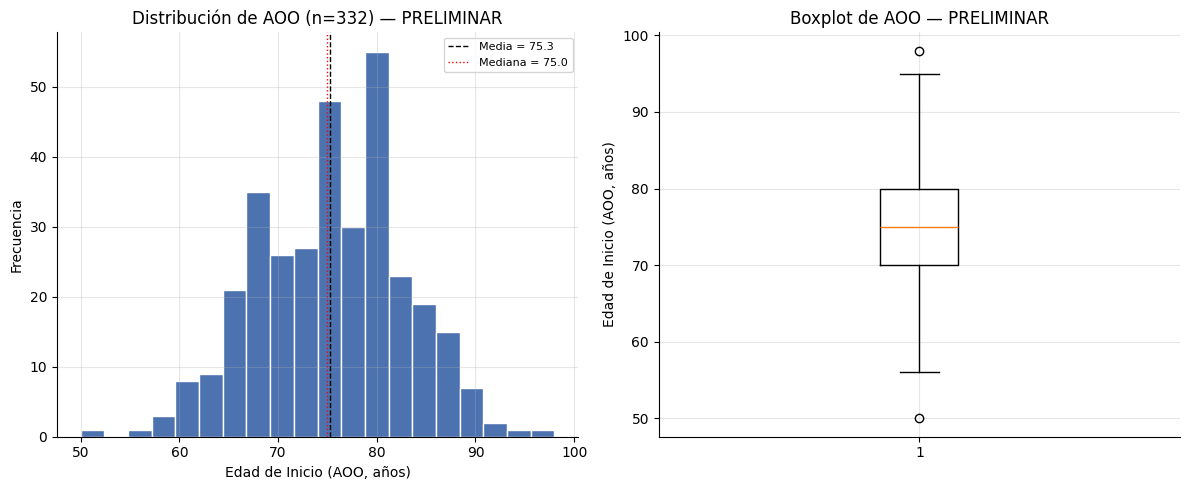

In [28]:
aoo = base_aoo["aoo"]

print("n:", len(aoo)) #PRELIMINAR — 85.2% de la cohorte maestra)
print("Media:", round(aoo.mean(), 2))
print("Mediana:", round(aoo.median(), 2))
print("DE:", round(aoo.std(), 2))
print("Mínimo:", aoo.min())
print("Máximo:", aoo.max())
print("Q1:", aoo.quantile(.25))
print("Q3:", aoo.quantile(.75))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].hist(aoo, bins=20, color="#4C72B0", edgecolor="white")
ax[0].axvline(aoo.mean(), color="black", linestyle="--", linewidth=1, label=f"Media = {aoo.mean():.1f}")
ax[0].axvline(aoo.median(), color="red", linestyle=":", linewidth=1, label=f"Mediana = {aoo.median():.1f}")
ax[0].set_xlabel("Edad de Inicio (AOO, años)")
ax[0].set_ylabel("Frecuencia")
ax[0].set_title(f"Distribución de AOO (n={len(aoo)}) — PRELIMINAR")
ax[0].legend(fontsize=8)

ax[1].boxplot(aoo, vert=True)
ax[1].set_ylabel("Edad de Inicio (AOO, años)")
ax[1].set_title("Boxplot de AOO — PRELIMINAR")

plt.tight_layout()
plt.show()

In [29]:
#Detección de outliers por IQR (NO se eliminan)
q1, q3 = aoo.quantile(0.25), aoo.quantile(0.75)
iqr = q3 - q1
lower_fence, upper_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr

outliers_mask = (aoo < lower_fence) | (aoo > upper_fence)
outlier_ids = base_aoo.loc[aoo[outliers_mask].index, "id"].tolist()
outlier_vals = aoo[outliers_mask]

print(f"Límites IQR: [{lower_fence:.1f}, {upper_fence:.1f}]")
print(f"n outliers detectados (no eliminados): {outliers_mask.sum()}")
if outliers_mask.sum() > 0:
    for i, v in zip(outlier_ids, outlier_vals):
        print(f"  ID {i}: AOO = {v:.0f} años")
print("\nNOTA: estos valores NO se eliminan del dataset. Pueden representar fenotipos de inicio muy temprano")
print("o muy tardío, de particular interés para el estudio de variantes modificadoras.")


Límites IQR: [55.0, 95.0]
n outliers detectados (no eliminados): 2
  ID 407: AOO = 50 años
  ID 500: AOO = 98 años

NOTA: estos valores NO se eliminan del dataset. Pueden representar fenotipos de inicio muy temprano
o muy tardío, de particular interés para el estudio de variantes modificadoras.


In [30]:
#Identificación de posibles fenotipos extremos de interés
p05, p95 = aoo.quantile(0.05), aoo.quantile(0.95)
extremos_tempranos = base_aoo.loc[base_aoo["aoo"] <= p05, ["id", "aoo"]].sort_values("aoo")
extremos_tardios   = base_aoo.loc[base_aoo["aoo"] >= p95, ["id", "aoo"]].sort_values("aoo", ascending=False)

print(f"Percentil 5 = {p05:.1f} años | Percentil 95 = {p95:.1f} años\n")
print("Candidatos a AOO extremadamente temprana (≤ P5):")
print(extremos_tempranos.to_string(index=False))
print("\n")
print("Candidatos a AOO extremadamente tardía (≥ P95):")
print(extremos_tardios.to_string(index=False))
print("\nEstos IDs son de interés prioritario cuando se disponga de la base genética (candidatos a portar variantes moduladoras).")


Percentil 5 = 63.5 años | Percentil 95 = 87.0 años

Candidatos a AOO extremadamente temprana (≤ P5):
 id  aoo
407 50.0
 66 56.0
188 58.0
 16 59.0
409 59.0
303 60.0
275 60.0
 58 60.0
522 60.0
418 60.0
 85 61.0
 75 61.0
681 61.0
679 62.0
298 63.0
 44 63.0
477 63.0


Candidatos a AOO extremadamente tardía (≥ P95):
 id  aoo
500 98.0
511 95.0
469 92.0
306 91.0
506 90.0
422 90.0
238 90.0
320 90.0
467 90.0
322 90.0
487 90.0
 90 88.0
308 88.0
652 88.0
581 88.0
631 88.0
408 87.0
629 87.0
677 87.0
755 87.0

Estos IDs son de interés prioritario cuando se disponga de la base genética (candidatos a portar variantes moduladoras).


## **17. Calidad global de la base integrada**

In [31]:
missing_integrada = pd.DataFrame({
    "n_faltantes": base_full.isna().sum(),
    "pct_faltantes": base_full.isna().mean() * 100,
    "n_disponibles": base_full.notna().sum()
}).sort_values("pct_faltantes", ascending=False)


#dimensiones
print(f"Dimensiones de la base de datos integrada: {base_full.shape[0]} filas, {base_full.shape[1]} columnas")
display(missing_integrada.head(70))

Dimensiones de la base de datos integrada: 391 filas, 160 columnas


,n_faltantes,pct_faltantes,n_disponibles
hx__si_la_respuesta_anterior_es_si_a_que_es_alergico,379,96.930946,12
hx__si_respuesta_anterior_fue_afirmativa_hace_cuantos_anios_fuma,376,96.163683,15
aoo_actualizada,344,87.979540,47
hx__en_que_fecha_le_realizaron_la_cirugia,334,85.421995,57
hx__si_la_respuesta_anterior_fue_si_que_cirugia_le_han_realizado,316,80.818414,75
hx__si_la_respuesta_anterior_es_afirmativa_cuantas_personas_han_tenido_o_tienen_alzheimer_en_su_familia,221,56.521739,170
hx__que_parentesco_tienen_con_usted,217,55.498721,174
aoo_original,106,27.109974,285
hx__antecedentes,92,23.529412,299
hx__si_la_respuesta_anterior_fue_si_que_medicamentos_esta_consumiendo,68,17.391304,323


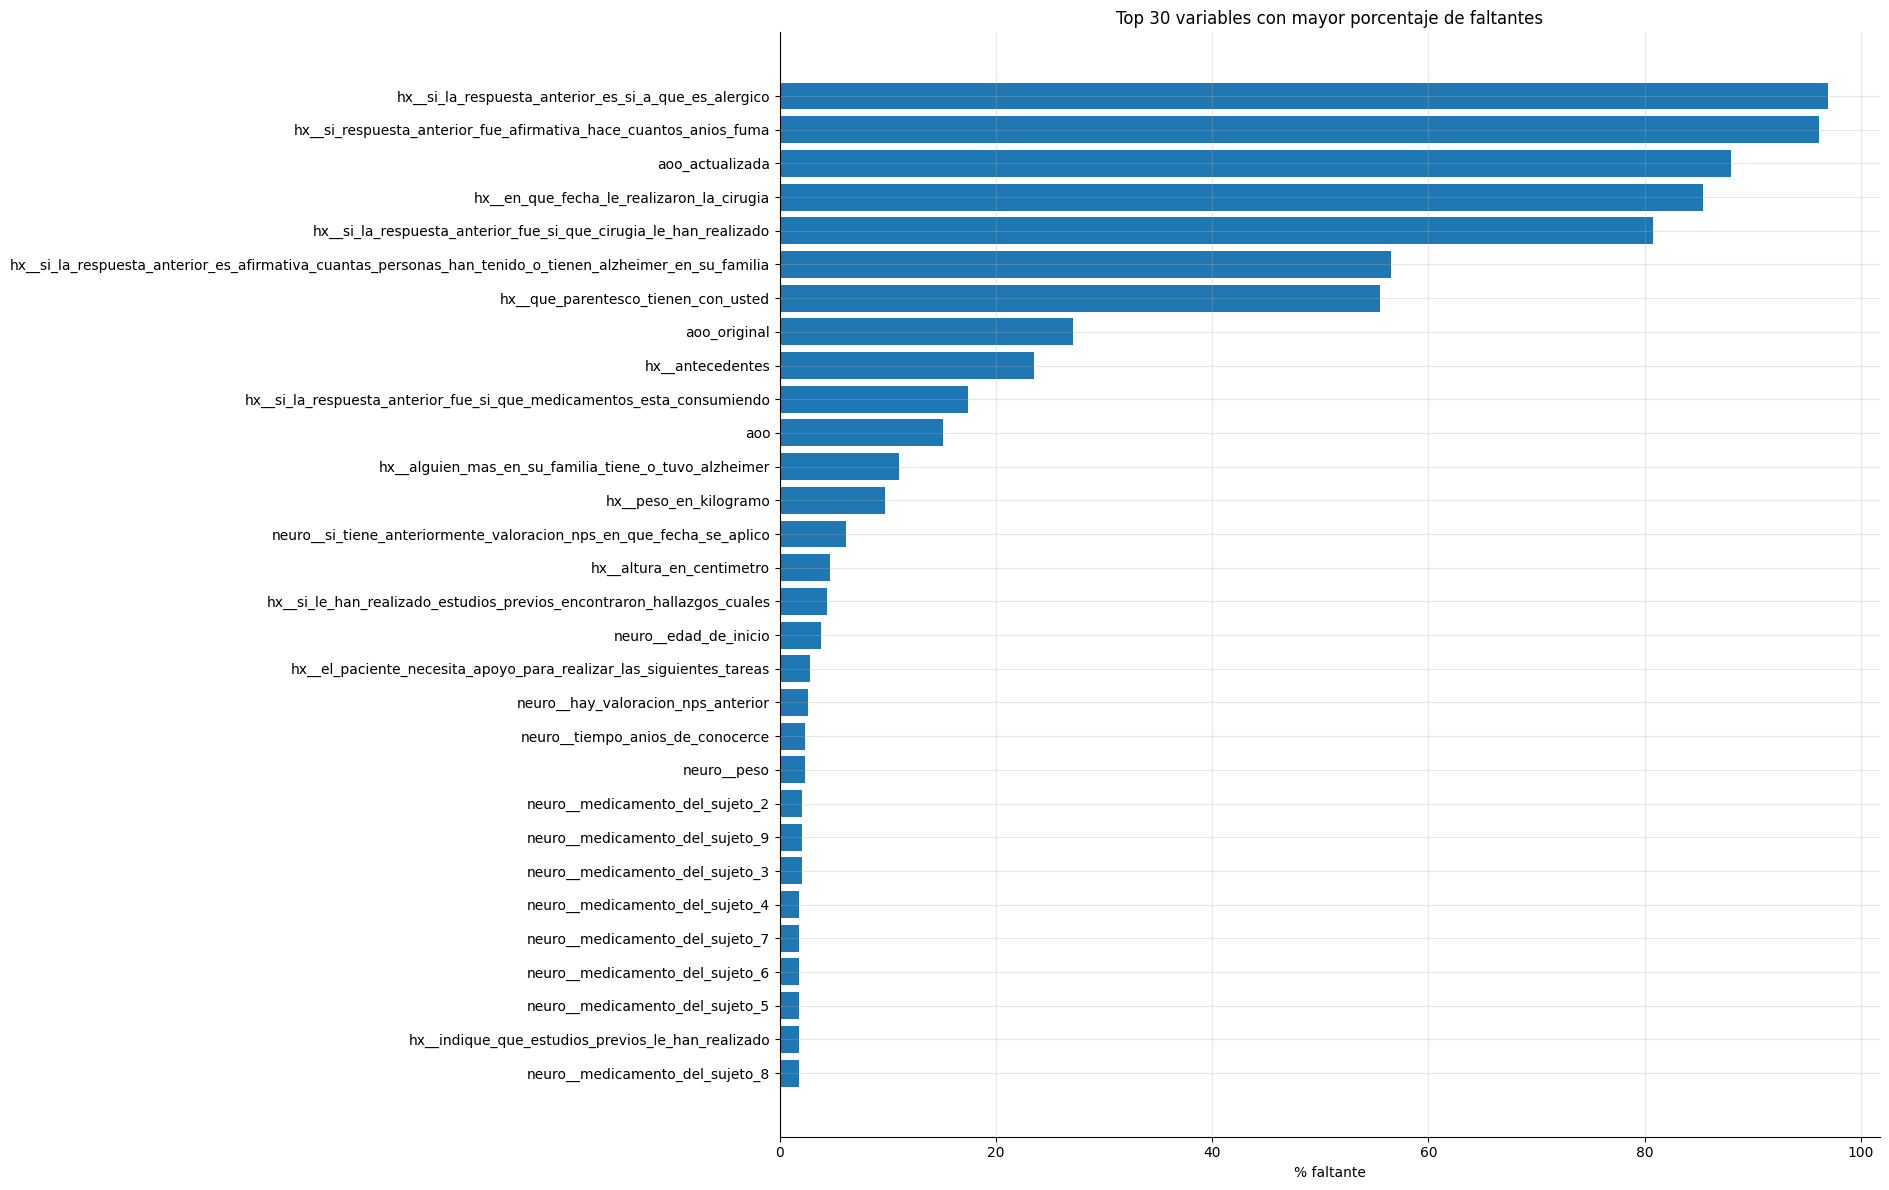

In [32]:
top_missing = missing_integrada.head(30).sort_values("pct_faltantes")

fig, ax = plt.subplots(figsize=(19, 12))
ax.barh(top_missing.index, top_missing["pct_faltantes"])
ax.set_title("Top 30 variables con mayor porcentaje de faltantes")
ax.set_xlabel("% faltante")
plt.tight_layout()
plt.show()

## **18. Variables constantes, casi constantes y cardinalidad**

In [33]:
nunique = base_full.nunique(dropna=True)

constantes = nunique[nunique <= 1]
casi_constantes = nunique[(nunique > 1) & (nunique <= 3)]

print("Constantes:")
display(constantes.to_frame("n_unicos"))

print("\nCon 2 o 3 valores únicos:")
display(casi_constantes.to_frame("n_unicos"))

Constantes:


,n_unicos
neuro__dx,1
neuro__idioma,1
neuro__angioplastia_endarterectomia_stent,1
neuro__bypass_cardiaco_coronario,1
neuro__traumatismo_de_craneo_encefalico_tce,1
neuro__niveles_de_vitamina_d,1
neuro__trastorno_de_estres_postraumatico_tept,1
neuro__trastorno_bipolar,1
neuro__trastorno_obsesivo_compulsivo_toc,1
neuro__trastornos_neuropsiquiatricos_del_desarrollo_por_ejemplo_trastorno_del_espectro_autista_tea_deficit_de_atencion_con_hiperactividad_tdah_dislexia,1



Con 2 o 3 valores únicos:


,n_unicos
hx__usted_fuma,3
hx__sufre_de_algun_tipo_de_alergia,3
neuro__genero,2
neuro__otro_idoma,3
neuro__tipo_de_residencia,3
neuro__lateralidad,3
neuro__ataque_cardiaco_o_paro_cardiaco,3
neuro__fibrilacion_auricular,2
neuro__marcapasos_y_o_desfibrilador,2
neuro__insuficiencia_cardiaca_congestiva,2


## **19. Limpieza especial de tabaquismo**

In [34]:
col_anios_fumando = next(
    (c for c in demo_norm if "numero_total_de_anos_que_ha_fumado" in c),
    None
)

if col_anios_fumando:
    base_full["anios_fumando_limpio"] = pd.to_numeric(
        base_full[col_anios_fumando],
        errors="coerce"
    )

    base_full.loc[
        base_full["anios_fumando_limpio"] == 99,
        "anios_fumando_limpio"
    ] = np.nan

    display(base_full["anios_fumando_limpio"].describe())

if col_anios_fumando is not None:
    print(
        "Valores 99 recodificados como faltantes:",
        (pd.to_numeric(base_full[col_anios_fumando], errors="coerce") == 99).sum()
    )
    display(base_full["anios_fumando_limpio"].value_counts(dropna=False).sort_index())
else:
    print("La variable de años de tabaquismo no se identificó en demo_norm; validar el encabezado original.")

La variable de años de tabaquismo no se identificó en demo_norm; validar el encabezado original.


## **20. Variables neuropsicológicas: exploración y reducción**

Las neuropsicológicas completas se usarán para:

- calidad y faltantes;
- rangos;
- variabilidad;
- correlaciones;
- redundancia;
- selección de representantes por dominio.

No se pretende incluirlas todas en el modelo principal de AOO.

In [35]:
def convertir_numericas_probables(df, cols, umbral=.70):
    convertidas = []
    for c in cols:
        if c not in df.columns:
            continue

        s = df[c]
        n = s.notna().sum()

        if n == 0:
            continue

        sn = pd.to_numeric(
            s.astype(str)
             .str.replace(",", ".", regex=False)
             .str.replace(r"^\s*-\s*$", "", regex=True),
            errors="coerce"
        )

        if sn.notna().sum() / n >= umbral:
            df[c] = sn
            convertidas.append(c)

    return convertidas

convertidas_neuro = convertir_numericas_probables(base_full, neuro_norm)

print("Variables neuro convertidas a numéricas:", len(convertidas_neuro))

Variables neuro convertidas a numéricas: 54


### **20.1. Calidad de todas las variables neuropsicológicas**

In [36]:
neuro_num = [
    c for c in neuro_norm
    if c in base_full.columns and pd.api.types.is_numeric_dtype(base_full[c])
]

calidad_neuro = pd.DataFrame({
    "variable": neuro_num,
    "n_disponibles": [base_full[c].notna().sum() for c in neuro_num],
    "pct_faltantes": [base_full[c].isna().mean() * 100 for c in neuro_num],
    "n_unicos": [base_full[c].nunique(dropna=True) for c in neuro_num],
    "media": [base_full[c].mean() for c in neuro_num],
    "mediana": [base_full[c].median() for c in neuro_num],
    "DE": [base_full[c].std() for c in neuro_num]
})

display(calidad_neuro.sort_values(["pct_faltantes", "n_unicos"]))

,variable,n_disponibles,pct_faltantes,n_unicos,media,mediana,DE
52,neuro__fast,386,1.278772,5,3.512953,3.0,0.835006
51,neuro__ikatz,386,1.278772,7,1.621762,0.0,2.166317
49,neuro__barthel,386,1.278772,12,37.404145,50.0,18.130333
50,neuro__lawton_y_brody,386,1.278772,14,2.707254,2.0,4.547561
53,neuro__esc_deterioroglobal,385,1.534527,6,3.841558,4.0,0.552775
1,neuro__mmse,383,2.046036,31,16.328982,19.0,9.533154
47,neuro__quejas_subjetivas,381,2.557545,7,2.123360,2.0,2.147950
0,neuro__hay_valoracion_nps_anterior,380,2.813299,2,0.010526,0.0,0.102191
18,neuro__fcrocop,380,2.813299,36,8.094737,2.0,10.860666
21,neuro__taavrey1,378,3.324808,7,1.658730,2.0,1.488217


### **20.2. Exploración neuropsicológica por dominios**

In [37]:
for grupo, vars_orig in GRUPOS_NEURO.items():
    vars_norm = [
        f"neuro__{mapa_neuro_dict[v]}"
        for v in vars_orig
        if v in mapa_neuro_dict
    ]

    vars_num = [
        c for c in vars_norm
        if c in base_full.columns and pd.api.types.is_numeric_dtype(base_full[c])
    ]

    print("\n" + "="*90)
    print(grupo.upper())
    print("="*90)

    if vars_num:
        display(base_full[vars_num].describe().T)

        if len(vars_num) >= 2:
            display(base_full[vars_num].corr(method="spearman"))


METADATOS_NPS

COGNICION_GLOBAL


,count,mean,std,min,25%,50%,75%,max
neuro__mmse,383.0,16.328982,9.533154,0.0,10.0,19.0,24.0,30.0



MEMORIA


,count,mean,std,min,25%,50%,75%,max
neuro__cmweschler,375.0,1.858667,2.934904,0.0,0.00,0.0,3.00,33.0
neuro__taavrey1,378.0,1.658730,1.488217,0.0,0.00,2.0,3.00,6.0
neuro__taavrey2,378.0,2.417989,1.778115,0.0,1.00,2.0,4.00,8.0
neuro__taavrey3,378.0,2.867725,1.999593,0.0,1.00,3.0,4.00,8.0
neuro__taavrey4,378.0,3.015873,2.170397,0.0,2.00,3.0,4.00,13.0
neuro__taavrey5,378.0,3.182540,2.311547,0.0,1.00,3.0,5.00,11.0
neuro__taavreyb1,378.0,1.357143,1.279076,0.0,0.00,1.0,2.00,6.0
neuro__taavrey6,378.0,1.494709,1.751460,0.0,0.00,1.0,2.75,9.0
neuro__taavrey7,377.0,0.838196,1.728308,0.0,0.00,0.0,1.00,19.0
neuro__taavrey_rec_si,374.0,7.275401,5.652738,0.0,0.25,8.0,13.00,15.0


,neuro__cmweschler,neuro__taavrey1,neuro__taavrey2,neuro__taavrey3,neuro__taavrey4,neuro__taavrey5,neuro__taavreyb1,neuro__taavrey6,neuro__taavrey7,neuro__taavrey_rec_si,neuro__taavrey_rec_no
neuro__cmweschler,1.000000,0.469879,0.539891,0.529367,0.514201,0.474982,0.458395,0.357846,0.278073,0.225089,0.347622
neuro__taavrey1,0.469879,1.000000,0.731974,0.717217,0.721378,0.711455,0.567748,0.545083,0.458469,0.408675,0.319614
neuro__taavrey2,0.539891,0.731974,1.000000,0.806190,0.810309,0.822857,0.580401,0.597287,0.459384,0.471255,0.378066
neuro__taavrey3,0.529367,0.717217,0.806190,1.000000,0.849851,0.851307,0.601325,0.658403,0.537479,0.486083,0.382829
neuro__taavrey4,0.514201,0.721378,0.810309,0.849851,1.000000,0.860224,0.639927,0.625032,0.455259,0.476735,0.390116
neuro__taavrey5,0.474982,0.711455,0.822857,0.851307,0.860224,1.000000,0.580167,0.627194,0.505612,0.476201,0.377784
neuro__taavreyb1,0.458395,0.567748,0.580401,0.601325,0.639927,0.580167,1.000000,0.445547,0.378432,0.362200,0.382764
neuro__taavrey6,0.357846,0.545083,0.597287,0.658403,0.625032,0.627194,0.445547,1.000000,0.629730,0.455736,0.249978
neuro__taavrey7,0.278073,0.458469,0.459384,0.537479,0.455259,0.505612,0.378432,0.629730,1.000000,0.329212,0.143855
neuro__taavrey_rec_si,0.225089,0.408675,0.471255,0.486083,0.476735,0.476201,0.362200,0.455736,0.329212,1.000000,-0.162847


...

,count,mean,std,min,25%,50%,75%,max
neuro__tsmydoral,361.0,3.689751,7.405938,0.0,0.0,0.0,4.0,42.0
neuro__tsmyd_escr,361.0,2.933518,5.778409,0.0,0.0,0.0,3.0,35.0
neuro__benton,363.0,0.876033,1.326964,0.0,0.0,0.0,1.0,7.0


,neuro__tsmydoral,neuro__tsmyd_escr,neuro__benton
neuro__tsmydoral,1.000000,0.923176,0.572756
neuro__tsmyd_escr,0.923176,1.000000,0.579798
neuro__benton,0.572756,0.579798,1.000000



FUNCIONAL_AFECTIVO_QUEJAS


,count,mean,std,min,25%,50%,75%,max
neuro__yesavage,370.0,6.348649,5.894746,0.0,1.0,4.0,10.0,16.0
neuro__barthel,386.0,37.404145,18.130333,0.0,25.0,50.0,50.0,50.0
neuro__lawton_y_brody,386.0,2.707254,4.547561,0.0,1.0,2.0,3.0,30.0
neuro__ikatz,386.0,1.621762,2.166317,0.0,0.0,0.0,3.0,6.0
neuro__fast,386.0,3.512953,0.835006,2.0,3.0,3.0,4.0,16.0


,neuro__yesavage,neuro__barthel,neuro__lawton_y_brody,neuro__ikatz,neuro__fast
neuro__yesavage,1.000000,-0.398215,0.349314,0.399162,0.330680
neuro__barthel,-0.398215,1.000000,-0.602966,-0.923891,-0.716361
neuro__lawton_y_brody,0.349314,-0.602966,1.000000,0.597022,0.658345
neuro__ikatz,0.399162,-0.923891,0.597022,1.000000,0.728843
neuro__fast,0.330680,-0.716361,0.658345,0.728843,1.000000


### **20.3. Correlaciones y redundancia neuropsicológica**

In [38]:
corr_cols = [
    c for c in neuro_num
    if base_full[c].notna().sum() >= max(30, int(.50 * len(base_full)))
    and base_full[c].nunique(dropna=True) > 3
]

corr_neuro = base_full[corr_cols].corr(method="spearman")

pares = []
for i in range(len(corr_neuro.columns)):
    for j in range(i + 1, len(corr_neuro.columns)):
        rho = corr_neuro.iloc[i, j]
        if pd.notna(rho):
            pares.append([
                corr_neuro.index[i],
                corr_neuro.columns[j],
                rho,
                abs(rho)
            ])

pares_corr = pd.DataFrame(
    pares,
    columns=["variable_1", "variable_2", "rho_spearman", "abs_rho"]
).sort_values("abs_rho", ascending=False)

display(pares_corr.head(60))

,variable_1,variable_2,rho_spearman,abs_rho
1074,neuro__tbn_espontanea,neuro__tbn_total,0.971759,0.971759
1317,neuro__barthel,neuro__ikatz,-0.923891,0.923891
1206,neuro__tsmydoral,neuro__tsmyd_escr,0.923176,0.923176
1136,neuro__tspal,neuro__tscol,0.905068,0.905068
1155,neuro__tscol,neuro__tspalcol,0.892114,0.892114
891,neuro__taavrey4,neuro__taavrey5,0.860224,0.860224
338,neuro__fvff,neuro__fvfa,0.856386,0.856386
862,neuro__taavrey3,neuro__taavrey5,0.851307,0.851307
861,neuro__taavrey3,neuro__taavrey4,0.849851,0.849851
467,neuro__fvfa,neuro__fvfs,0.849638,0.849638


In [39]:
redundantes_fuertes = pares_corr[pares_corr["abs_rho"] >= .80]
display(redundantes_fuertes)

,variable_1,variable_2,rho_spearman,abs_rho
1074,neuro__tbn_espontanea,neuro__tbn_total,0.971759,0.971759
1317,neuro__barthel,neuro__ikatz,-0.923891,0.923891
1206,neuro__tsmydoral,neuro__tsmyd_escr,0.923176,0.923176
1136,neuro__tspal,neuro__tscol,0.905068,0.905068
1155,neuro__tscol,neuro__tspalcol,0.892114,0.892114
891,neuro__taavrey4,neuro__taavrey5,0.860224,0.860224
338,neuro__fvff,neuro__fvfa,0.856386,0.856386
862,neuro__taavrey3,neuro__taavrey5,0.851307,0.851307
861,neuro__taavrey3,neuro__taavrey4,0.849851,0.849851
467,neuro__fvfa,neuro__fvfs,0.849638,0.849638


### **20.4. Variables clínicas/neuropsicológicas prioritarias**

Se priorizan:

- MMSE
- MoCA
- FAST

Estas sirven principalmente para **caracterización clínica y análisis secundario**.

No deben incluirse automáticamente como predictores del AOO, porque pueden haberse medido después del inicio de la enfermedad.

In [40]:
core_vars = [
    "neuro__mmse",
    "moca__moca",
    "neuro__fast"
]

core_vars = [
    c for c in core_vars
    if c in base_full.columns
]

print(core_vars)
for c in core_vars:
    base_full[c] = pd.to_numeric(
        base_full[c],
        errors="coerce"
    )

display(
    base_full[core_vars]
    .describe()
    .T
)

display(
    base_full[core_vars]
    .corr(method="spearman")
)

['neuro__mmse', 'moca__moca', 'neuro__fast']


,count,mean,std,min,25%,50%,75%,max
neuro__mmse,383.0,16.328982,9.533154,0.0,10.0,19.0,24.0,30.0
moca__moca,387.0,8.914729,7.012606,0.0,3.0,8.0,15.0,28.0
neuro__fast,386.0,3.512953,0.835006,2.0,3.0,3.0,4.0,16.0


,neuro__mmse,moca__moca,neuro__fast
neuro__mmse,1.000000,0.832309,-0.526747
moca__moca,0.832309,1.000000,-0.525540
neuro__fast,-0.526747,-0.525540,1.000000


### **20.5. Tabla para justificar reducción neuropsicológica**

Se evalúa la calidad de las variables neuropsicológicas considerando su porcentaje de datos faltantes y su variabilidad. Se consideran inicialmente de alta completitud aquellas con ≤10% de valores faltantes y con variabilidad suficiente aquellas que presentan más de 5 valores únicos. Estos criterios no determinan por sí solos la selección final, sino que sirven como apoyo junto con la relevancia clínica, la redundancia entre pruebas y el riesgo de data leakage.

In [41]:
tabla_seleccion_neuro = calidad_neuro.copy()

tabla_seleccion_neuro["alta_completitud"] = tabla_seleccion_neuro["pct_faltantes"] <= 10
tabla_seleccion_neuro["variabilidad_suficiente"] = tabla_seleccion_neuro["n_unicos"] > 5

display(
    tabla_seleccion_neuro.sort_values(
        ["alta_completitud", "variabilidad_suficiente", "pct_faltantes"],
        ascending=[False, False, True]
    )
)

,variable,n_disponibles,pct_faltantes,n_unicos,media,mediana,DE,alta_completitud,variabilidad_suficiente
49,neuro__barthel,386,1.278772,12,37.404145,50.0,18.130333,True,True
50,neuro__lawton_y_brody,386,1.278772,14,2.707254,2.0,4.547561,True,True
51,neuro__ikatz,386,1.278772,7,1.621762,0.0,2.166317,True,True
53,neuro__esc_deterioroglobal,385,1.534527,6,3.841558,4.0,0.552775,True,True
1,neuro__mmse,383,2.046036,31,16.328982,19.0,9.533154,True,True
47,neuro__quejas_subjetivas,381,2.557545,7,2.123360,2.0,2.147950,True,True
18,neuro__fcrocop,380,2.813299,36,8.094737,2.0,10.860666,True,True
21,neuro__taavrey1,378,3.324808,7,1.658730,2.0,1.488217,True,True
22,neuro__taavrey2,378,3.324808,9,2.417989,2.0,1.778115,True,True
23,neuro__taavrey3,378,3.324808,9,2.867725,3.0,1.999593,True,True


## **21. Análisis univariado**

La unidad de análisis es el paciente de la cohorte maestra HXGEN (`base_full`). Se conservan los 391 registros, incluidos los que no tienen AOO. Esta sección describe cada variable por separado; no prueba asociaciones con AOO ni selecciona predictores. Los porcentajes válidos excluyen faltantes; los porcentajes totales usan toda la cohorte. Las mediciones contemporáneas o posteriores al inicio describen el estado clínico, sin atribuirles temporalidad previa.

**Nota metodológica sobre secciones previas.** En las listas `GRUPOS_DEMO` y `GRUPOS_NEURO` algunos textos no coinciden exactamente con los encabezados del Excel; esto puede dejar variables fuera de los subgrupos. Además, `base_aoo` se creó antes de algunas columnas de auditoría y transformaciones de `base_full`, y las conversiones numéricas de la sección 20 pueden generar faltantes nuevos. Importa porque una selección automática por nombre, por dtype o por `base_aoo` podría omitir variables o usar versiones distintas. La celda 59 de tabaquismo también buscaba un nombre que no existe y podía causar `KeyError`; en esta copia se añadió una guarda explícita y una advertencia, sin recodificar valores desconocidos. Aquí se propone resolver nombres con el diccionario de columnas realmente integradas, verificar las conversiones y usar `base_full` como única fuente para descripciones. No se altera la lógica anterior.


### **21.1. Criterios metodológicos, inventario y funciones auxiliares**

La clasificación analítica usa el significado de la variable y los valores observados, no sólo el dtype. Las codificaciones ambiguas se conservan como categorías originales y se señalan para validación. Identificadores, columnas derivadas de AOO y auditoría del merge se excluyen del inventario clínico. Los grupos provienen de `diccionario`, con rescate por coincidencia normalizada de los encabezados ya documentados.

Los dos tonos de las barras se usan sólo para facilitar la lectura; no representan grupos clínicos.


In [42]:
from IPython.display import display, Markdown
from textwrap import fill

assert len(base_full) == 391 and base_full['id'].is_unique, 'Revisar la cohorte maestra antes de continuar.'
assert 'aoo' in base_full and 'riesgo_leakage_aoo' in diccionario

def etiqueta_bonita(col):
    especiales = {'aoo':'Edad de inicio de Alzheimer (AOO)', 'neuro__mmse':'MMSE',
                  'moca__moca':'MoCA', 'neuro__fast':'FAST',
                  'anios_fumando_limpio':'Años de tabaquismo (99 = desconocido)'}
    if col in especiales: return especiales[col]
    s = col.removeprefix('neuro__').removeprefix('hx__').removeprefix('moca__')
    return s.replace('_', ' ').strip().capitalize()

def columna_integrada(fila):
    prefijo = {'neuropsicologia':'neuro__', 'moca':'moca__', 'hxgen':'hx__'}.get(fila['fuente'], '')
    return prefijo + fila['normalizada']

inventario = diccionario.copy()
inventario['columna'] = inventario.apply(columna_integrada, axis=1)
inventario = inventario[inventario['columna'].isin(base_full.columns)].copy()
inventario['etiqueta'] = inventario['columna'].map(etiqueta_bonita)

# Se reusan los subgrupos existentes; se rescatan discrepancias de espacios
# usando el normalizador ya definido y se dejan visibles los casos inciertos.
def subgrupo_revisado(fila):
    if fila['subgrupo']: return fila['subgrupo']
    clave = normalizar_para_match(fila['original'])
    # El encabezado real y GRUPOS_DEMO difieren en un espacio antes de
    # '(comparten)'. La pregunta corresponde inequívocamente a historia familiar.
    if fila['fuente'] == 'neuropsicologia' and 'miembros afectados de la familia' in clave and 'padres biologicos' in clave:
        return 'historia_familiar'
    grupos = GRUPOS_NEURO if fila['columna'] in neuro_norm else GRUPOS_DEMO
    for nombre, variables in grupos.items():
        if clave in {normalizar_para_match(v) for v in variables}: return nombre
    return 'sin_asignacion_validada'

inventario['familia'] = inventario.apply(subgrupo_revisado, axis=1)
binarias = ('genero','sexo','vive_el_informante','ha_fumado','ataque_cardiaco','fibrilacion',
            'bypass','marcapasos','insuficiencia','enfermedad_cerebro','parkinson',
            'convulsiones','traumatismo','diabetes','cancer','hipercholesterolemia',
            'hipertension','deficiencia','enfermedad_tiroidea','artritis','artrosis',
            'osteoporosis','incontinencia','apnea','trastorno','esquizofrenia',
            'depresion','ansiedad','valoracion_nps_anterior')
ordinales = ('fast','nivel_educativo','nivel_de_independencia','esc_deterioroglobal',
             'frecuencia_visita','frecuencia_tiene_contacto')
continuas = ('edad','peso','talla','tiempo_anos','anos_que_ha_fumado','anios_fumando')

def tipo_analitico(fila):
    c = fila['columna']; nombre = fila['normalizada']; s = base_full[c]
    if nombre in ('codigo','id') or c == 'id': return 'identificador'
    if nombre in ('edad_de_inicio','edad_de_inicio_actualizada'): return 'variable auxiliar del EDA'
    if any(x in nombre for x in ('medicamento_del_sujeto','otro_idoma','mes_y_ano_de_nacimiento')): return 'texto libre / alta cardinalidad'
    if nombre in ('dx','idioma','estado_civil','estado_habitacional','tipo_de_residencia',
                  'lateralidad','relacion_del_informante','familiar_afectado'): return 'categórica nominal'
    if any(x in nombre for x in ordinales): return 'ordinal'
    if any(x in nombre for x in binarias) and s.nunique(dropna=True) <= 3: return 'categórica binaria'
    if nombre in ('edad','peso','talla','peso_en_kilogramo','altura_en_centimetro','tiempo_anos_de_conocerce') or nombre.startswith('numero_total_de_anios_que_ha_fumado'): return 'cuantitativa continua'
    if fila['fuente'] == 'neuropsicologia' and fila['grupo_principal'] == 'neuropsicologica':
        if any(x in nombre for x in ('fecha','quejas_subjetivas')): return 'texto libre / alta cardinalidad'
        return 'cuantitativa discreta' if pd.to_numeric(s, errors='coerce').notna().sum() >= .8*s.notna().sum() else 'categórica nominal'
    if c == 'moca__moca': return 'cuantitativa discreta'
    if nombre in ('enfermedad_actual','que_sintomas_presenta','antecedentes'): return 'texto libre / alta cardinalidad'
    if s.nunique(dropna=True) <= 12: return 'categórica nominal'
    return 'texto libre / alta cardinalidad'

inventario['tipo_analitico'] = inventario.apply(tipo_analitico, axis=1)
inventario['n_valido'] = inventario['columna'].map(base_full.notna().sum())
inventario['n_faltante'] = len(base_full) - inventario['n_valido']
inventario['n_unicos_cohorte'] = inventario['columna'].map(base_full.nunique(dropna=True))
inventario['observacion'] = np.where(inventario['tipo_analitico'].eq('categórica nominal') &
                                    inventario['columna'].map(lambda c: pd.api.types.is_numeric_dtype(base_full[c])),
                                    'Código numérico: significado/orden requiere validación', '')
display(inventario[['etiqueta','fuente','familia','tipo_analitico','n_valido','n_faltante',
                   'n_unicos_cohorte','riesgo_leakage_aoo','observacion']].reset_index(drop=True))


,etiqueta,fuente,familia,tipo_analitico,n_valido,n_faltante,n_unicos_cohorte,riesgo_leakage_aoo,observacion
0,Genero,neuropsicologia,sociodemograficas,categórica binaria,386,5,2,Bajo,
1,Dx,neuropsicologia,identificacion_diagnostico,categórica nominal,386,5,1,Bajo / revisar temporalidad,Código numérico: significado/orden requiere validación
2,Mes y anio de nacimiento,neuropsicologia,sociodemograficas,texto libre / alta cardinalidad,385,6,372,Bajo / revisar temporalidad,
3,Edad,neuropsicologia,sociodemograficas,cuantitativa continua,386,5,40,Bajo / revisar temporalidad,
4,Idioma,neuropsicologia,sociodemograficas,categórica nominal,386,5,1,Bajo,Código numérico: significado/orden requiere validación
5,Otro idoma,neuropsicologia,sociodemograficas,texto libre / alta cardinalidad,386,5,3,Bajo,
6,Nivel educativo,neuropsicologia,sociodemograficas,ordinal,385,6,9,Bajo,
7,Estado civil,neuropsicologia,sociodemograficas,categórica nominal,386,5,6,Bajo / revisar temporalidad,Código numérico: significado/orden requiere validación
8,Estado habitacional,neuropsicologia,sociodemograficas,categórica nominal,386,5,7,Bajo / revisar temporalidad,Código numérico: significado/orden requiere validación
9,Nivel de independencia,neuropsicologia,sociodemograficas,ordinal,385,6,5,Bajo / revisar temporalidad,


In [43]:
COLOR = '#315e73'; COLOR_SUAVE = '#b8cbd1'
BEIGE = '#EDE8D0'
FONDO_FIGURA = '#f6f5f2'
FONDO_PANEL = '#eeefed'
def tabla_frecuencias_categorica(s):
    valido = s.dropna(); n = len(s); nv = len(valido); falt = n-nv
    cuenta = valido.astype(str).value_counts(sort=False)
    tabla = pd.DataFrame({'categoria':cuenta.index, 'frecuencia_absoluta':cuenta.values})
    tabla['porcentaje_valido'] = (100*tabla['frecuencia_absoluta']/nv).round(1) if nv else np.nan
    tabla['porcentaje_total'] = (100*tabla['frecuencia_absoluta']/n).round(1) if n else np.nan
    tabla['n_faltantes'] = falt
    return tabla

def resumen_numerico(s):
    x = pd.to_numeric(s, errors='coerce').dropna(); n = len(s); q1=x.quantile(.25); q3=x.quantile(.75)
    return pd.DataFrame([{'n_valido':len(x),'n_faltante':n-len(x),
        'porcentaje_faltante':round(100*(n-len(x))/n,1) if n else np.nan,
        'media':x.mean(),'mediana':x.median(),'DE':x.std(),'minimo':x.min(),
        'Q1':q1,'Q3':q3,'maximo':x.max(),'RIQ':q3-q1,
        'CV':x.std()/x.mean() if len(x)>1 and x.mean()!=0 else np.nan}]).round(2)

def tabla_frecuencias_numerica(s, bins=None):
    x = pd.to_numeric(s, errors='coerce').dropna()
    if x.empty: return pd.DataFrame(columns=['intervalo','fi','hi','Fi','porcentaje_acumulado'])
    if bins is None: bins = max(5,min(18,int(np.ceil(1+3.322*np.log10(len(x))))))
    cortes = pd.cut(x, bins=bins, include_lowest=True).value_counts(sort=False)
    out = pd.DataFrame({'intervalo':cortes.index.astype(str),'fi':cortes.values})
    out['hi'] = (out.fi/len(x)).round(3); out['Fi'] = out.fi.cumsum()
    out['porcentaje_acumulado'] = (100*out.Fi/len(x)).round(1)
    return out

def grafico_categorica(s, titulo, ordinal=False, max_categorias=12):
    t = tabla_frecuencias_categorica(s)
    if t.empty: return
    if ordinal:
        numeros = pd.to_numeric(t.categoria, errors='coerce')
        if numeros.notna().all(): t=t.assign(_orden=numeros).sort_values('_orden')
    else: t=t.sort_values('frecuencia_absoluta',ascending=False)
    resto=max(0,len(t)-max_categorias); t=t.head(max_categorias)
    fig,ax=plt.subplots(figsize=(10,max(3.5,.5*len(t)+1)))
    ax.barh(range(len(t)),t.frecuencia_absoluta,color=COLOR)
    ax.set_yticks(range(len(t)),[fill(str(v),35) for v in t.categoria]); ax.invert_yaxis()
    ax.set_xlim(0,max(t.frecuencia_absoluta)*1.3 if len(t) else 1)
    for i,row in enumerate(t.itertuples()): ax.text(row.frecuencia_absoluta+.01*ax.get_xlim()[1],i,
        f'{row.frecuencia_absoluta} ({row.porcentaje_valido:.1f}%)',va='center',fontsize=9)
    ax.set_xlabel('Pacientes'); ax.set_title(titulo,loc='left',fontweight='bold')
    ax.grid(axis='x',alpha=.2); ax.grid(axis='y',visible=False)
    if resto: ax.text(0,-.14,f'{resto} categorías adicionales en la tabla; alta cardinalidad.',transform=ax.transAxes)
    plt.tight_layout(); plt.show()

def grafico_numerico(s,titulo,discreta=False):
    x=pd.to_numeric(s,errors='coerce').dropna()
    if x.empty: return
    k=max(5,min(18,int(np.ceil(1+3.322*np.log10(len(x))))))
    if discreta and x.nunique()<=20: bins=np.arange(np.floor(x.min())-.5,np.ceil(x.max())+1.5)
    else: bins=k
    fig,ax=plt.subplots(1,2,figsize=(12,4))
    ax[0].hist(x,bins=bins,color=COLOR,edgecolor='white'); ax[0].set_ylabel('Pacientes')
    ax[0].set_xlabel(titulo); ax[0].set_title('Distribución',loc='left')
    ax[1].boxplot(x,vert=False,patch_artist=True,boxprops={'facecolor':COLOR_SUAVE})
    ax[1].set_xlabel(titulo); ax[1].set_yticks([]); ax[1].set_title('Mediana, cuartiles y extremos',loc='left')
    for a in ax: a.grid(axis='x',alpha=.2)
    fig.suptitle(titulo,fontweight='bold'); plt.tight_layout(); plt.show()

def analisis_univariado(col,tipo,mostrar_grafico=True):
    s=base_full[col]; titulo=etiqueta_bonita(col)
    print(f'\n{titulo} | {tipo} | n válido={s.notna().sum()}/{len(s)}')
    if tipo in ('categórica nominal','categórica binaria','ordinal'):
        t=tabla_frecuencias_categorica(s); display(t)
        if mostrar_grafico: grafico_categorica(s,titulo,tipo=='ordinal')
    elif tipo.startswith('cuantitativa'):
        display(resumen_numerico(s))
        if mostrar_grafico: grafico_numerico(s,titulo,tipo.endswith('discreta'))
    else:
        print(f'Alta cardinalidad / texto: {s.nunique(dropna=True)} valores únicos; se omite gráfico individual.')
        display(tabla_frecuencias_categorica(s).sort_values('frecuencia_absoluta',ascending=False).head(10))

def hallazgos_familia(cols):
    if not cols: display(Markdown('Sin variables integradas asignadas con seguridad a esta familia.')); return
    frases=[]
    for col in cols:
        s=base_full[col]; falt=100*s.isna().mean(); tipo=inventario.set_index('columna').loc[col,'tipo_analitico']
        if falt>=30: frases.append(f'**{etiqueta_bonita(col)}:** {falt:.1f}% de faltantes.')
        elif s.nunique(dropna=True)<=1: frases.append(f'**{etiqueta_bonita(col)}:** sin variación observable.')
        elif tipo in ('categórica nominal','categórica binaria','ordinal'):
            v=s.dropna().astype(str).value_counts()
            if len(v): frases.append(f'**{etiqueta_bonita(col)}:** predomina «{v.index[0]}» ({100*v.iloc[0]/v.sum():.1f}% de válidos).')
        elif tipo.startswith('cuantitativa'):
            x=pd.to_numeric(s,errors='coerce').dropna()
            if len(x): frases.append(f'**{etiqueta_bonita(col)}:** mediana {x.median():.1f}; rango {x.min():.1f}–{x.max():.1f}.')
        else: frases.append(f'**{etiqueta_bonita(col)}:** {s.nunique(dropna=True)} valores distintos; se resume sin gráfico.')
    display(Markdown('  \n'.join(frases)))


# Vista compacta por familia: una tabla consolidada y paneles de hasta seis variables.
# El 99 de años de tabaquismo se interpreta como desconocido sólo para esta vista.
def serie_univariada(col):
    s=base_full[col]
    if col.startswith('neuro__numero_total_de_anios_que_ha_fumado'):
        return pd.to_numeric(s,errors='coerce').replace(99,np.nan)
    return s

def etiqueta_categoria(v):
    texto=str(v)
    if texto.endswith('.0'):
        try: texto=str(int(float(texto)))
        except ValueError: pass
    return fill(texto,25)

def panel_categorico(ax, s, titulo, ordinal=False):
    t=tabla_frecuencias_categorica(s)
    if t.empty:
        ax.text(.5,.5,'Sin datos válidos',ha='center',va='center',transform=ax.transAxes)
        ax.set_title(fill(titulo,34),loc='left',fontsize=10,fontweight='bold'); return
    if ordinal:
        orden=pd.to_numeric(t.categoria,errors='coerce')
        if orden.notna().all(): t=t.assign(_orden=orden).sort_values('_orden')
    else: t=t.sort_values('frecuencia_absoluta',ascending=False)
    resto=max(0,len(t)-7); t=t.head(7).iloc[::-1]
    y=np.arange(len(t)); pct=t.porcentaje_valido.to_numpy(dtype=float)
    ax.set_facecolor(FONDO_PANEL)
    colores = [COLOR if j % 2 == 0 else BEIGE for j in range(len(t))]
    ax.barh(y,pct,height=.66,color=colores,edgecolor=COLOR,linewidth=.55,zorder=3)
    ax.set_yticks(y,[etiqueta_categoria(v) for v in t.categoria])
    ax.set_xlim(0,112); ax.set_xticks([0,25,50,75,100]); ax.set_xlabel('% válido',fontsize=8)
    for yy,row in zip(y,t.itertuples()):
        xpos=min(row.porcentaje_valido+2,101)
        ax.text(xpos,yy,f'{row.frecuencia_absoluta} ({row.porcentaje_valido:.1f}%)',
                va='center',ha='left',fontsize=8)
    ax.set_title(fill(titulo,60),loc='left',fontsize=11,fontweight='bold',pad=10)
    ax.grid(axis='x',color='#d8dcda',lw=.8,zorder=0); ax.grid(axis='y',visible=False)
    ax.spines[['top','right','left']].set_visible(False)
    ax.tick_params(axis='y',length=0,labelsize=9)
    if resto: ax.text(0,-.28,f'+{resto} categorías: ver tabla',transform=ax.transAxes,fontsize=8)

def panel_numerico(ax, s, titulo, discreta=False):
    x=pd.to_numeric(s,errors='coerce').dropna()
    ax.set_title(fill(titulo,60),loc='left',fontsize=11,fontweight='bold',pad=10)
    if x.empty:
        ax.text(.5,.5,'Sin datos válidos',ha='center',va='center',transform=ax.transAxes); return
    k=max(5,min(18,int(np.ceil(1+3.322*np.log10(len(x))))))
    bins=np.arange(np.floor(x.min())-.5,np.ceil(x.max())+1.5) if discreta and x.nunique()<=20 else k
    ax.set_facecolor(FONDO_PANEL)
    ax.hist(x,bins=bins,color=COLOR,edgecolor=FONDO_PANEL,linewidth=.9)
    ax.axvline(x.median(),color='#8d806c',ls='--',lw=2,label=f'Mediana {x.median():.1f}')
    ax.legend(frameon=False,fontsize=8,loc='upper right')
    ax.set_ylabel('Pacientes',fontsize=8); ax.set_xlabel('Valor observado',fontsize=8)
    ax.grid(axis='y',color='#d8dcda',lw=.8); ax.grid(axis='x',visible=False)
    ax.spines[['top','right']].set_visible(False)

def analisis_familia(columnas, titulo):
    if not columnas:
        print('Sin variables integradas asignadas con seguridad.'); return
    meta=inventario.set_index('columna')
    filas_cat=[]; filas_num=[]; filas_text=[]; graficas=[]
    for col in columnas:
        s=serie_univariada(col); tipo=meta.loc[col,'tipo_analitico']; nombre=etiqueta_bonita(col)
        n_falt=int(s.isna().sum()); n_val=len(s)-n_falt
        if tipo in ('categórica nominal','categórica binaria','ordinal'):
            t=tabla_frecuencias_categorica(s)
            for row in t.itertuples():
                filas_cat.append({'variable':nombre,'categoría':row.categoria,'n':row.frecuencia_absoluta,
                    '% válido':row.porcentaje_valido,'% cohorte':row.porcentaje_total,'faltantes':n_falt})
            graficas.append((col,tipo))
        elif tipo.startswith('cuantitativa'):
            r=resumen_numerico(s).iloc[0].to_dict()
            filas_num.append({'variable':nombre,**r})
            graficas.append((col,tipo))
        else:
            filas_text.append({'variable':nombre,'n válido':n_val,'faltantes':n_falt,
                'n únicos':s.nunique(dropna=True),'modo':s.dropna().astype(str).mode().iloc[0] if n_val else None})
    if filas_cat:
        display(Markdown('**Frecuencias categóricas**'))
        display(pd.DataFrame(filas_cat).reset_index(drop=True))
    if filas_num:
        display(Markdown('**Resumen cuantitativo**'))
        display(pd.DataFrame(filas_num).round(2).reset_index(drop=True))
    if filas_text:
        display(Markdown('**Texto y alta cardinalidad**'))
        display(pd.DataFrame(filas_text).reset_index(drop=True))
    if any(c.startswith('neuro__numero_total_de_anios_que_ha_fumado') for c in columnas):
        c=next(c for c in columnas if c.startswith('neuro__numero_total_de_anios_que_ha_fumado'))
        n99=int((pd.to_numeric(base_full[c],errors='coerce')==99).sum())
        display(Markdown(f'**Tabaquismo:** {n99} registros con código 99 se cuentan como desconocidos en este resumen; la columna original se conserva.'))
    # Cada variable ocupa el ancho de la figura. Cuatro paneles como máximo
    # mantienen la lectura cómoda en la columna estrecha del notebook.
    for inicio in range(0,len(graficas),4):
        lote=graficas[inicio:inicio+4]
        alturas=[]
        for col,tipo in lote:
            if tipo.startswith('cuantitativa'): alturas.append(3.3)
            else: alturas.append(1.9 + .24*min(7,serie_univariada(col).nunique(dropna=True)))
        fig,axes=plt.subplots(len(lote),1,figsize=(8.8,sum(alturas)+1.2),
                              gridspec_kw={'height_ratios':alturas},squeeze=False)
        fig.patch.set_facecolor(FONDO_FIGURA)
        fig.suptitle(titulo,fontweight='bold',fontsize=14,y=.995,color='#263b43')
        for ax,(col,tipo) in zip(axes.flat,lote):
            s=serie_univariada(col)
            if tipo.startswith('cuantitativa'): panel_numerico(ax,s,etiqueta_bonita(col),tipo.endswith('discreta'))
            else: panel_categorico(ax,s,etiqueta_bonita(col),tipo=='ordinal')
        fig.subplots_adjust(left=.13,right=.90,top=.94,bottom=.07,hspace=.48)
        plt.show()

def hallazgos_familia(columnas):
    if not columnas:
        display(Markdown('Sin variables integradas asignadas con seguridad.')); return
    frases=[]; meta=inventario.set_index('columna')
    for col in columnas:
        s=serie_univariada(col); falt=100*s.isna().mean(); tipo=meta.loc[col,'tipo_analitico']
        if falt>=30: frases.append(f'**{etiqueta_bonita(col)}:** {falt:.1f}% de faltantes.')
        elif s.nunique(dropna=True)<=1: frases.append(f'**{etiqueta_bonita(col)}:** sin variación observable.')
        elif tipo in ('categórica nominal','categórica binaria','ordinal'):
            v=s.dropna().astype(str).value_counts()
            if len(v): frases.append(f'**{etiqueta_bonita(col)}:** predomina «{v.index[0]}» ({100*v.iloc[0]/v.sum():.1f}% de válidos).')
        elif tipo.startswith('cuantitativa'):
            x=pd.to_numeric(s,errors='coerce').dropna()
            if len(x): frases.append(f'**{etiqueta_bonita(col)}:** mediana {x.median():.1f}; rango {x.min():.1f}–{x.max():.1f}.')
        else: frases.append(f'**{etiqueta_bonita(col)}:** {s.nunique(dropna=True)} valores distintos; se resume sin gráfico.')
    display(Markdown('  \n'.join(frases)))


### **21.2. Variable principal: AOO**

La AOO final usa la edad original y sólo complementa con la actualizada cuando falta. Se describen todos los valores disponibles, incluidos extremos y casos marcados para revisión. Los intervalos siguientes son **estadísticos de amplitud uniforme**, no puntos de corte clínicos validados.


,cohorte_total,AOO_disponible,AOO_faltante,disponibilidad_pct
0,391,332,59,84.9


,n_valido,n_faltante,porcentaje_faltante,media,mediana,DE,minimo,Q1,Q3,maximo,RIQ,CV
0,332,59,15.1,75.29,75.0,7.59,50.0,70.0,80.0,98.0,10.0,0.1


,intervalo,fi,hi,Fi,porcentaje_acumulado
0,"(49.951, 54.8]",1,0.003,1,0.3
1,"(54.8, 59.6]",4,0.012,5,1.5
2,"(59.6, 64.4]",17,0.051,22,6.6
3,"(64.4, 69.2]",56,0.169,78,23.5
4,"(69.2, 74.0]",71,0.214,149,44.9
5,"(74.0, 78.8]",60,0.181,209,63.0
6,"(78.8, 83.6]",78,0.235,287,86.4
7,"(83.6, 88.4]",34,0.102,321,96.7
8,"(88.4, 93.2]",9,0.027,330,99.4
9,"(93.2, 98.0]",2,0.006,332,100.0


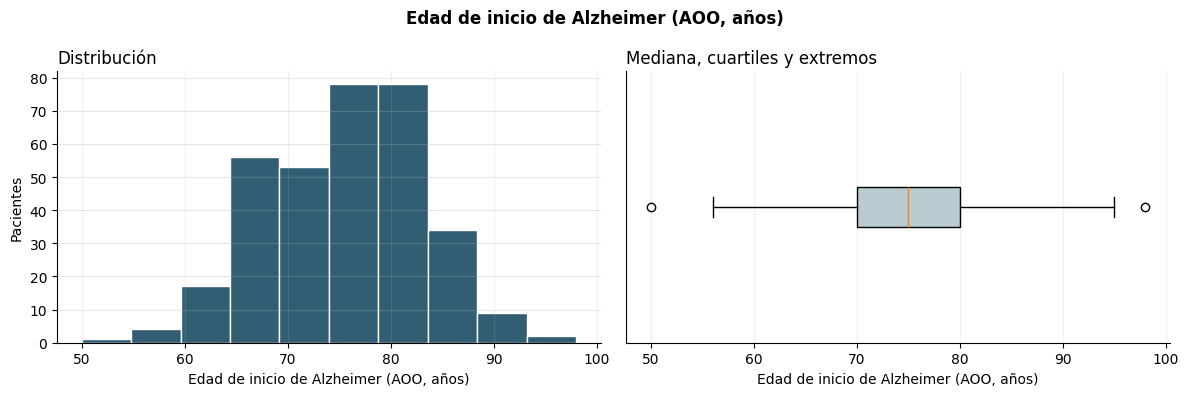

Casos marcados para revisión de coherencia: 15


,estado,n
0,Sin inconsistencia,317
1,AOO no disponible,59
2,Inconsistente solo en hxgen,7
3,Inconsistente en ambas fuentes,5
4,Inconsistente solo en neuro,3


In [44]:
n_total=len(base_full); n_aoo=base_full['aoo'].notna().sum()
display(pd.DataFrame([{'cohorte_total':n_total,'AOO_disponible':n_aoo,
                       'AOO_faltante':n_total-n_aoo,'disponibilidad_pct':round(100*n_aoo/n_total,1)}]))
display(resumen_numerico(base_full['aoo']))
display(tabla_frecuencias_numerica(base_full['aoo']))
grafico_numerico(base_full['aoo'],'Edad de inicio de Alzheimer (AOO, años)')
print('Casos marcados para revisión de coherencia:',int(base_full['estado_consistencia_aoo'].str.startswith('Inconsistente').sum()))
display(base_full['estado_consistencia_aoo'].value_counts(dropna=False).rename_axis('estado').reset_index(name='n'))


#### **Hallazgos principales**

### **21.3. Variables sociodemográficas**

La interpretación como covariable anterior al inicio requiere validar la temporalidad cuando corresponda. Se conservan los códigos originales cuando su significado no está documentado.



Variables integradas en la familia: 11


**Frecuencias categóricas**

,variable,categoría,n,% válido,% cohorte,faltantes
0,Genero,1.0,258,66.8,66.0,5
1,Genero,0.0,128,33.2,32.7,5
2,Idioma,2.0,386,100.0,98.7,5
3,Nivel educativo,5.0,180,46.8,46.0,6
4,Nivel educativo,12.0,90,23.4,23.0,6
5,Nivel educativo,16.0,33,8.6,8.4,6
6,Nivel educativo,3.0,1,0.3,0.3,6
7,Nivel educativo,0.0,68,17.7,17.4,6
8,Nivel educativo,7.0,1,0.3,0.3,6
9,Nivel educativo,99.0,9,2.3,2.3,6


**Resumen cuantitativo**

,variable,n_valido,n_faltante,porcentaje_faltante,media,mediana,DE,minimo,Q1,Q3,maximo,RIQ,CV
0,Edad,386.0,5.0,1.3,78.96,79.0,7.64,61.0,74.0,84.0,103.0,10.0,0.1


**Texto y alta cardinalidad**

,variable,n válido,faltantes,n únicos,modo
0,Mes y anio de nacimiento,385,6,372,-
1,Otro idoma,386,5,3,2.0


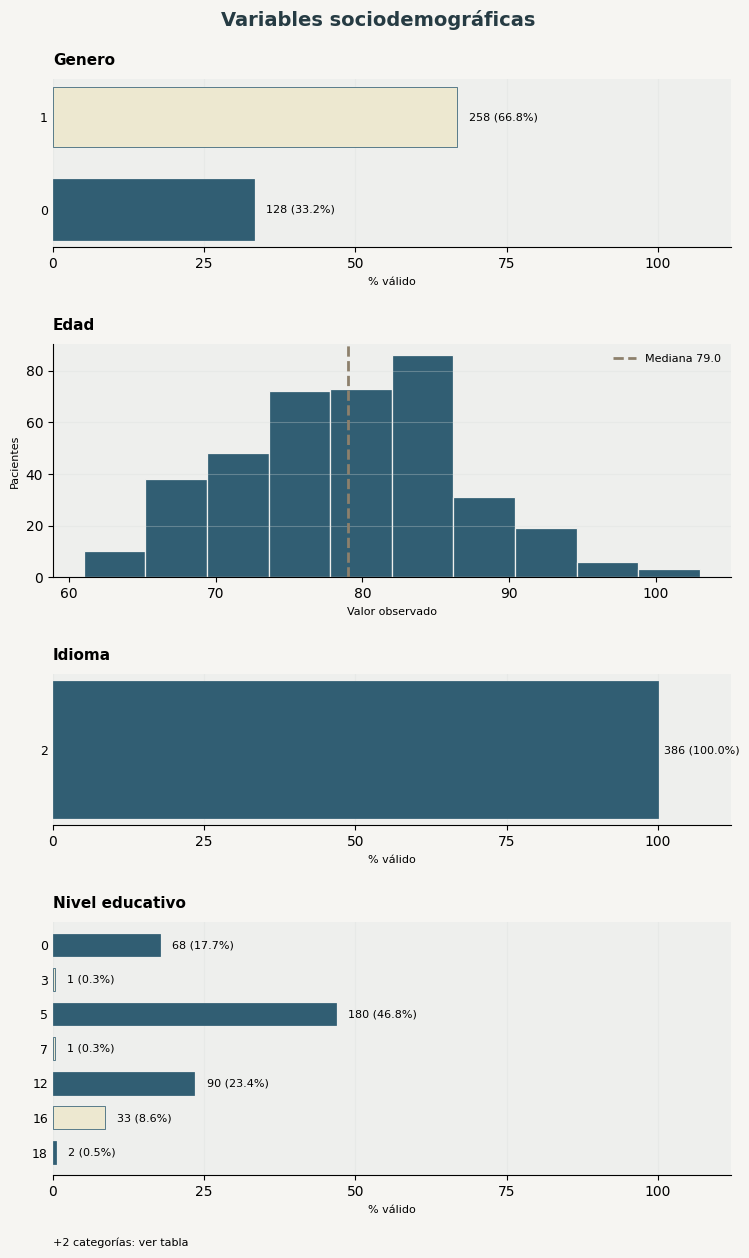

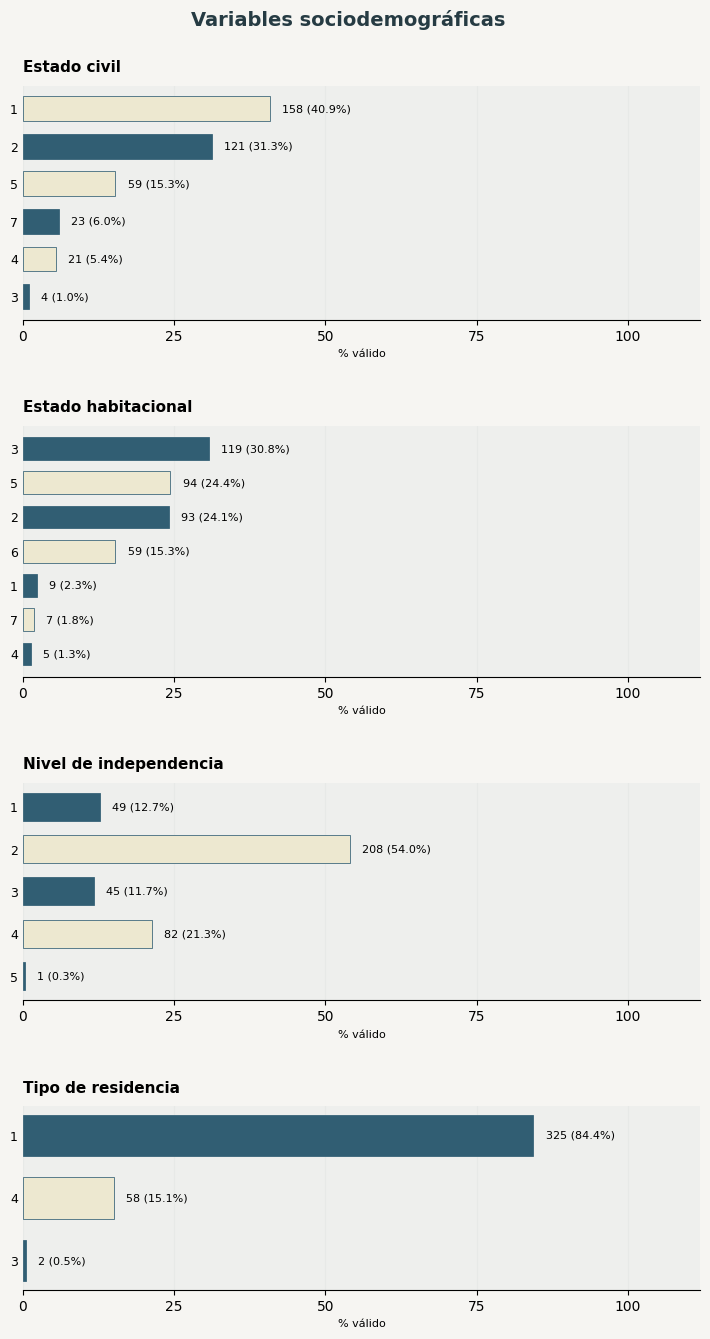

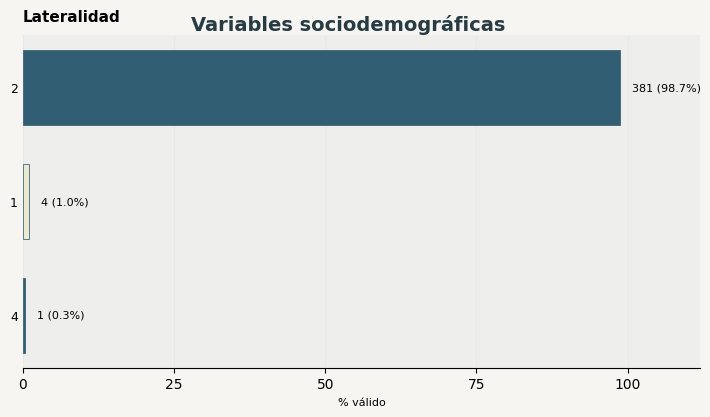

In [45]:
columnas = inventario.loc[(inventario.familia == 'sociodemograficas') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:',len(columnas))
analisis_familia(columnas, 'Variables sociodemográficas')


#### **Hallazgos principales**

### **21.4. Informante y red de apoyo**

La interpretación como covariable anterior al inicio requiere validar la temporalidad cuando corresponda. Se conservan los códigos originales cuando su significado no está documentado.



Variables integradas en la familia: 5


**Frecuencias categóricas**

,variable,categoría,n,% válido,% cohorte,faltantes
0,Relacion del informante,2.0,172,44.6,44.0,5
1,Relacion del informante,1.0,38,9.8,9.7,5
2,Relacion del informante,3.0,8,2.1,2.0,5
3,Relacion del informante,4.0,37,9.6,9.5,5
4,Relacion del informante,6.0,70,18.1,17.9,5
5,Relacion del informante,5.0,61,15.8,15.6,5
6,Vive el informante con el sujeto,1,259,67.3,66.2,6
7,Vive el informante con el sujeto,0,58,15.1,14.8,6
8,Vive el informante con el sujeto,-,67,17.4,17.1,6
9,Vive el informante con el sujeto,3,1,0.3,0.3,6


**Texto y alta cardinalidad**

,variable,n válido,faltantes,n únicos,modo
0,Tiempo anios de conocerce,382,9,56,-


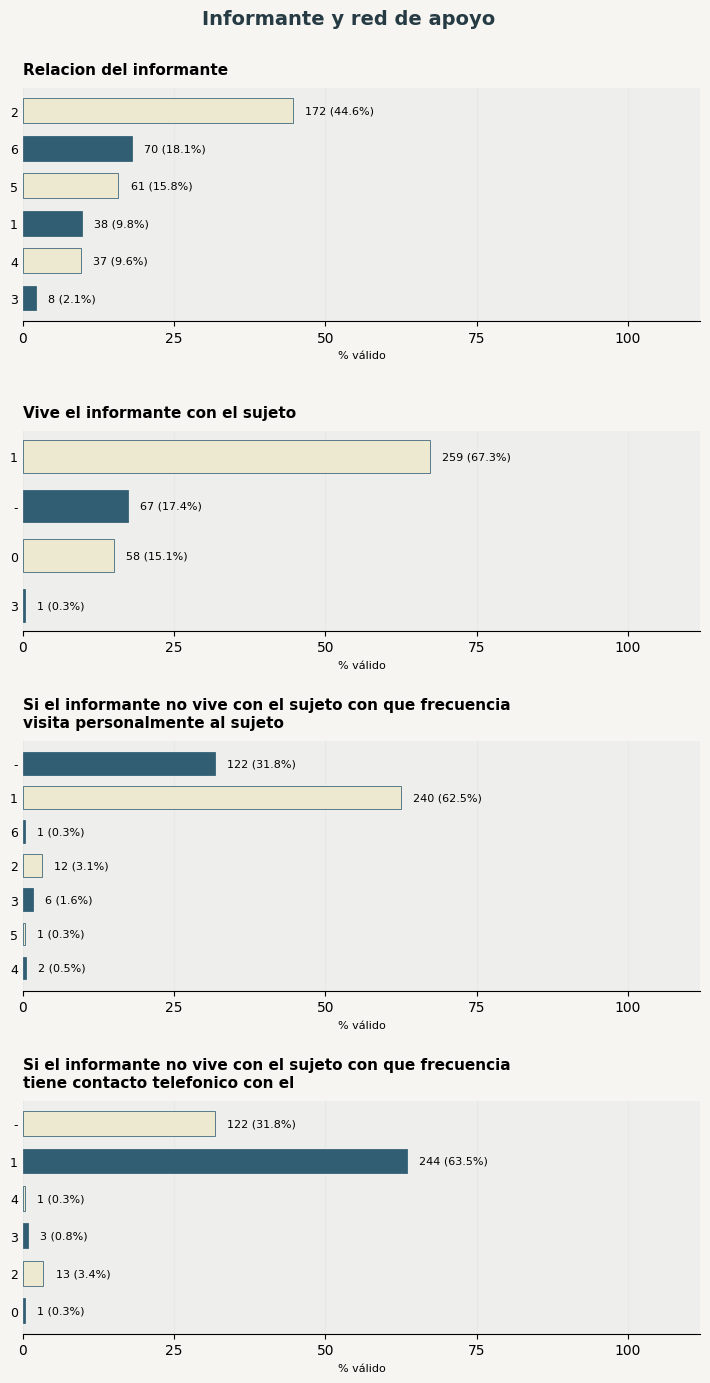

In [46]:
columnas = inventario.loc[(inventario.familia == 'informante_red_apoyo') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:',len(columnas))
analisis_familia(columnas, 'Informante y red de apoyo')


#### **Hallazgos principales**

### **21.5. Historia familiar**

La interpretación como covariable anterior al inicio requiere validar la temporalidad cuando corresponda. Se conservan los códigos originales cuando su significado no está documentado.



Variables integradas en la familia: 2


**Frecuencias categóricas**

,variable,categoría,n,% válido,% cohorte,faltantes
0,Hay miembros afectados de la familia padres biologicos hermanos consanguineos completos comparten ambos padres o hij...,0,231,60.2,59.1,7
1,Hay miembros afectados de la familia padres biologicos hermanos consanguineos completos comparten ambos padres o hij...,1,134,34.9,34.3,7
2,Hay miembros afectados de la familia padres biologicos hermanos consanguineos completos comparten ambos padres o hij...,-,4,1.0,1.0,7
3,Hay miembros afectados de la familia padres biologicos hermanos consanguineos completos comparten ambos padres o hij...,9,14,3.6,3.6,7
4,Hay miembros afectados de la familia padres biologicos hermanos consanguineos completos comparten ambos padres o hij...,NO,1,0.3,0.3,7
5,Familiar afectado,0,59,15.3,15.1,6
6,Familiar afectado,1 Y 2,1,0.3,0.3,6
7,Familiar afectado,2,59,15.3,15.1,6
8,Familiar afectado,3,5,1.3,1.3,6
9,Familiar afectado,2022-02-01 00:00:00,2,0.5,0.5,6


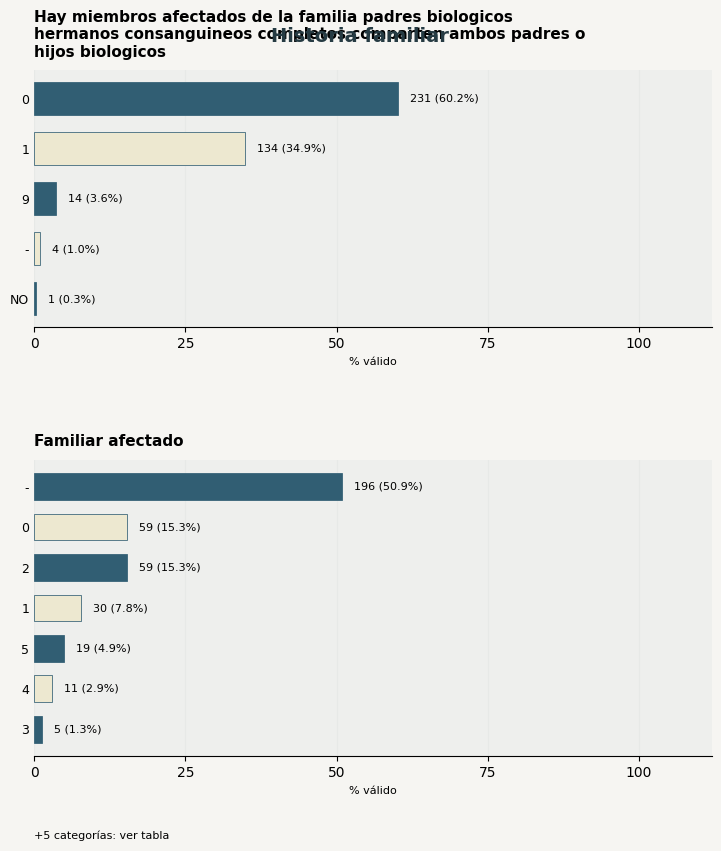

In [47]:
columnas = inventario.loc[(inventario.familia == 'historia_familiar') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:',len(columnas))
analisis_familia(columnas, 'Historia familiar')


#### **Hallazgos principales**

### **21.6. Antropometría**

La interpretación como covariable anterior al inicio requiere validar la temporalidad cuando corresponda. Se conservan los códigos originales cuando su significado no está documentado.



Variables integradas en la familia: 2


**Resumen cuantitativo**

,variable,n_valido,n_faltante,porcentaje_faltante,media,mediana,DE,minimo,Q1,Q3,maximo,RIQ,CV
0,Peso,289.0,102.0,26.1,60.79,60.0,11.73,29.0,53.00,68.0,105.0,15.00,0.19
1,Talla,338.0,53.0,13.6,125.93,158.0,67.13,1.4,149.25,165.0,189.0,15.75,0.53


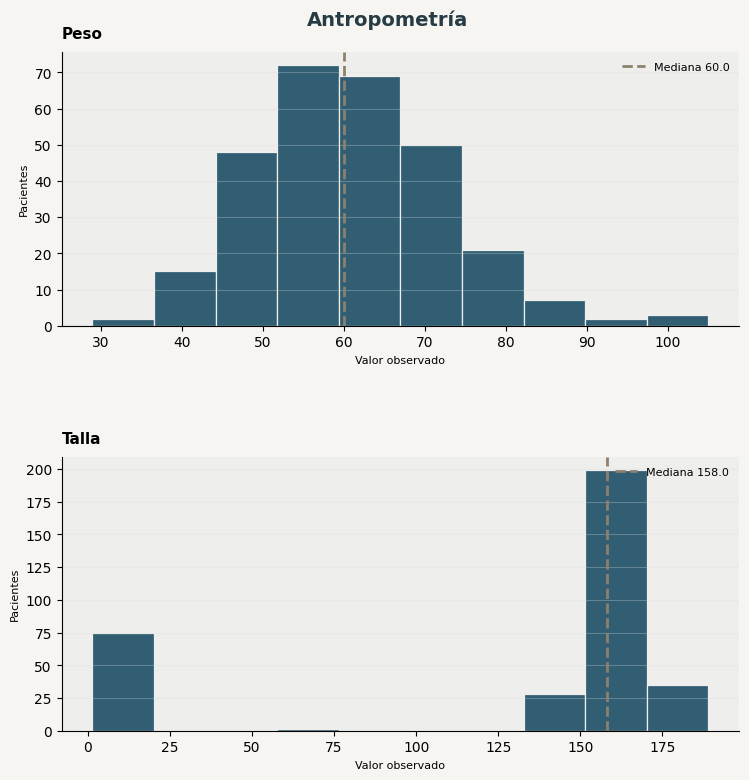

In [48]:
columnas = inventario.loc[(inventario.familia == 'antropometria') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:',len(columnas))
analisis_familia(columnas, 'Antropometría')


#### **Hallazgos principales**

### **21.7. Medicamentos**

La interpretación como covariable anterior al inicio requiere validar la temporalidad cuando corresponda. Se conservan los códigos originales cuando su significado no está documentado.



In [49]:
columnas = inventario.loc[(inventario.familia == 'medicamentos') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:',len(columnas))
analisis_familia(columnas, 'Medicamentos')


Variables integradas en la familia: 9


**Texto y alta cardinalidad**

,variable,n válido,faltantes,n únicos,modo
0,Medicamento del sujeto 1,384,7,86,LOSARTAN
1,Medicamento del sujeto 2,383,8,103,-
2,Medicamento del sujeto 3,383,8,71,-
3,Medicamento del sujeto 4,384,7,64,-
4,Medicamento del sujeto 5,384,7,46,-
5,Medicamento del sujeto 6,384,7,32,-
6,Medicamento del sujeto 7,384,7,23,-
7,Medicamento del sujeto 8,384,7,15,-
8,Medicamento del sujeto 9,383,8,15,-


#### **Hallazgos principales**

### **21.8. Tabaquismo y hábitos**

La interpretación como covariable anterior al inicio requiere validar la temporalidad cuando corresponda. Se conservan los códigos originales cuando su significado no está documentado.

Para los años de tabaquismo, el código 99 se presenta como faltante en la vista univariada. Se mantiene sin cambios la columna original.



Variables integradas en la familia: 3


**Frecuencias categóricas**

,variable,categoría,n,% válido,% cohorte,faltantes
0,El sujeto ha fumado en los pasados 30 dias,0,372,96.4,95.1,5
1,El sujeto ha fumado en los pasados 30 dias,1,4,1.0,1.0,5
2,El sujeto ha fumado en los pasados 30 dias,-,1,0.3,0.3,5
3,El sujeto ha fumado en los pasados 30 dias,9,9,2.3,2.3,5
4,El sujeto ha fumado mas de 100 cigarros cigarrillos en su vida,0,274,71.0,70.1,5
5,El sujeto ha fumado mas de 100 cigarros cigarrillos en su vida,1,97,25.1,24.8,5
6,El sujeto ha fumado mas de 100 cigarros cigarrillos en su vida,-,2,0.5,0.5,5
7,El sujeto ha fumado mas de 100 cigarros cigarrillos en su vida,9,13,3.4,3.3,5


**Resumen cuantitativo**

,variable,n_valido,n_faltante,porcentaje_faltante,media,mediana,DE,minimo,Q1,Q3,maximo,RIQ,CV
0,Numero total de anios que ha fumado el sujeto 99 desconocido,340.0,51.0,13.0,3.95,0.0,10.2,0.0,0.0,0.0,70.0,0.0,2.58


**Tabaquismo:** 13 registros con código 99 se cuentan como desconocidos en este resumen; la columna original se conserva.

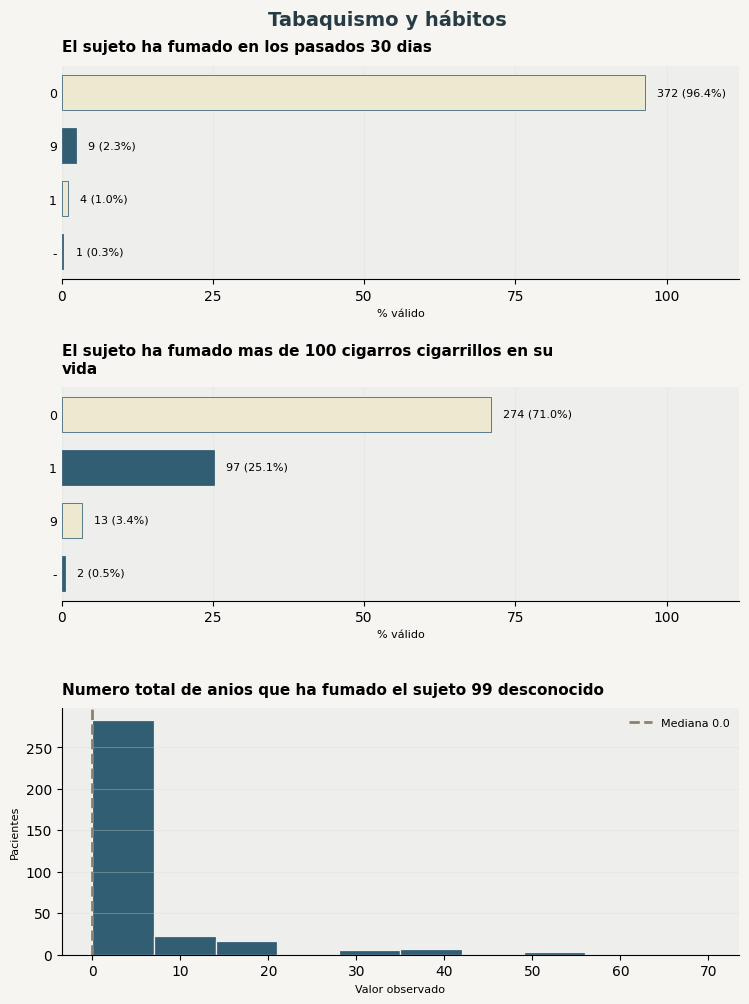

In [50]:
columnas = inventario.loc[(inventario.familia == 'tabaquismo') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:',len(columnas))
analisis_familia(columnas, 'Tabaquismo y hábitos')


#### **Hallazgos principales**

### **21.9. Antecedentes cardiovasculares y cerebrovasculares**

La interpretación como covariable anterior al inicio requiere validar la temporalidad cuando corresponda. Se conservan los códigos originales cuando su significado no está documentado.



Variables integradas en la familia: 7


**Frecuencias categóricas**

,variable,categoría,n,% válido,% cohorte,faltantes
0,Ataque cardiaco o paro cardiaco,0,379,98.2,96.9,5
1,Ataque cardiaco o paro cardiaco,-,1,0.3,0.3,5
2,Ataque cardiaco o paro cardiaco,1,6,1.6,1.5,5
3,Fibrilacion auricular,0.0,379,98.4,96.9,6
4,Fibrilacion auricular,1.0,6,1.6,1.5,6
5,Angioplastia endarterectomia stent,0.0,386,100.0,98.7,5
6,Bypass cardiaco coronario,0.0,386,100.0,98.7,5
7,Marcapasos y o desfibrilador,0.0,381,98.7,97.4,5
8,Marcapasos y o desfibrilador,1.0,5,1.3,1.3,5
9,Insuficiencia cardiaca congestiva,0.0,382,99.2,97.7,6


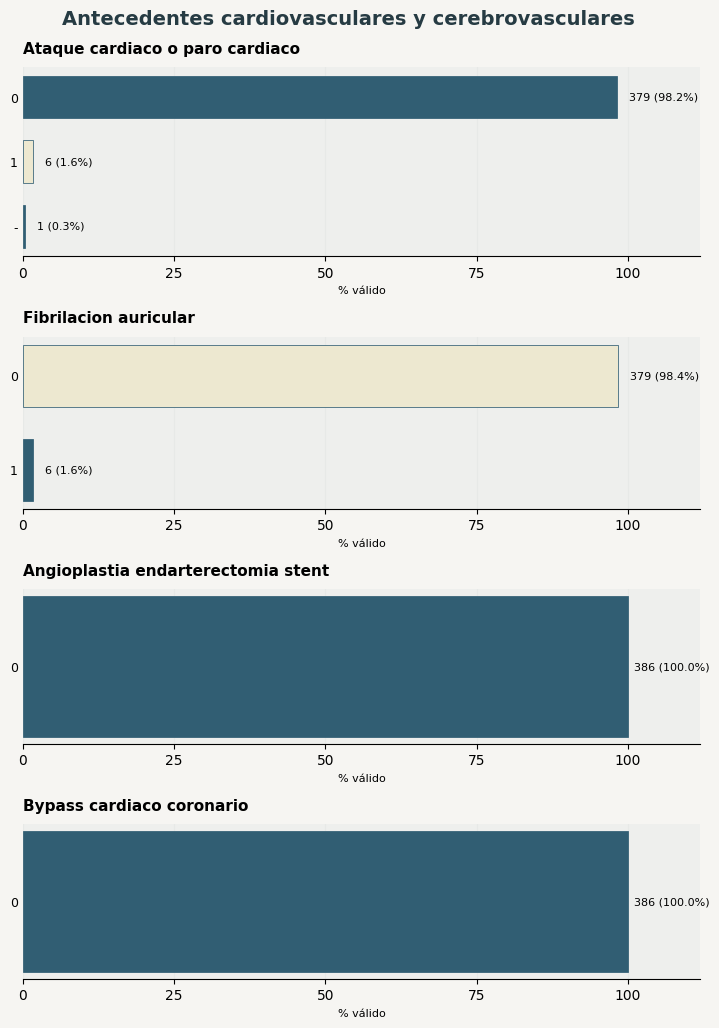

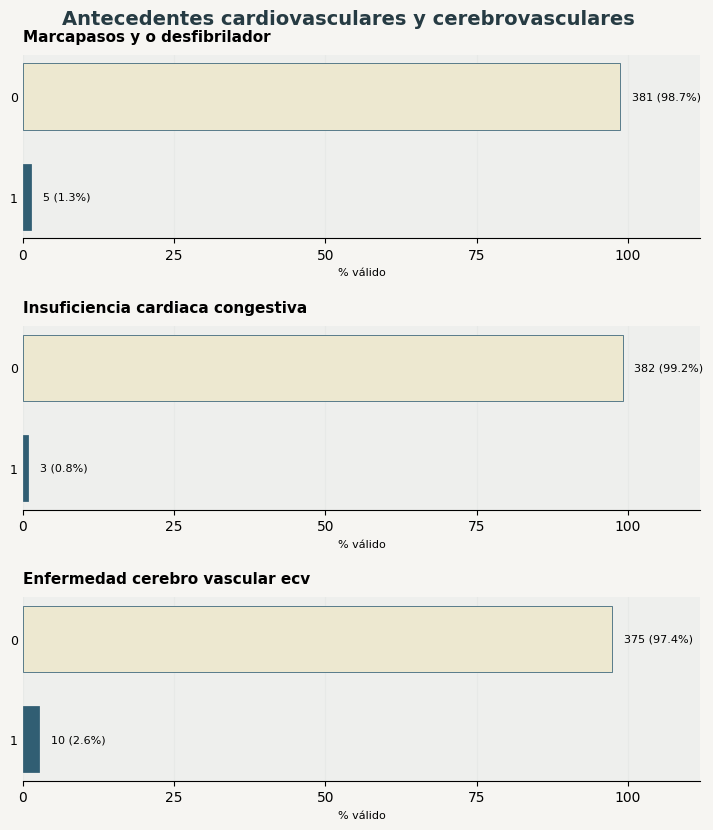

In [51]:
columnas = inventario.loc[(inventario.familia == 'cardiovasculares_cerebrovasculares') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:',len(columnas))
analisis_familia(columnas, 'Antecedentes cardiovasculares y cerebrovasculares')


#### **Hallazgos principales**

### **21.10. Antecedentes neurológicos**

La interpretación como covariable anterior al inicio requiere validar la temporalidad cuando corresponda. Se conservan los códigos originales cuando su significado no está documentado.



Variables integradas en la familia: 3


**Frecuencias categóricas**

,variable,categoría,n,% válido,% cohorte,faltantes
0,Parkinson,0.0,383,99.5,98.0,6
1,Parkinson,1.0,2,0.5,0.5,6
2,Convulsiones,0.0,382,99.0,97.7,5
3,Convulsiones,1.0,4,1.0,1.0,5
4,Traumatismo de craneo encefalico tce,0.0,386,100.0,98.7,5


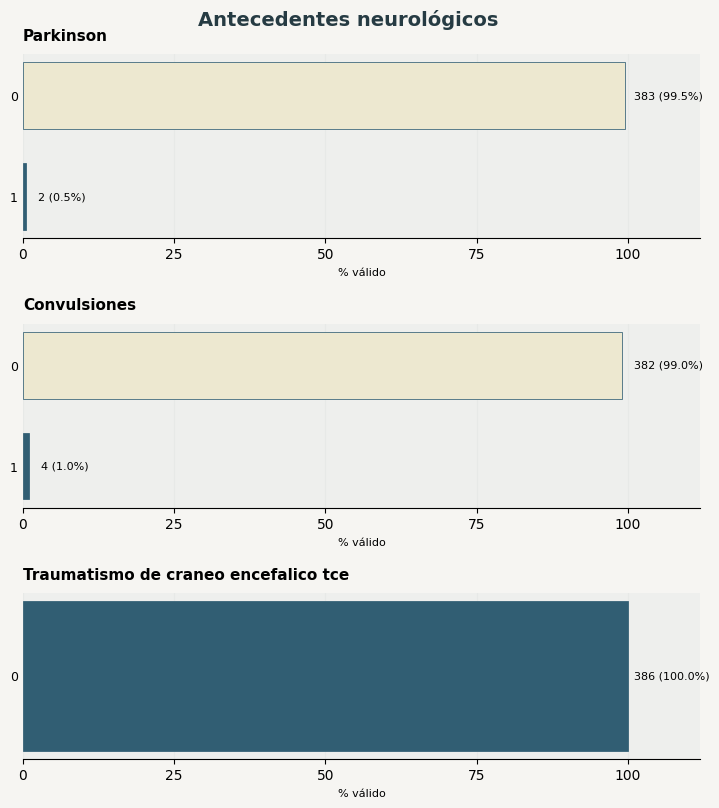

In [52]:
columnas = inventario.loc[(inventario.familia == 'neurologicos') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:',len(columnas))
analisis_familia(columnas, 'Antecedentes neurológicos')


#### **Hallazgos principales**

### **21.11. Comorbilidades y condiciones médicas**

La interpretación como covariable anterior al inicio requiere validar la temporalidad cuando corresponda. Se conservan los códigos originales cuando su significado no está documentado.



Variables integradas en la familia: 13


**Frecuencias categóricas**

,variable,categoría,n,% válido,% cohorte,faltantes
0,Diabetes,0.0,324,83.9,82.9,5
1,Diabetes,1.0,32,8.3,8.2,5
2,Diabetes,9.0,2,0.5,0.5,5
3,Diabetes,2.0,27,7.0,6.9,5
4,Diabetes,3.0,1,0.3,0.3,5
5,Cancer,0.0,378,98.2,96.7,6
6,Cancer,1.0,6,1.6,1.5,6
7,Cancer,9.0,1,0.3,0.3,6
8,Hipercholesterolemia,0.0,381,99.2,97.4,7
9,Hipercholesterolemia,1.0,3,0.8,0.8,7


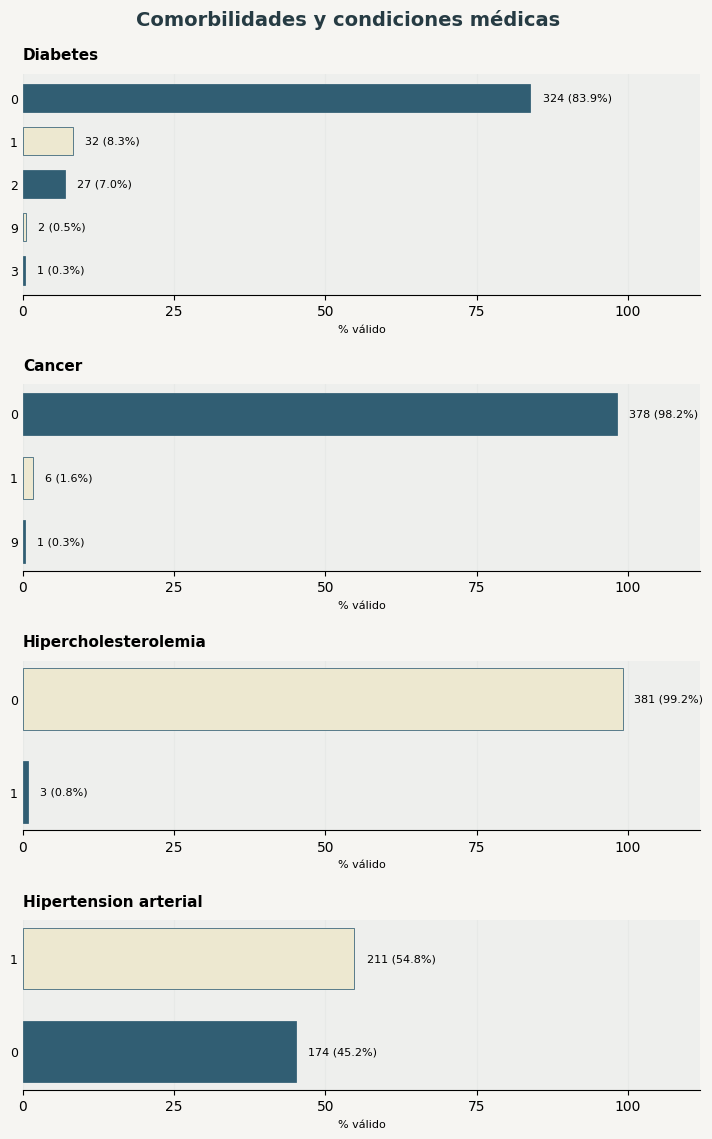

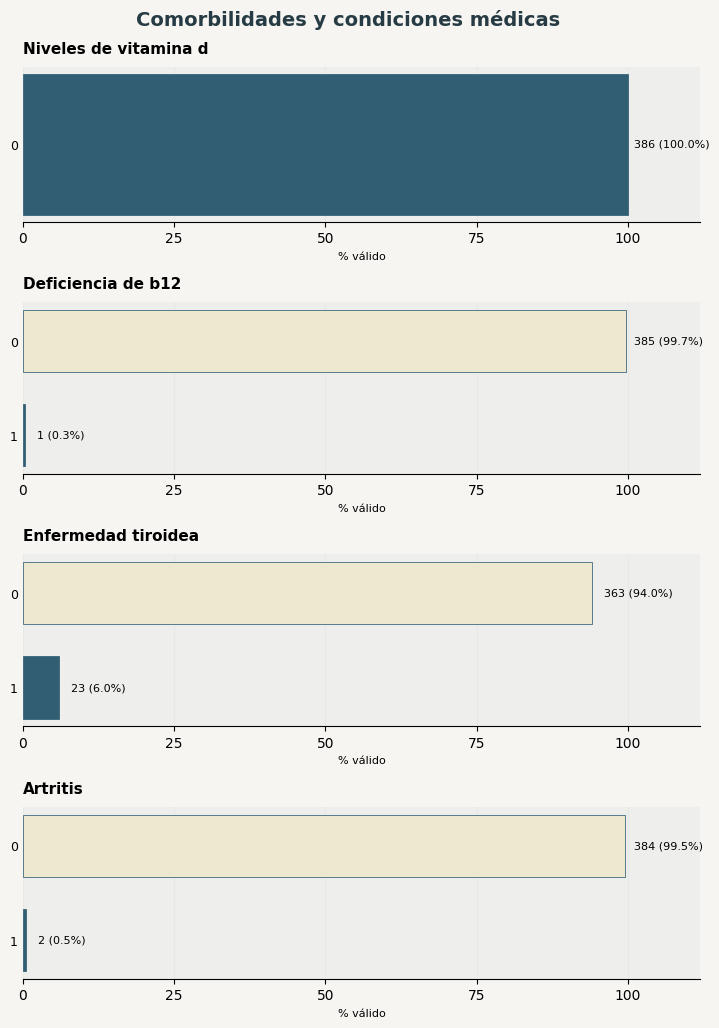

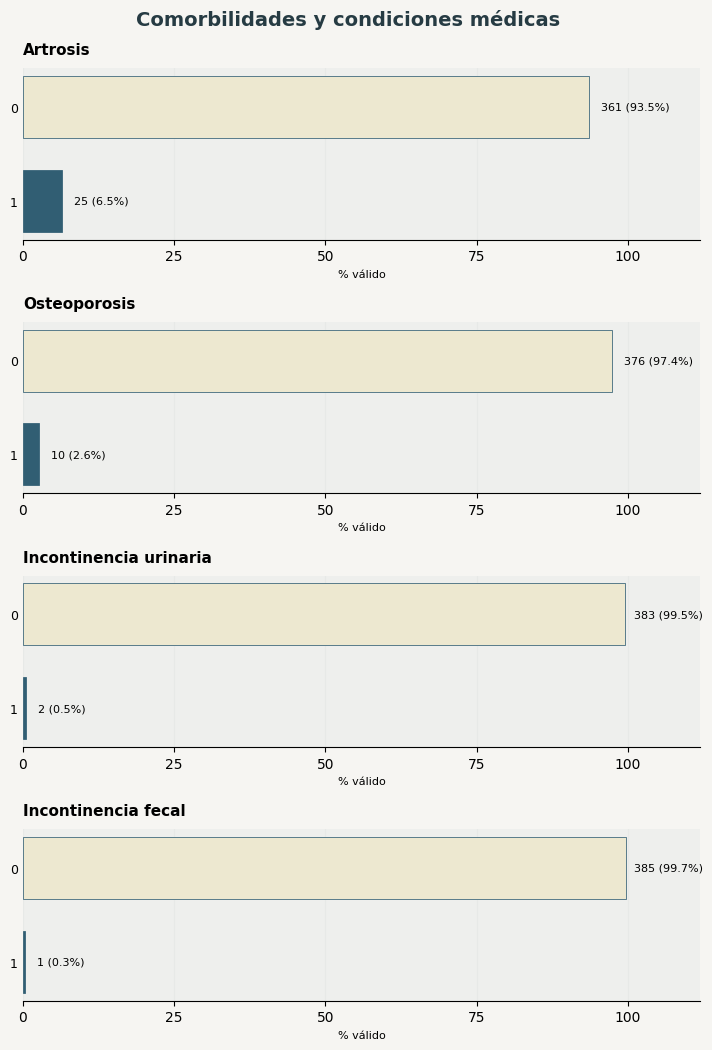

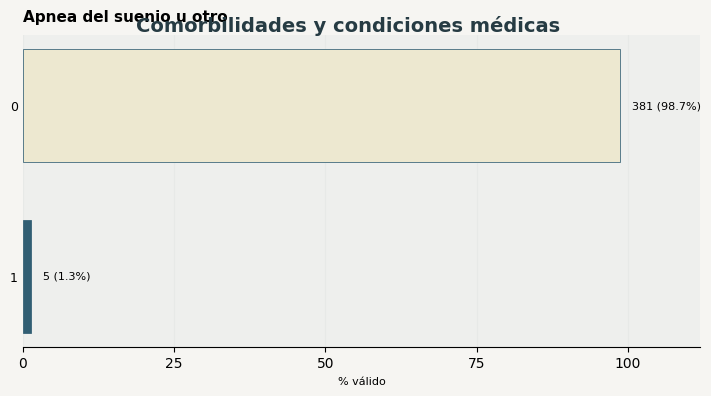

In [53]:
columnas = inventario.loc[(inventario.familia == 'metabolicos_otros') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:',len(columnas))
analisis_familia(columnas, 'Comorbilidades y condiciones médicas')


#### **Hallazgos principales**

### **21.12. Antecedentes psiquiátricos**

La interpretación como covariable anterior al inicio requiere validar la temporalidad cuando corresponda. Se conservan los códigos originales cuando su significado no está documentado.



Variables integradas en la familia: 7


**Frecuencias categóricas**

,variable,categoría,n,% válido,% cohorte,faltantes
0,Trastorno de estres postraumatico tept,0.0,385,100.0,98.5,6
1,Trastorno bipolar,0.0,386,100.0,98.7,5
2,Esquizofrenia,0.0,382,99.2,97.7,6
3,Esquizofrenia,1.0,3,0.8,0.8,6
4,Depresion,0.0,377,97.9,96.4,6
5,Depresion,1.0,8,2.1,2.0,6
6,Ansiedad,0.0,380,98.4,97.2,5
7,Ansiedad,1.0,6,1.6,1.5,5
8,Trastorno obsesivo compulsivo toc,0.0,386,100.0,98.7,5
9,Trastornos neuropsiquiatricos del desarrollo por ejemplo trastorno del espectro autista tea deficit de atencion con ...,0.0,386,100.0,98.7,5


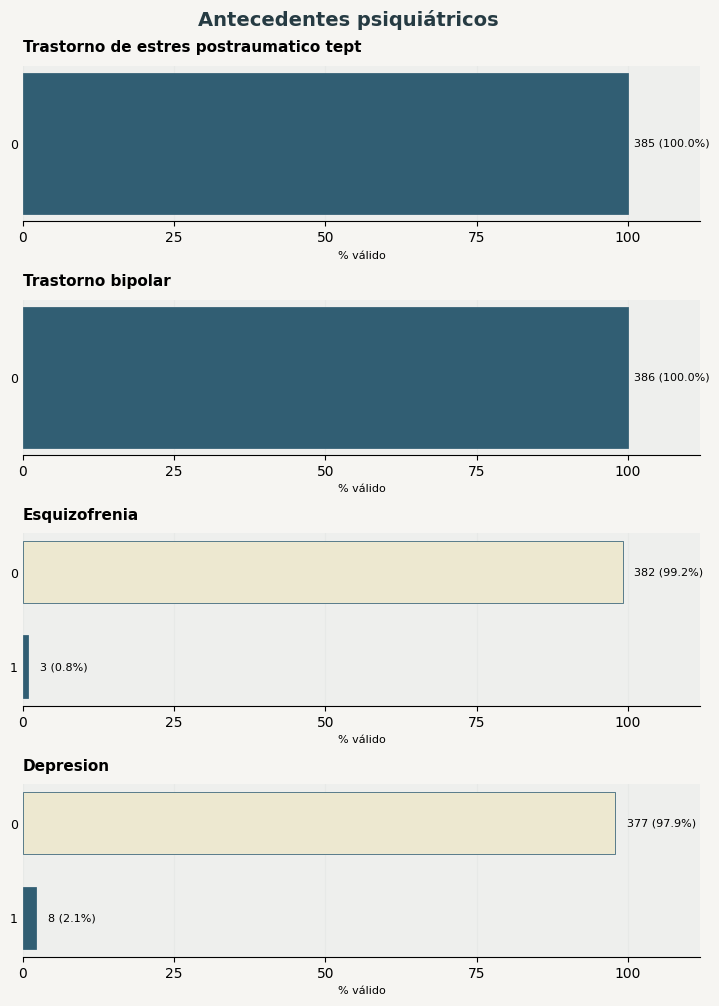

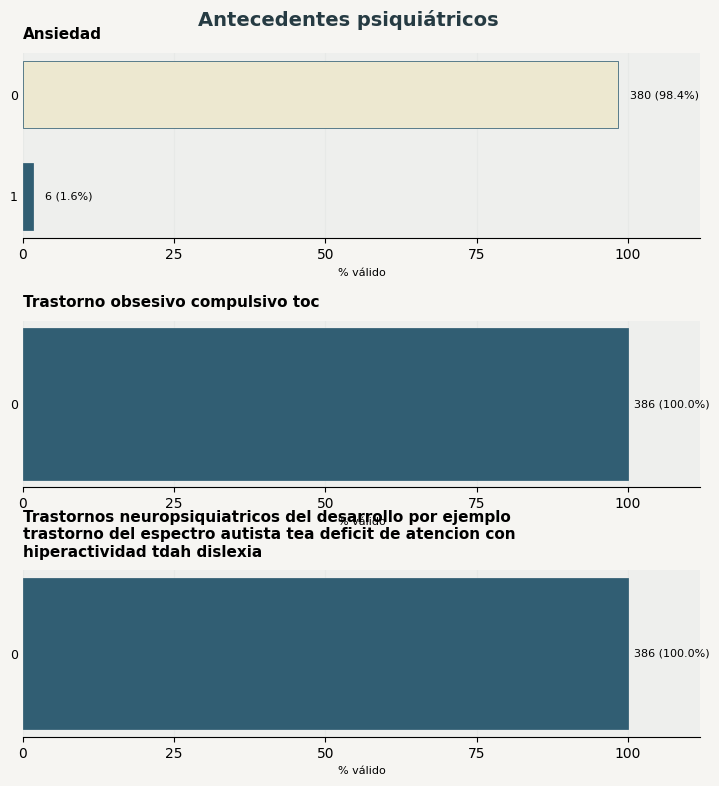

In [54]:
columnas = inventario.loc[(inventario.familia == 'psiquiatricos') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:',len(columnas))
analisis_familia(columnas, 'Antecedentes psiquiátricos')


#### **Hallazgos principales**

### **21.13. Variables clínicas HXGEN**

La interpretación como covariable anterior al inicio requiere validar la temporalidad cuando corresponda. Se conservan los códigos originales cuando su significado no está documentado.



Variables integradas en la familia: 23


**Frecuencias categóricas**

,variable,categoría,n,% válido,% cohorte,faltantes
0,Actualmente se encuentra en algun tratamiento farmacologico,SI,124,31.8,31.7,1
1,Actualmente se encuentra en algun tratamiento farmacologico,NO,15,3.8,3.8,1
2,Actualmente se encuentra en algun tratamiento farmacologico,Si,44,11.3,11.3,1
3,Actualmente se encuentra en algun tratamiento farmacologico,sI,2,0.5,0.5,1
4,Actualmente se encuentra en algun tratamiento farmacologico,No,52,13.3,13.3,1
5,Actualmente se encuentra en algun tratamiento farmacologico,si,1,0.3,0.3,1
6,Actualmente se encuentra en algun tratamiento farmacologico,Sí,151,38.7,38.6,1
7,Actualmente se encuentra en algun tratamiento farmacologico,S{i,1,0.3,0.3,1
8,Usted fuma,NO,114,29.2,29.2,0
9,Usted fuma,SI,7,1.8,1.8,0


**Resumen cuantitativo**

,variable,n_valido,n_faltante,porcentaje_faltante,media,mediana,DE,minimo,Q1,Q3,maximo,RIQ,CV
0,Edad,390.0,1.0,0.3,78.93,79.0,7.59,61.0,73.25,84.0,103.0,10.75,0.10
1,Peso en kilogramo,285.0,106.0,27.1,60.11,59.0,11.64,29.0,52.00,68.0,105.0,16.00,0.19
2,Altura en centimetro,339.0,52.0,13.3,160.93,160.0,11.38,58.0,155.00,168.0,190.0,13.00,0.07


**Texto y alta cardinalidad**

,variable,n válido,faltantes,n únicos,modo
0,Ciudad o municipio de residencia,391,0,83,BARRANQUILLA
1,Enfermedad actual,391,0,6,Alzheimer
2,Que sintomas presenta,391,0,88,"Olvidaba cosas (nombre de personas, lugares, etc.);Falla en orientación espacial; falla en orientación temporal"
3,El paciente necesita apoyo para realizar las siguientes tareas,380,11,39,"Salir a la calle, Hora de tomar medicamentos"
4,Indique que estudios previos le han realizado,384,7,27,EEG
5,Si le han realizado estudios previos encontraron hallazgos cuales,374,17,34,Hallazgos compatibles con Alzheimer
6,Antecedentes,299,92,106,Hipertensión
7,Si la respuesta anterior fue si que medicamentos esta consumiendo,323,68,284,Losartan
8,Si respuesta anterior fue afirmativa hace cuantos anios fuma,15,376,15,7 años
9,Si la respuesta anterior fue si que cirugia le han realizado,75,316,65,Artroplastia total de rodilla


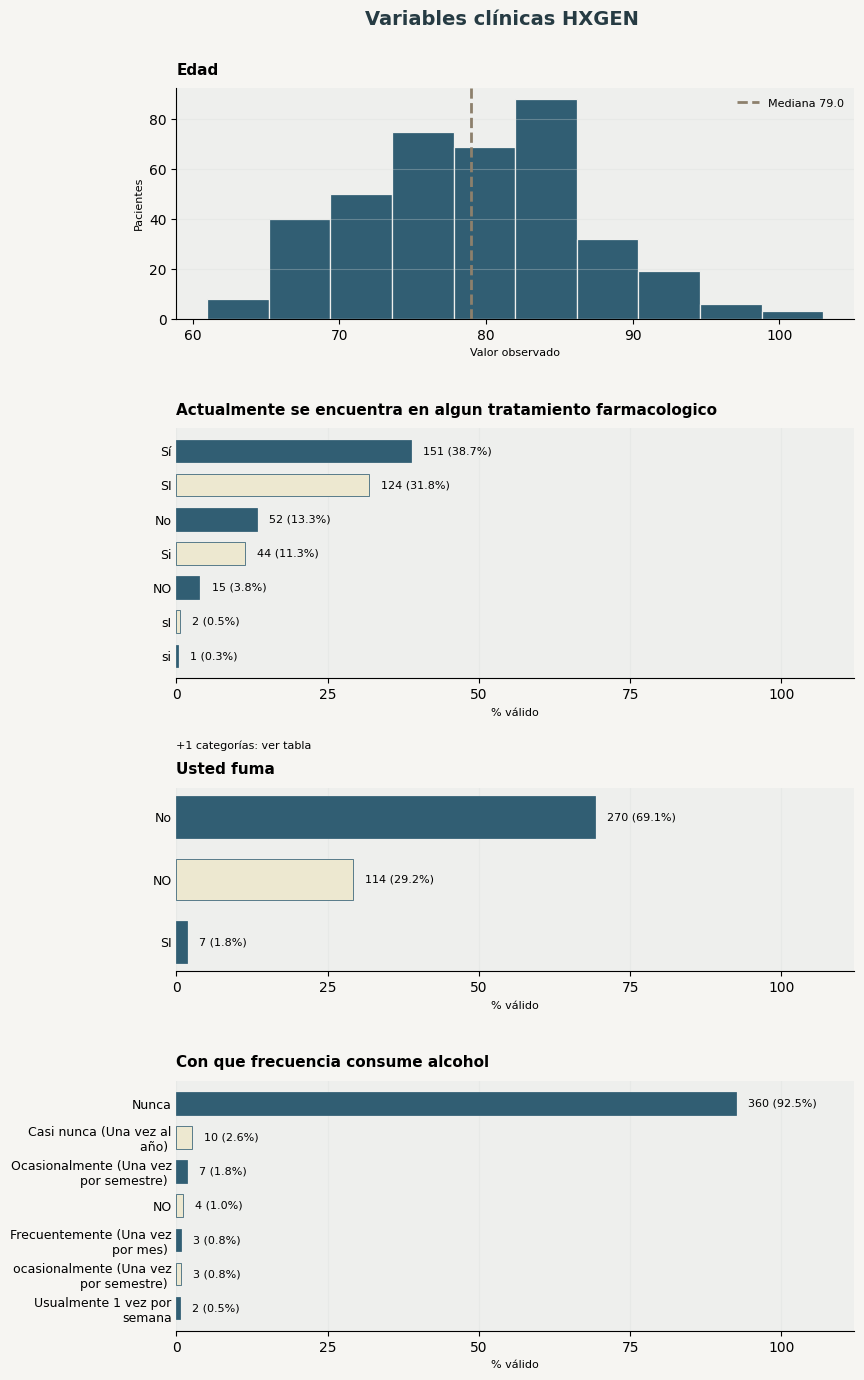

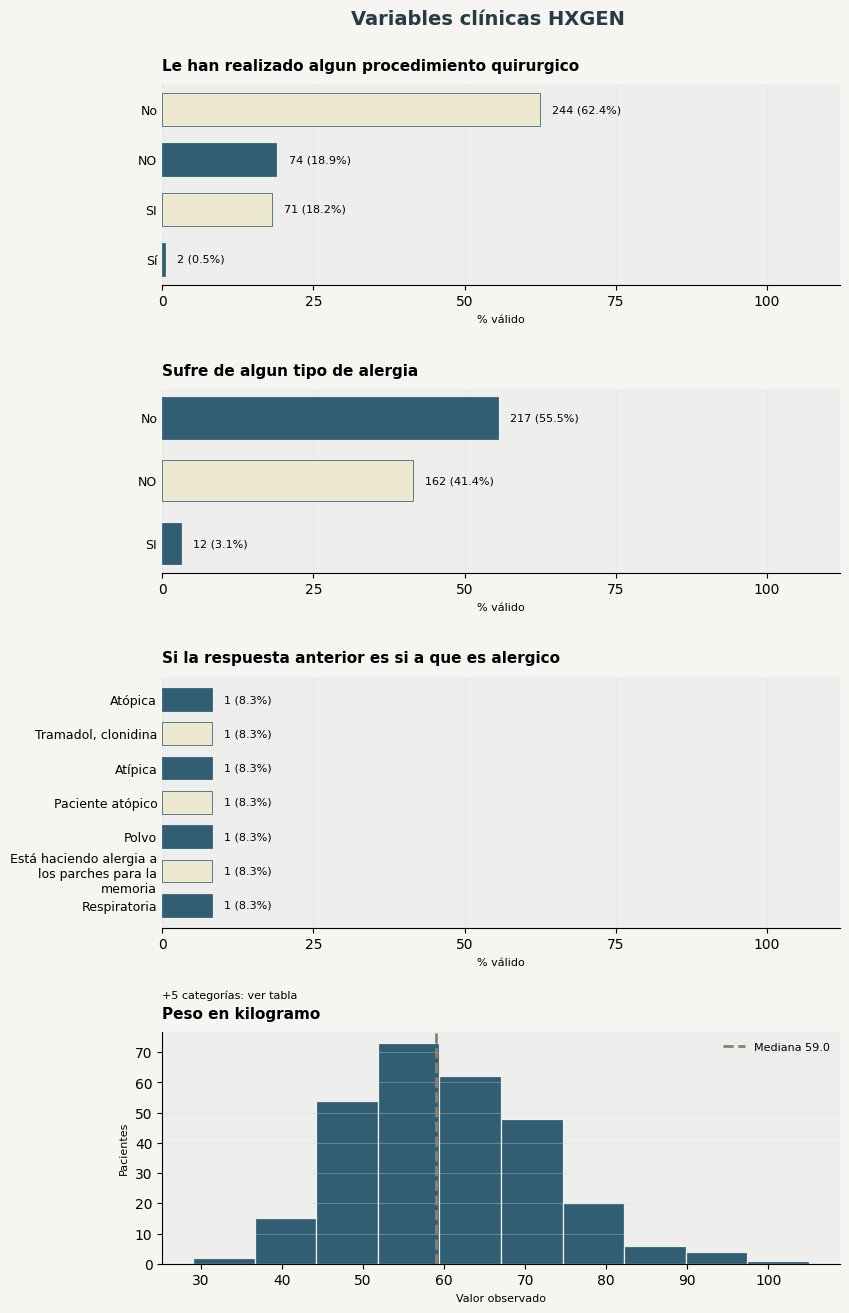

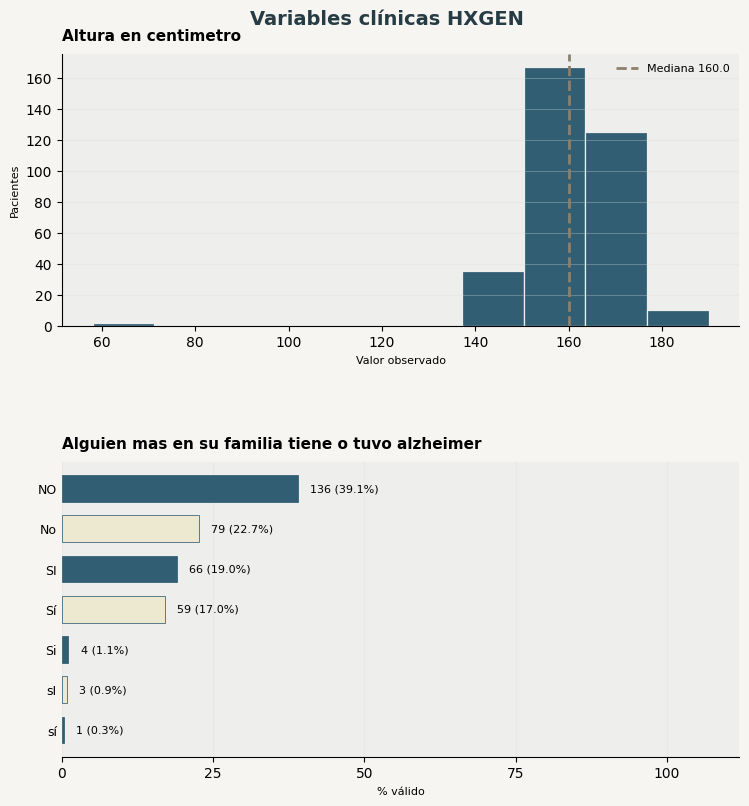

In [55]:
columnas = inventario.loc[(inventario.familia == 'historia_clinica_genetica') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:',len(columnas))
analisis_familia(columnas, 'Variables clínicas HXGEN')


#### **Hallazgos principales**

### **21.14. Variables neuropsicológicas por dominio**

Primero se revisa calidad, rango, variabilidad y redundancia ya explorada en la sección 20. MMSE, MoCA y FAST reciben un panel conjunto y tablas descriptivas. Las demás pruebas se resumen por dominio, sin generar un gráfico por prueba. Sus valores pueden reflejar mediciones posteriores al inicio; `riesgo_leakage_aoo` se conserva como referencia para etapas posteriores, sin excluirlas del EDA.



In [56]:
cols_nps = list(dict.fromkeys([c for c in neuro_norm if c in base_full.columns] +
                            (['moca__moca'] if 'moca__moca' in base_full else [])))
filas=[]
for col in cols_nps:
    s=base_full[col]; x=pd.to_numeric(s,errors='coerce').dropna()
    meta=inventario.loc[inventario.columna.eq(col)]
    filas.append({'dominio':meta.familia.iloc[0] if len(meta) else 'sin_asignacion_validada',
        'variable':etiqueta_bonita(col),'tipo':meta.tipo_analitico.iloc[0] if len(meta) else 'revisar',
        'n_valido':s.notna().sum(),'faltante_pct':round(100*s.isna().mean(),1),
        'n_unicos':s.nunique(dropna=True),'media':x.mean() if len(x) else np.nan,
        'mediana':x.median() if len(x) else np.nan,'minimo':x.min() if len(x) else np.nan,
        'maximo':x.max() if len(x) else np.nan,'DE':x.std(),
        'constante':s.nunique(dropna=True)<=1,
        'riesgo_leakage_aoo':meta.riesgo_leakage_aoo.iloc[0] if len(meta) else 'Revisar'})
calidad_nps_21=pd.DataFrame(filas)
for dominio, tabla in calidad_nps_21.groupby('dominio',sort=False):
    display(Markdown('**'+dominio.replace('_',' ').capitalize()+'**'))
    display(tabla.drop(columns='dominio').round(2).reset_index(drop=True))
display(Markdown(f'**Control de calidad:** {calidad_nps_21.constante.sum()} variables sin variación; '+
    f'{(calidad_nps_21.faltante_pct>=30).sum()} con al menos 30% de faltantes. '+
    'Las correlaciones de redundancia ya figuran en 20.3 y no se usan aquí para selección por AOO.'))


**Metadatos nps**

,variable,tipo,n_valido,faltante_pct,n_unicos,media,mediana,minimo,maximo,DE,constante,riesgo_leakage_aoo
0,Hay valoracion nps anterior,categórica binaria,380,2.8,2,0.01,0.0,0.0,1.0,0.10,False,Potencial
1,Si tiene anteriormente valoracion nps en que fecha se aplico,texto libre / alta cardinalidad,367,6.1,5,130.23,0.0,0.0,2021.0,504.08,False,Potencial


**Cognicion global**

,variable,tipo,n_valido,faltante_pct,n_unicos,media,mediana,minimo,maximo,DE,constante,riesgo_leakage_aoo
0,MMSE,cuantitativa discreta,383,2.0,31,16.33,19.0,0.0,30.0,9.53,False,Alto
1,Esc deterioroglobal,ordinal,385,1.5,6,3.84,4.0,2.0,7.0,0.55,False,Alto
2,MoCA,cuantitativa discreta,387,1.0,28,8.91,8.0,0.0,28.0,7.01,False,Alto


**Memoria**

...

**Memoria semantica conocimiento**

,variable,tipo,n_valido,faltante_pct,n_unicos,media,mediana,minimo,maximo,DE,constante,riesgo_leakage_aoo
0,Tsmydoral,cuantitativa discreta,361,7.7,34,3.69,0.0,0.0,42.0,7.41,False,Potencial
1,Tsmyd escr,cuantitativa discreta,361,7.7,28,2.93,0.0,0.0,35.0,5.78,False,Potencial
2,Benton,cuantitativa discreta,363,7.2,8,0.88,0.0,0.0,7.0,1.33,False,Potencial


**Funcional afectivo quejas**

,variable,tipo,n_valido,faltante_pct,n_unicos,media,mediana,minimo,maximo,DE,constante,riesgo_leakage_aoo
0,Quejas subjetivas,texto libre / alta cardinalidad,381,2.6,7,2.12,2.0,0.0,31.0,2.15,False,Alto
1,Yesavage,cuantitativa discreta,370,5.4,15,6.35,4.0,0.0,16.0,5.89,False,Alto
2,Barthel,cuantitativa discreta,386,1.3,12,37.40,50.0,0.0,50.0,18.13,False,Alto
3,Lawton y brody,cuantitativa discreta,386,1.3,14,2.71,2.0,0.0,30.0,4.55,False,Alto
4,Ikatz,cuantitativa discreta,386,1.3,7,1.62,0.0,0.0,6.0,2.17,False,Alto
5,FAST,ordinal,386,1.3,5,3.51,3.0,2.0,16.0,0.84,False,Alto


**Control de calidad:** 0 variables sin variación; 0 con al menos 30% de faltantes. Las correlaciones de redundancia ya figuran en 20.3 y no se usan aquí para selección por AOO.

**Frecuencias categóricas**

,variable,categoría,n,% válido,% cohorte,faltantes
0,FAST,4.0,187,48.4,47.8,5
1,FAST,3.0,192,49.7,49.1,5
2,FAST,16.0,1,0.3,0.3,5
3,FAST,2.0,5,1.3,1.3,5
4,FAST,6.0,1,0.3,0.3,5


**Resumen cuantitativo**

,variable,n_valido,n_faltante,porcentaje_faltante,media,mediana,DE,minimo,Q1,Q3,maximo,RIQ,CV
0,MMSE,383.0,8.0,2.0,16.33,19.0,9.53,0.0,10.0,24.0,30.0,14.0,0.58
1,MoCA,387.0,4.0,1.0,8.91,8.0,7.01,0.0,3.0,15.0,28.0,12.0,0.79


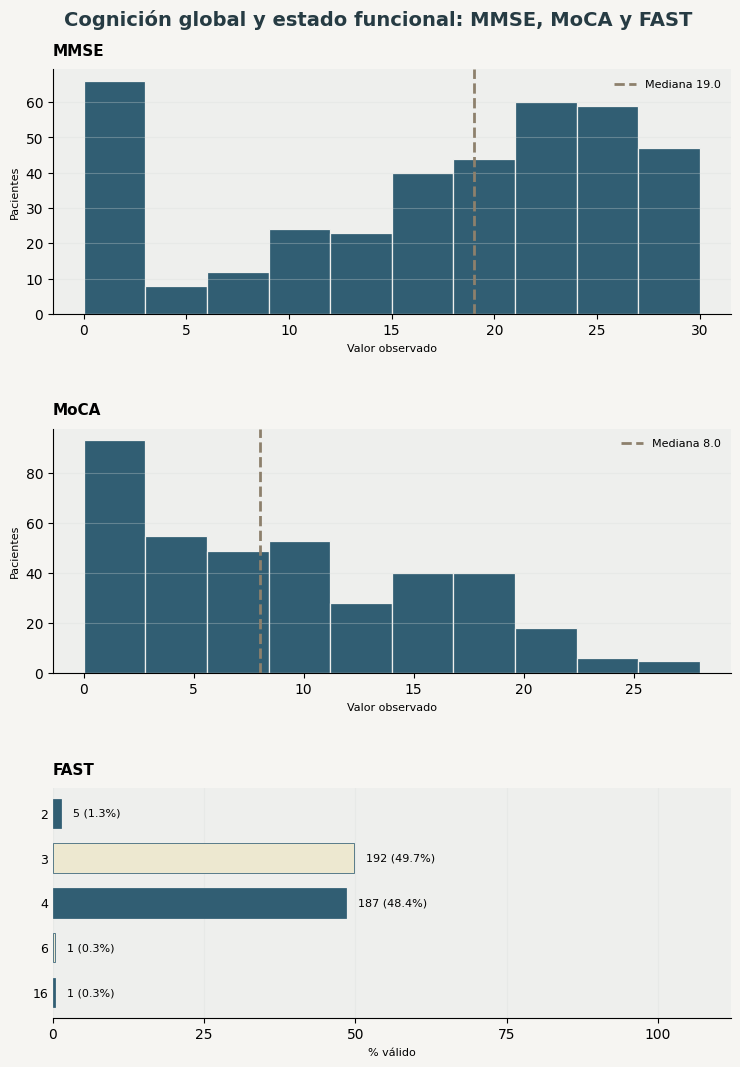

In [57]:
core = [c for c in ('neuro__mmse','moca__moca','neuro__fast') if c in base_full.columns]
analisis_familia(core, 'Cognición global y estado funcional: MMSE, MoCA y FAST')


#### **Hallazgos principales**

### **21.15. Resumen de hallazgos univariados y pendientes**

La sección caracteriza la cohorte completa sin imputar AOO, descartar extremos ni usar pruebas de hipótesis. Para el informe deben conservarse los denominadores de cada variable. Los códigos categóricos no documentados requieren confirmación de su significado y orden; las comorbilidades, medicación y medidas clínicas requieren confirmar si precedieron al inicio. El riesgo de leakage consignado en el diccionario orienta su uso futuro, pero no modifica estas descripciones.


In [58]:
resumen_21=pd.DataFrame([{'pacientes':len(base_full),'AOO_disponible':base_full.aoo.notna().sum(),
    'variables_clinicas_inventariadas':(~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA'])).sum(),
    'variables_sin_asignacion_validada':(inventario.familia=='sin_asignacion_validada').sum(),
    'neuropsicologicas_revisadas':len(calidad_nps_21)}])
display(resumen_21)
pendientes_familia = inventario.loc[inventario.familia.eq('sin_asignacion_validada'),
    ['etiqueta','fuente','tipo_analitico','observacion']].reset_index(drop=True)
if pendientes_familia.empty:
    display(Markdown('**Asignación por familia:** todas las variables integradas quedaron asignadas.'))
else:
    display(Markdown('**Variables pendientes de asignación por familia:**'))
    display(pendientes_familia)
assert len(base_full)==391 and base_full.id.is_unique
assert not any(c in inventario.columna.values for c in ['match_neuro','match_moca','aoo_original','aoo_actualizada'])


,pacientes,AOO_disponible,variables_clinicas_inventariadas,variables_sin_asignacion_validada,neuropsicologicas_revisadas
0,391,332,144,0,57


**Asignación por familia:** todas las variables integradas quedaron asignadas.

## **22. Análisis bivariado (relación de cada variable con la AOO)**

Este análisis retoma exactamente las familias de variables ya descritas univariadamente en la Sección 21 (`inventario`, `GRUPOS_DEMO`, `GRUPOS_NEURO`, `base_full`) y evalúa, variable por variable, su asociación estadística con la **Edad de Inicio (AOO)**. No se incorporan variables nuevas ni se modifica la clasificación analítica ya construida: se prueba únicamente lo que ya fue inventariado y descrito.

**Decisiones metodológicas:**

- **Unidad de análisis:** se usan pares completos por variable (`base_full[[variable, 'aoo']].dropna()`), sin imputar y sin eliminar valores extremos. Esto preserva el mismo principio de la Sección 21 de declarar siempre el denominador efectivo de cada prueba (`n`), que varía de una variable a otra según sus propios faltantes y los de la AOO (85.2% de disponibilidad, preliminar).
- **Pruebas no paramétricas:** se usan pruebas de rangos (Spearman, U de Mann-Whitney, Kruskal-Wallis) en lugar de pruebas paramétricas (Pearson, t, ANOVA), consistente con el uso de correlación de Spearman ya adoptado en la Sección 20 y con la naturaleza no necesariamente normal de la AOO y de varias covariables ordinales/discretas.
- **Corrección por comparaciones múltiples:** dado el número de pruebas realizadas, todos los p-valores se corrigen conjuntamente por FDR (Benjamini-Hochberg) en la Sección 22.15, evitando interpretar como "hallazgo" cualquier p<0.05 aislado.
- **Riesgo de leakage como filtro de interpretación, no de exclusión:** todas las variables se prueban, incluidas las de riesgo "Alto" o "Potencial" (p. ej. MMSE, MoCA, FAST, comorbilidades sin temporalidad confirmada). Una asociación estadísticamente significativa en esas variables **no se interpreta como factor de riesgo** para una AOO más temprana o tardía, sino como covariación entre el estado clínico actual y la AOO. La columna `riesgo_leakage_aoo` del inventario acompaña cada resultado para que esta distinción sea explícita en todo momento.
- **No se prueban:** identificadores, variables auxiliares del EDA (`edad de inicio`/`edad de inicio actualizada`, que son insumos de la propia AOO), variables de texto libre/alta cardinalidad, variables constantes, y variables cuyo `n` efectivo o cuyo tamaño de grupo sea insuficiente. Estas exclusiones se documentan explícitamente por variable en la tabla de resultados (columna `motivo`) y se resumen en la Sección 22.16.
- **Las celdas «Hallazgos principales» se dejan en blanco intencionalmente**, igual que en la Sección 21: deben completarse tras ejecutar el notebook con los archivos fuente, inspeccionando las tablas y gráficos generados.


### **22.1. Criterios metodológicos y funciones auxiliares del bivariado**

La prueba usada por variable depende de `tipo_analitico` (ya definido en el inventario de la Sección 21):

- `cuantitativa continua` / `cuantitativa discreta`: correlación de Spearman con AOO.
- `ordinal`: se intenta primero como numérica (si ≥80% de los valores no faltantes son convertibles a número, se asume que la codificación ordinal ya es numérica y se usa Spearman); si no, se trata como categórica sin orden validado (se documenta explícitamente) y se compara por grupos.
- `categórica binaria` (2 categorías con n suficiente): U de Mann-Whitney, con r biserial por rangos como medida de efecto.
- `categórica nominal` (≥3 categorías con n suficiente): Kruskal-Wallis, con épsilon al cuadrado como medida de efecto.
- `identificador`, `variable auxiliar del EDA`, `texto libre / alta cardinalidad`: no se prueban formalmente.

Las categorías con menos de `n_min_grupo` pacientes se excluyen de la prueba de grupos (no del inventario ni de la cohorte) y quedan fuera del cálculo de `k`; esto se documenta si reduce el número de grupos comparados.


In [59]:
assert len(base_full) == 391 and base_full['id'].is_unique, 'Revisar la cohorte maestra antes de continuar.'
assert 'aoo' in base_full and 'riesgo_leakage_aoo' in inventario.columns

def prueba_bivariada_aoo(col, y_col='aoo', n_min=10, n_min_grupo=3):
    """Evalúa la asociación bivariada entre `col` y la AOO usando pares completos.
    Devuelve un diccionario con la prueba usada, el estadístico, el p-valor, n y
    una medida de efecto. No imputa ni elimina extremos; documenta en 'motivo'
    por qué una variable no resultó evaluable."""
    meta = inventario.set_index('columna')
    if col not in meta.index:
        return {'variable': col, 'columna': col, 'evaluable': False, 'motivo': 'fuera de inventario'}

    tipo = meta.loc[col, 'tipo_analitico']
    familia = meta.loc[col, 'familia']
    leakage = meta.loc[col, 'riesgo_leakage_aoo']
    nombre = etiqueta_bonita(col)
    x = serie_univariada(col)
    y = base_full[y_col]
    base_res = {'variable': nombre, 'columna': col, 'familia': familia,
                'tipo_analitico': tipo, 'riesgo_leakage_aoo': leakage}

    if tipo in ('texto libre / alta cardinalidad', 'identificador', 'variable auxiliar del EDA'):
        return {**base_res, 'evaluable': False, 'motivo': 'tipo no apto para prueba formal'}

    # ¿Se trata como numérica (continua/discreta, u ordinal con codificación numérica)?
    tratar_como_numerica = tipo.startswith('cuantitativa')
    orden_validado = True
    if tipo == 'ordinal':
        xn_prueba = pd.to_numeric(x, errors='coerce')
        n_no_falt = x.notna().sum()
        if n_no_falt and (xn_prueba.notna().sum() / n_no_falt) >= .8:
            tratar_como_numerica = True
        else:
            orden_validado = False  # se prueba como nominal; el orden textual no está codificado

    if tratar_como_numerica:
        xn = pd.to_numeric(x, errors='coerce')
        pares = pd.DataFrame({'x': xn, 'y': y}).dropna()
        n = len(pares)
        if xn.nunique(dropna=True) <= 1:
            return {**base_res, 'evaluable': False, 'motivo': 'sin variación observable', 'n': n}
        if n < n_min:
            return {**base_res, 'evaluable': False, 'motivo': f'n insuficiente ({n}<{n_min})', 'n': n}
        rho, p = stats.spearmanr(pares.x, pares.y)
        return {**base_res, 'evaluable': True, 'prueba': 'Spearman', 'n': n, 'estadistico': rho,
                'p_valor': p, 'medida_efecto': rho, 'medida_efecto_nombre': 'rho de Spearman'}

    # Categórica (nominal, binaria, u ordinal sin orden numérico validado)
    cat = x.dropna().astype(str)
    pares = pd.DataFrame({'grupo': cat, 'y': y}).dropna()
    conteo = pares.grupo.value_counts()
    grupos_validos = conteo[conteo >= n_min_grupo].index
    pares = pares[pares.grupo.isin(grupos_validos)]
    k = pares.grupo.nunique(); n = len(pares)
    nota = '' if orden_validado else 'orden textual no validado numéricamente; tratada como nominal'
    if k < 2:
        return {**base_res, 'evaluable': False,
                'motivo': f'menos de 2 categorías con n>={n_min_grupo}', 'n': n}
    muestras = [g['y'].to_numpy() for _, g in pares.groupby('grupo')]
    medianas = pares.groupby('grupo')['y'].median().round(1).to_dict()
    if k == 2:
        a, b = muestras
        u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
        rb = 1 - (2 * u) / (len(a) * len(b))
        return {**base_res, 'evaluable': True, 'prueba': 'U de Mann-Whitney', 'n': n, 'estadistico': u,
                'p_valor': p, 'medida_efecto': rb, 'medida_efecto_nombre': 'r biserial por rangos',
                'medianas_por_grupo': medianas, 'nota': nota}
    h, p = stats.kruskal(*muestras)
    eps2 = (h - k + 1) / (n - k) if n > k else np.nan
    return {**base_res, 'evaluable': True, 'prueba': f'Kruskal-Wallis (k={k})', 'n': n, 'estadistico': h,
            'p_valor': p, 'medida_efecto': eps2, 'medida_efecto_nombre': 'épsilon cuadrado',
            'medianas_por_grupo': medianas, 'nota': nota}


def panel_bivariado_numerico(ax, x, y, titulo):
    xn = pd.to_numeric(x, errors='coerce')
    pares = pd.DataFrame({'x': xn, 'y': y}).dropna()
    ax.set_facecolor(FONDO_PANEL)
    ax.set_title(fill(titulo, 60), loc='left', fontsize=11, fontweight='bold', pad=10)
    if len(pares) < 3:
        ax.text(.5, .5, 'Datos insuficientes', ha='center', va='center', transform=ax.transAxes); return
    ax.scatter(pares.x, pares.y, s=22, color=COLOR, alpha=.55, edgecolor='white',
               linewidth=.4, zorder=3)
    try:
        m, b = np.polyfit(pares.x, pares.y, 1)
        xs = np.linspace(pares.x.min(), pares.x.max(), 50)
        ax.plot(xs, m * xs + b, color='#8d806c', lw=2, ls='--', zorder=4)
    except Exception:
        pass
    rho, p = stats.spearmanr(pares.x, pares.y)
    ax.text(.02, .96, f'rho={rho:.2f}  p={p:.3f}  n={len(pares)}', transform=ax.transAxes,
            va='top', fontsize=8, bbox=dict(boxstyle='round', fc='white', ec='none', alpha=.75))
    ax.set_xlabel(titulo, fontsize=8); ax.set_ylabel('AOO (años)', fontsize=8)
    ax.grid(color='#d8dcda', lw=.8); ax.spines[['top', 'right']].set_visible(False)


def panel_bivariado_categorico(ax, cat, y, titulo, ordinal=False, max_categorias=8):
    pares = pd.DataFrame({'grupo': cat.dropna().astype(str), 'y': y}).dropna()
    ax.set_facecolor(FONDO_PANEL)
    ax.set_title(fill(titulo, 60), loc='left', fontsize=11, fontweight='bold', pad=10)
    if pares.empty:
        ax.text(.5, .5, 'Sin datos válidos', ha='center', va='center', transform=ax.transAxes); return
    medianas = pares.groupby('grupo')['y'].median()
    orden = medianas.sort_values(ascending=False).index
    if ordinal:
        numeros = pd.to_numeric(medianas.index.to_series(), errors='coerce')
        if numeros.notna().all():
            orden = numeros.sort_values().index
    categorias = list(orden)[:max_categorias]
    datos = [pares.loc[pares.grupo.eq(c), 'y'].to_numpy() for c in categorias]
    etiquetas = [f'{etiqueta_categoria(c)} (n={len(d)})' for c, d in zip(categorias, datos)]
    bp = ax.boxplot(datos, vert=False, patch_artist=True, widths=.55)
    for j, box in enumerate(bp['boxes']):
        box.set_facecolor(COLOR if j % 2 == 0 else BEIGE); box.set_edgecolor(COLOR)
    for elem in ('whiskers', 'caps'):
        for line in bp[elem]: line.set_color(COLOR)
    for med_ in bp['medians']: med_.set_color('#8d806c'); med_.set_linewidth(2)
    ax.set_yticks(range(1, len(categorias) + 1), etiquetas, fontsize=8)
    ax.set_xlabel('AOO (años)', fontsize=8)
    ax.grid(axis='x', color='#d8dcda', lw=.8); ax.grid(axis='y', visible=False)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    if len(orden) > max_categorias:
        ax.text(0, -.16, f'+{len(orden) - max_categorias} categorías adicionales no graficadas (ver tabla).',
                transform=ax.transAxes, fontsize=8)


def analisis_bivariado_familia(columnas, titulo, acumulador=None):
    """Analogía bivariada de `analisis_familia`: tabla de pruebas AOO~variable
    y paneles gráficos (dispersión para numéricas, cajas por grupo para
    categóricas/ordinales), en lotes de hasta 4 variables por figura."""
    if not columnas:
        print('Sin variables integradas asignadas con seguridad.'); return pd.DataFrame()
    meta = inventario.set_index('columna')
    resultados = [prueba_bivariada_aoo(c) for c in columnas]
    tabla = pd.DataFrame(resultados)
    columnas_mostrar = ['variable', 'tipo_analitico', 'riesgo_leakage_aoo', 'evaluable', 'prueba',
                         'n', 'estadistico', 'medida_efecto', 'medida_efecto_nombre', 'p_valor', 'motivo']
    for c in columnas_mostrar:
        if c not in tabla.columns: tabla[c] = np.nan
    display(Markdown(f'**Pruebas de asociación con AOO — {titulo}**'))
    display(tabla[columnas_mostrar].round(4))
    if acumulador is not None:
        acumulador.extend(resultados)
    graficables = [c for c in columnas if meta.loc[c, 'tipo_analitico']
                   not in ('texto libre / alta cardinalidad', 'identificador', 'variable auxiliar del EDA')]
    for inicio in range(0, len(graficables), 4):
        lote = graficables[inicio:inicio + 4]
        fig, axes = plt.subplots(len(lote), 1, figsize=(8.8, 3.2 * len(lote) + 1.2), squeeze=False)
        fig.patch.set_facecolor(FONDO_FIGURA)
        fig.suptitle(f'{titulo} vs. AOO', fontweight='bold', fontsize=14, y=.995, color='#263b43')
        for ax, col in zip(axes.flat, lote):
            tipo = meta.loc[col, 'tipo_analitico']; nombre = etiqueta_bonita(col)
            s = serie_univariada(col); y = base_full['aoo']
            if tipo.startswith('cuantitativa'):
                panel_bivariado_numerico(ax, s, y, nombre)
            else:
                panel_bivariado_categorico(ax, s, y, nombre, ordinal=(tipo == 'ordinal'))
        fig.subplots_adjust(left=.18, right=.92, top=.93, bottom=.09, hspace=.6)
        plt.show()
    return tabla

# Acumulador global de pruebas evaluables/no evaluables para la Sección 22.15
pruebas_bivariadas_globales = []
print('Funciones bivariadas listas. Acumulador global inicializado.')


Funciones bivariadas listas. Acumulador global inicializado.


### **22.2. AOO y variables sociodemográficas**

Se evalúa si estas variables muestran asociación estadística con la AOO. Una asociación significativa no implica antecedencia temporal confirmada; la columna `riesgo_leakage_aoo` orienta la interpretación de cada resultado.


Variables integradas en la familia: 11


**Pruebas de asociación con AOO — Variables sociodemográficas**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,p_valor,motivo
0,Genero,categórica binaria,Bajo,True,U de Mann-Whitney,332.0,13288.5000,-0.0934,r biserial por rangos,0.1668,NaN
1,Mes y anio de nacimiento,texto libre / alta cardinalidad,Bajo / revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,tipo no apto para prueba formal
2,Edad,cuantitativa continua,Bajo / revisar temporalidad,True,Spearman,332.0,0.8401,0.8401,rho de Spearman,0.0000,NaN
3,Idioma,categórica nominal,Bajo,False,NaN,332.0,NaN,NaN,NaN,NaN,menos de 2 categorías con n>=3
4,Otro idoma,texto libre / alta cardinalidad,Bajo,False,NaN,NaN,NaN,NaN,NaN,NaN,tipo no apto para prueba formal
5,Nivel educativo,ordinal,Bajo,True,Spearman,331.0,-0.1656,-0.1656,rho de Spearman,0.0025,NaN
6,Estado civil,categórica nominal,Bajo / revisar temporalidad,True,Kruskal-Wallis (k=6),332.0,16.4911,0.0352,épsilon cuadrado,0.0056,NaN
7,Estado habitacional,categórica nominal,Bajo / revisar temporalidad,True,Kruskal-Wallis (k=7),332.0,25.4340,0.0598,épsilon cuadrado,0.0003,NaN
8,Nivel de independencia,ordinal,Bajo / revisar temporalidad,True,Spearman,331.0,0.1174,0.1174,rho de Spearman,0.0328,NaN
9,Tipo de residencia,categórica nominal,Bajo / revisar temporalidad,True,U de Mann-Whitney,330.0,3570.0000,0.3254,r biserial por rangos,0.0014,NaN


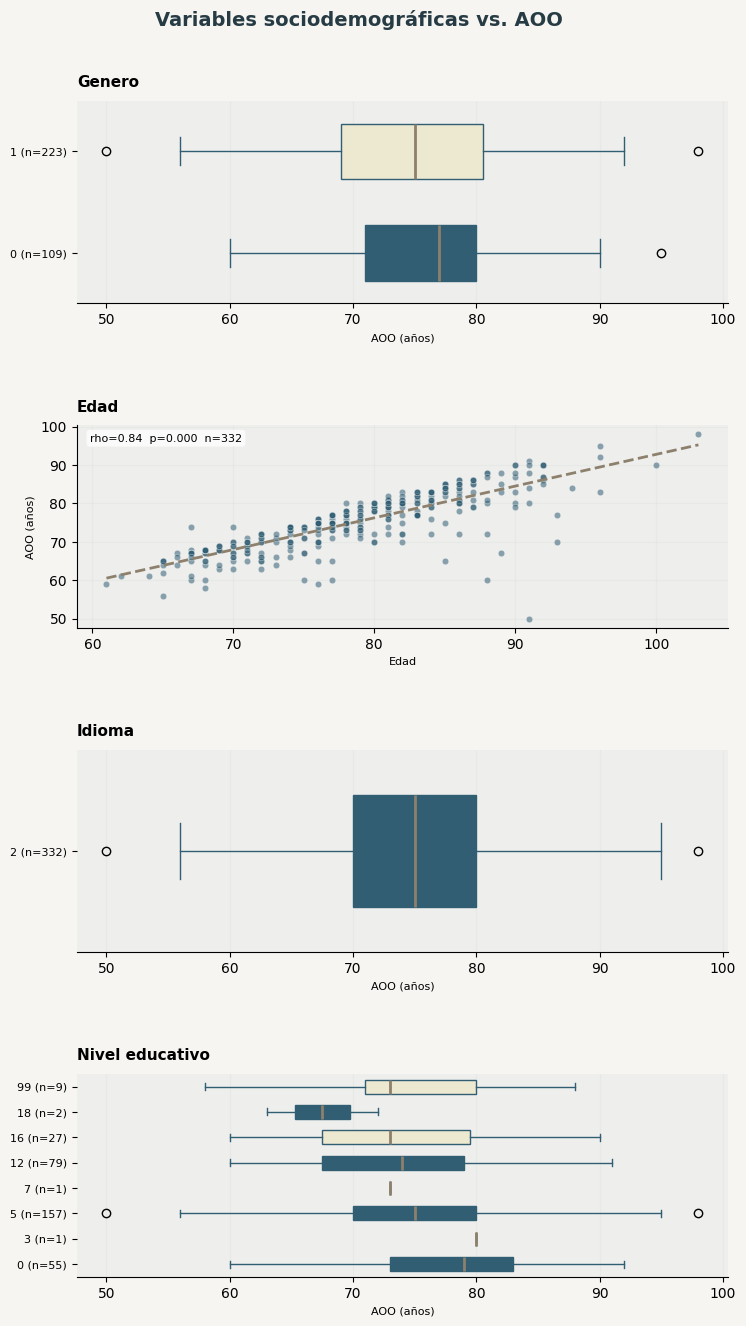

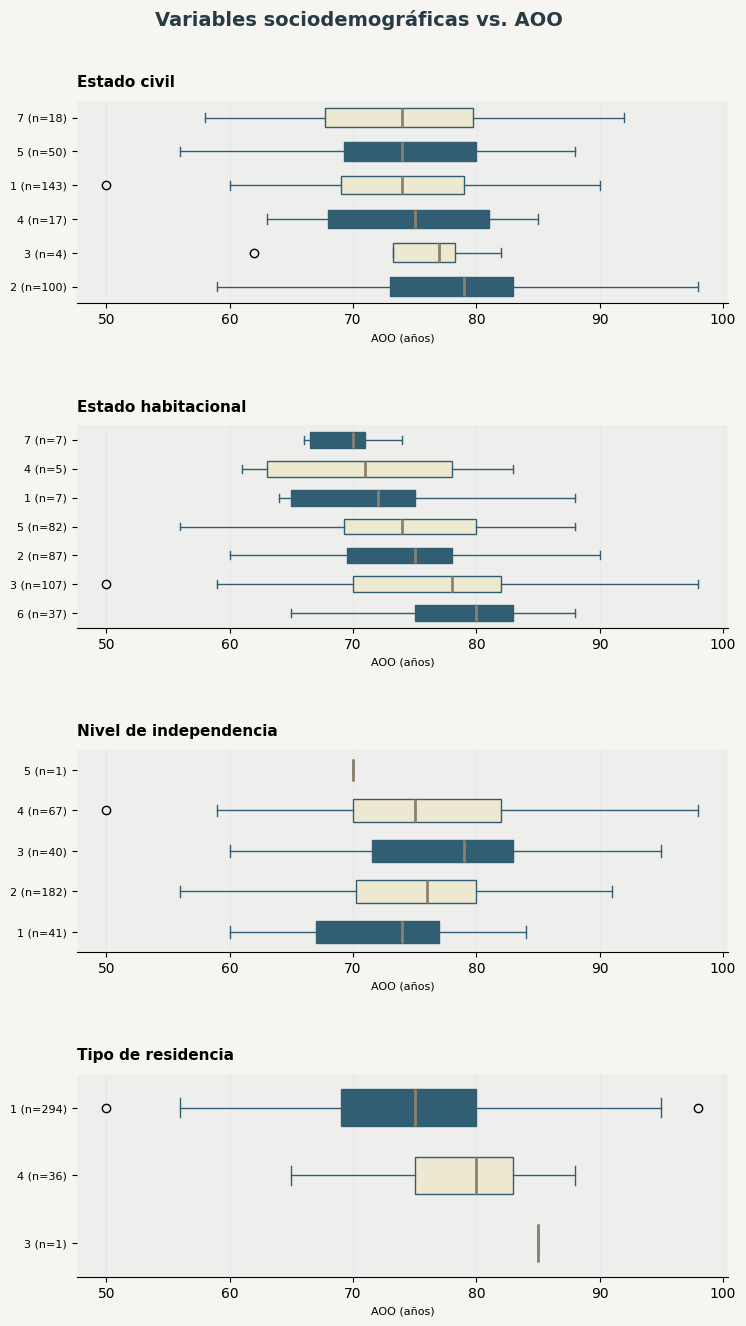

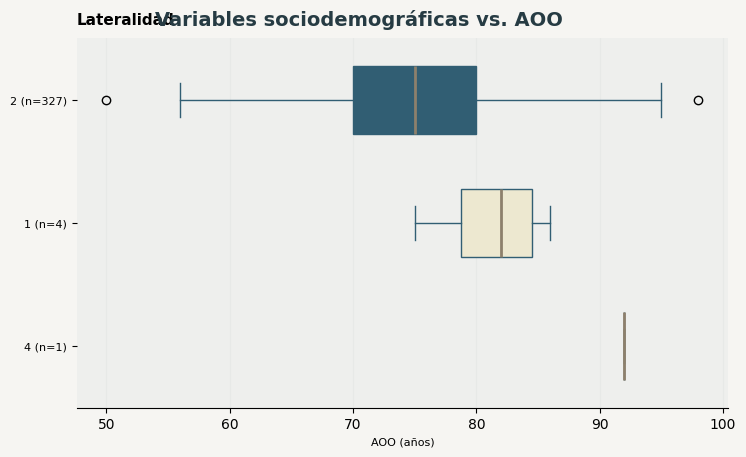

In [60]:
columnas = inventario.loc[(inventario.familia == 'sociodemograficas') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:', len(columnas))
tabla_biv_sociodem = analisis_bivariado_familia(columnas, 'Variables sociodemográficas', pruebas_bivariadas_globales)


#### **Hallazgos principales**


### **22.3. AOO e informante y red de apoyo**

Se evalúa si estas variables muestran asociación estadística con la AOO. Una asociación significativa no implica antecedencia temporal confirmada; la columna `riesgo_leakage_aoo` orienta la interpretación de cada resultado.


Variables integradas en la familia: 5


**Pruebas de asociación con AOO — Informante y red de apoyo**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,p_valor,motivo
0,Relacion del informante,categórica nominal,Revisar temporalidad,True,Kruskal-Wallis (k=6),332.0,14.8094,0.0301,épsilon cuadrado,0.0112,NaN
1,Tiempo anios de conocerce,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,tipo no apto para prueba formal
2,Vive el informante con el sujeto,categórica nominal,Revisar temporalidad,True,Kruskal-Wallis (k=3),330.0,1.4756,-0.0016,épsilon cuadrado,0.4782,NaN
3,Si el informante no vive con el sujeto con que frecuencia visita personalmente al sujeto,ordinal,Revisar temporalidad,True,Kruskal-Wallis (k=4),326.0,7.5687,0.0142,épsilon cuadrado,0.0558,NaN
4,Si el informante no vive con el sujeto con que frecuencia tiene contacto telefonico con el,ordinal,Revisar temporalidad,True,Kruskal-Wallis (k=3),326.0,6.6778,0.0145,épsilon cuadrado,0.0355,NaN


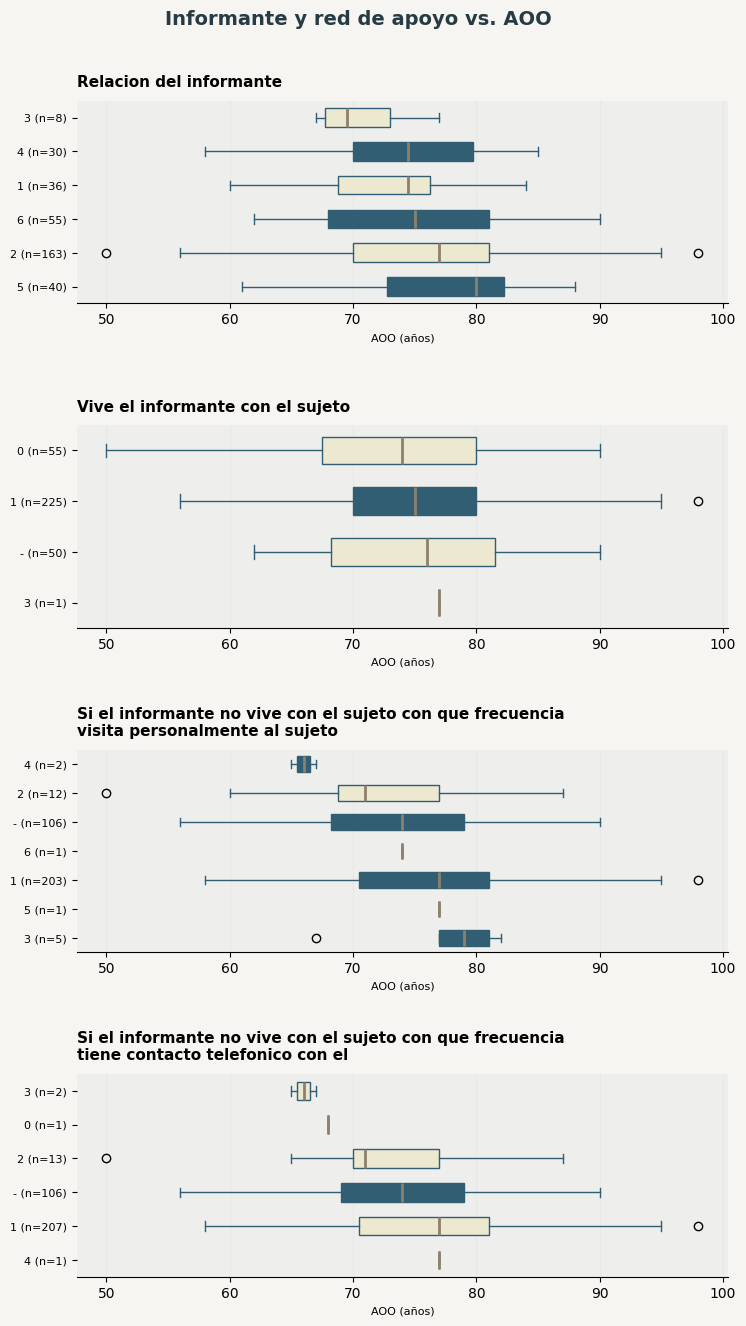

In [61]:
columnas = inventario.loc[(inventario.familia == 'informante_red_apoyo') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:', len(columnas))
tabla_biv_informante = analisis_bivariado_familia(columnas, 'Informante y red de apoyo', pruebas_bivariadas_globales)


#### **Hallazgos principales**


### **22.4. AOO e historia familiar**

Se evalúa si estas variables muestran asociación estadística con la AOO. Una asociación significativa no implica antecedencia temporal confirmada; la columna `riesgo_leakage_aoo` orienta la interpretación de cada resultado.


Variables integradas en la familia: 2


**Pruebas de asociación con AOO — Historia familiar**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,p_valor,motivo
0,Hay miembros afectados de la familia padres biologicos hermanos consanguineos completos comparten ambos padres o hij...,categórica nominal,Bajo / revisar temporalidad,True,Kruskal-Wallis (k=4),330,3.6228,0.0019,épsilon cuadrado,0.3052,NaN
1,Familiar afectado,categórica nominal,Bajo,True,Kruskal-Wallis (k=7),327,10.1386,0.0129,épsilon cuadrado,0.1189,NaN


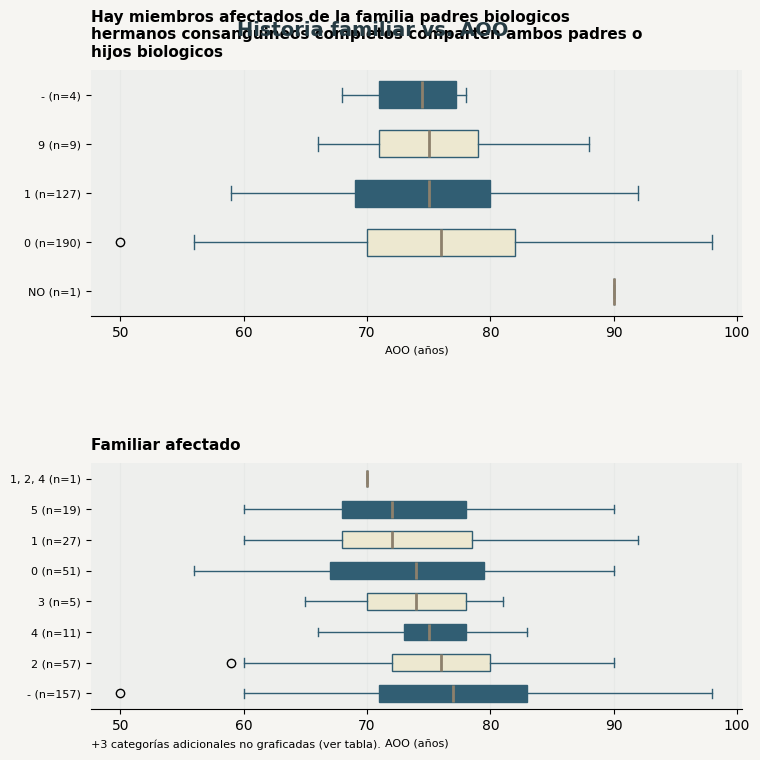

In [62]:
columnas = inventario.loc[(inventario.familia == 'historia_familiar') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:', len(columnas))
tabla_biv_historia_familiar = analisis_bivariado_familia(columnas, 'Historia familiar', pruebas_bivariadas_globales)


#### **Hallazgos principales**


### **22.5. AOO y antropometría**

Se evalúa si estas variables muestran asociación estadística con la AOO. Una asociación significativa no implica antecedencia temporal confirmada; la columna `riesgo_leakage_aoo` orienta la interpretación de cada resultado.


Variables integradas en la familia: 2


**Pruebas de asociación con AOO — Antropometría**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,p_valor,motivo
0,Peso,cuantitativa continua,Revisar temporalidad,True,Spearman,258,0.027,0.027,rho de Spearman,0.6664,NaN
1,Talla,cuantitativa continua,Revisar temporalidad,True,Spearman,297,0.089,0.089,rho de Spearman,0.1258,NaN


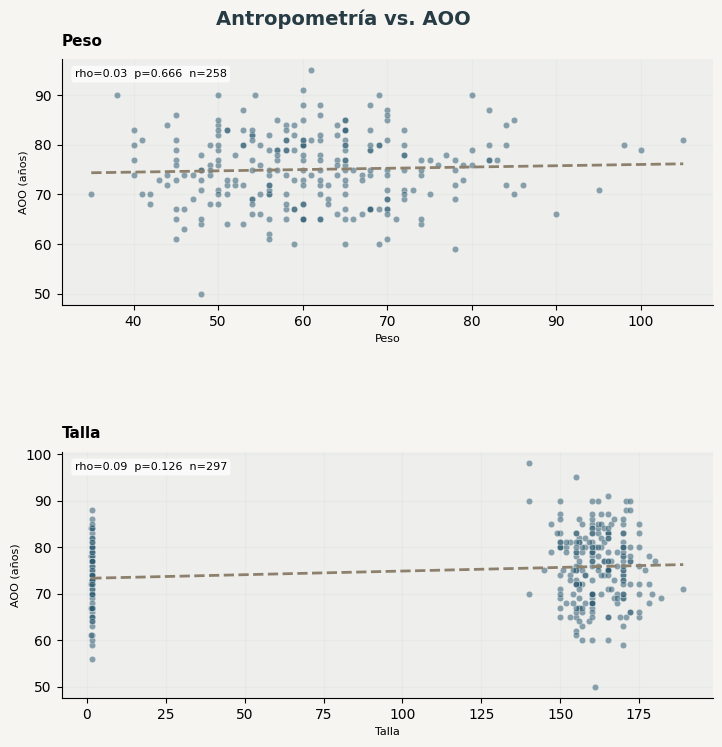

In [63]:
columnas = inventario.loc[(inventario.familia == 'antropometria') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:', len(columnas))
tabla_biv_antropometria = analisis_bivariado_familia(columnas, 'Antropometría', pruebas_bivariadas_globales)


#### **Hallazgos principales**


### **22.6. AOO y medicamentos**

Se evalúa si estas variables muestran asociación estadística con la AOO. Una asociación significativa no implica antecedencia temporal confirmada; la columna `riesgo_leakage_aoo` orienta la interpretación de cada resultado.


In [64]:
columnas = inventario.loc[(inventario.familia == 'medicamentos') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:', len(columnas))
tabla_biv_medicamentos = analisis_bivariado_familia(columnas, 'Medicamentos', pruebas_bivariadas_globales)


Variables integradas en la familia: 9


**Pruebas de asociación con AOO — Medicamentos**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,p_valor,motivo
0,Medicamento del sujeto 1,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,tipo no apto para prueba formal
1,Medicamento del sujeto 2,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,tipo no apto para prueba formal
2,Medicamento del sujeto 3,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,tipo no apto para prueba formal
3,Medicamento del sujeto 4,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,tipo no apto para prueba formal
4,Medicamento del sujeto 5,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,tipo no apto para prueba formal
5,Medicamento del sujeto 6,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,tipo no apto para prueba formal
6,Medicamento del sujeto 7,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,tipo no apto para prueba formal
7,Medicamento del sujeto 8,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,tipo no apto para prueba formal
8,Medicamento del sujeto 9,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,tipo no apto para prueba formal


#### **Hallazgos principales**


### **22.7. AOO y tabaquismo/hábitos**

Se usa `serie_univariada`, que ya recodifica el código 99 de años de tabaquismo como faltante para esta vista, sin alterar la columna original.


Variables integradas en la familia: 3


**Pruebas de asociación con AOO — Tabaquismo y hábitos**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,p_valor,motivo
0,El sujeto ha fumado en los pasados 30 dias,categórica nominal,Revisar temporalidad,True,Kruskal-Wallis (k=3),331,1.1892,-0.0025,épsilon cuadrado,0.5518,NaN
1,El sujeto ha fumado mas de 100 cigarros cigarrillos en su vida,categórica nominal,Revisar temporalidad,True,Kruskal-Wallis (k=3),330,1.0370,-0.0029,épsilon cuadrado,0.5954,NaN
2,Numero total de anios que ha fumado el sujeto 99 desconocido,cuantitativa continua,Revisar temporalidad,True,Spearman,294,0.0726,0.0726,rho de Spearman,0.2144,NaN


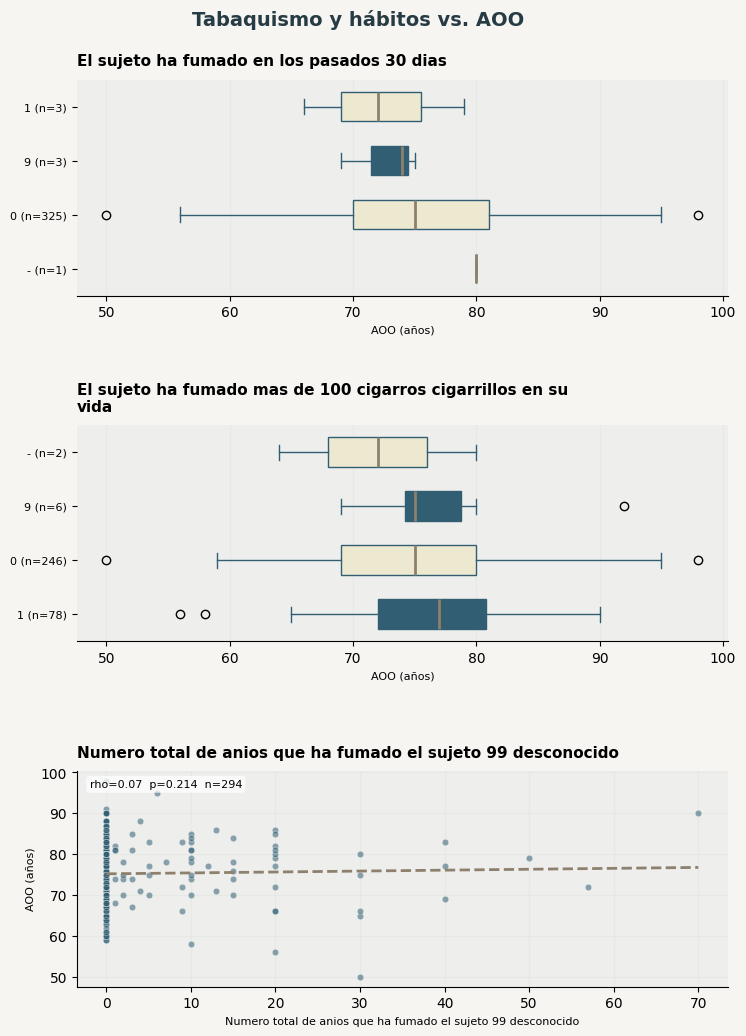

In [65]:
columnas = inventario.loc[(inventario.familia == 'tabaquismo') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:', len(columnas))
tabla_biv_tabaquismo = analisis_bivariado_familia(columnas, 'Tabaquismo y hábitos', pruebas_bivariadas_globales)


#### **Hallazgos principales**


### **22.8. AOO y antecedentes cardiovasculares/cerebrovasculares**

Se evalúa si estas variables muestran asociación estadística con la AOO. Una asociación significativa no implica antecedencia temporal confirmada; la columna `riesgo_leakage_aoo` orienta la interpretación de cada resultado.


Variables integradas en la familia: 7


**Pruebas de asociación con AOO — Antecedentes cardiovasculares y cerebrovasculares**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,p_valor,motivo
0,Ataque cardiaco o paro cardiaco,categórica binaria,Revisar temporalidad,True,U de Mann-Whitney,331,1220.0,-0.2513,r biserial por rangos,0.2920,NaN
1,Fibrilacion auricular,categórica binaria,Revisar temporalidad,True,U de Mann-Whitney,331,448.5,0.5400,r biserial por rangos,0.0234,NaN
2,Angioplastia endarterectomia stent,categórica nominal,Revisar temporalidad,False,NaN,332,NaN,NaN,NaN,NaN,menos de 2 categorías con n>=3
3,Bypass cardiaco coronario,categórica binaria,Revisar temporalidad,False,NaN,332,NaN,NaN,NaN,NaN,menos de 2 categorías con n>=3
4,Marcapasos y o desfibrilador,categórica binaria,Revisar temporalidad,True,U de Mann-Whitney,332,637.0,0.2208,r biserial por rangos,0.3976,NaN
5,Insuficiencia cardiaca congestiva,categórica binaria,Revisar temporalidad,True,U de Mann-Whitney,331,272.5,0.4461,r biserial por rangos,0.1840,NaN
6,Enfermedad cerebro vascular ecv,categórica binaria,Revisar temporalidad,True,U de Mann-Whitney,331,1347.5,0.0700,r biserial por rangos,0.7211,NaN


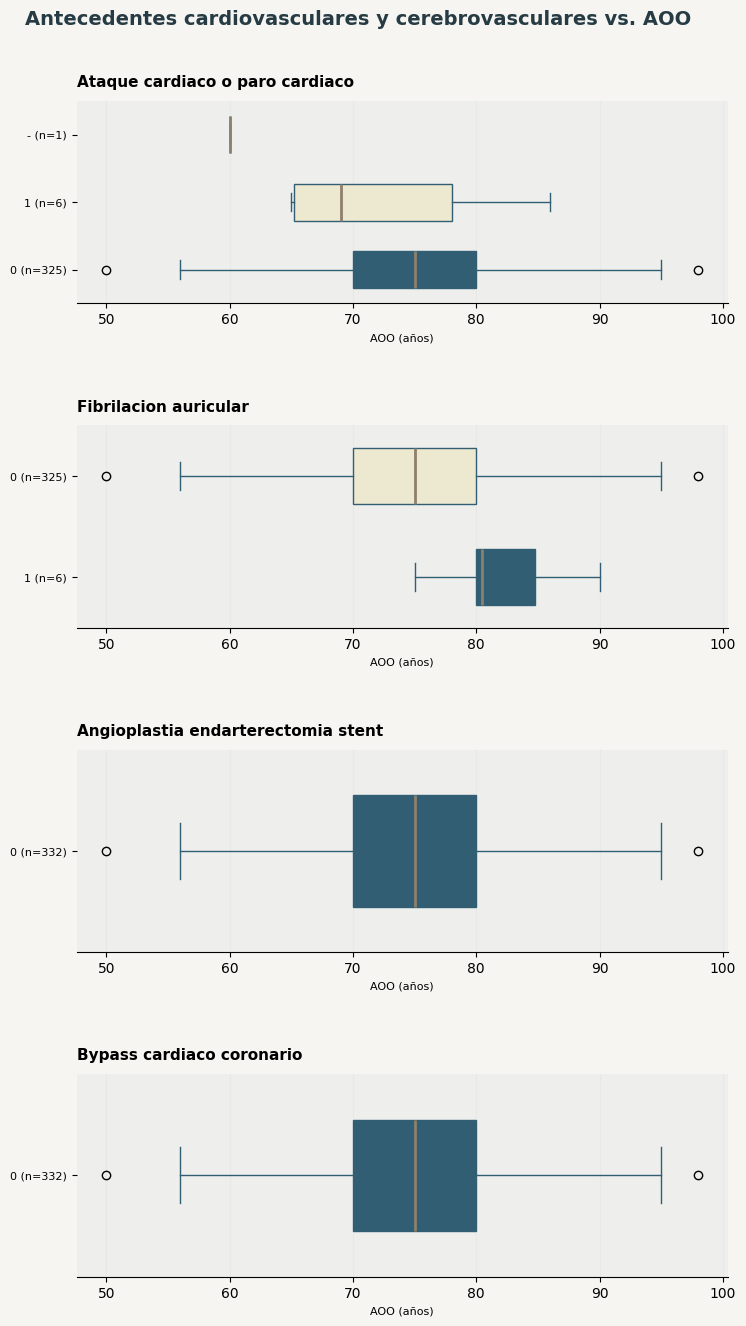

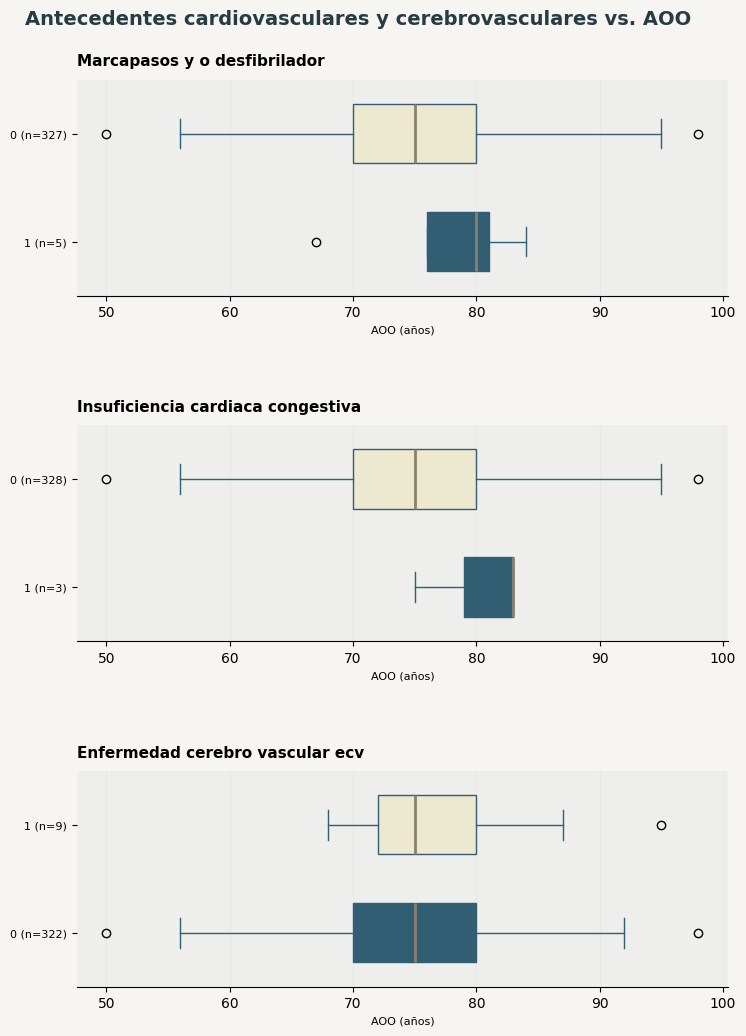

In [66]:
columnas = inventario.loc[(inventario.familia == 'cardiovasculares_cerebrovasculares') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:', len(columnas))
tabla_biv_cardio = analisis_bivariado_familia(columnas, 'Antecedentes cardiovasculares y cerebrovasculares', pruebas_bivariadas_globales)


#### **Hallazgos principales**


### **22.9. AOO y antecedentes neurológicos**

Se evalúa si estas variables muestran asociación estadística con la AOO. Una asociación significativa no implica antecedencia temporal confirmada; la columna `riesgo_leakage_aoo` orienta la interpretación de cada resultado.


Variables integradas en la familia: 3


**Pruebas de asociación con AOO — Antecedentes neurológicos**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,p_valor,motivo
0,Parkinson,categórica binaria,Revisar temporalidad,False,NaN,329,NaN,NaN,NaN,NaN,menos de 2 categorías con n>=3
1,Convulsiones,categórica binaria,Revisar temporalidad,True,U de Mann-Whitney,332,841.0,-0.282,r biserial por rangos,0.3331,NaN
2,Traumatismo de craneo encefalico tce,categórica binaria,Revisar temporalidad,False,NaN,332,NaN,NaN,NaN,NaN,menos de 2 categorías con n>=3


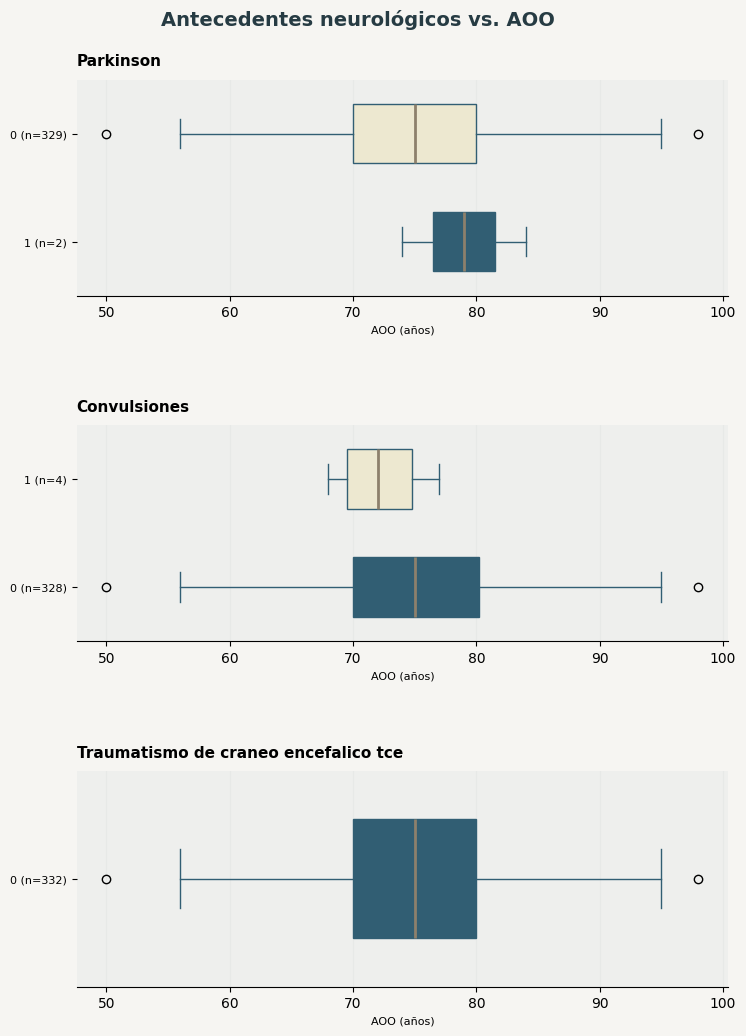

In [67]:
columnas = inventario.loc[(inventario.familia == 'neurologicos') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:', len(columnas))
tabla_biv_neurologicos = analisis_bivariado_familia(columnas, 'Antecedentes neurológicos', pruebas_bivariadas_globales)


#### **Hallazgos principales**


### **22.10. AOO y comorbilidades/condiciones médicas**

Se evalúa si estas variables muestran asociación estadística con la AOO. Una asociación significativa no implica antecedencia temporal confirmada; la columna `riesgo_leakage_aoo` orienta la interpretación de cada resultado.


Variables integradas en la familia: 13


**Pruebas de asociación con AOO — Comorbilidades y condiciones médicas**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,p_valor,motivo
0,Diabetes,categórica nominal,Revisar temporalidad,True,Kruskal-Wallis (k=3),330,1.4886,-0.0016,épsilon cuadrado,0.4751,NaN
1,Cancer,categórica binaria,Revisar temporalidad,True,U de Mann-Whitney,330,613.0000,0.2455,r biserial por rangos,0.3468,NaN
2,Hipercholesterolemia,categórica binaria,Revisar temporalidad,True,U de Mann-Whitney,330,337.5000,0.3119,r biserial por rangos,0.3534,NaN
3,Hipertension arterial,categórica binaria,Revisar temporalidad,True,U de Mann-Whitney,331,10487.5000,0.2223,r biserial por rangos,0.0005,NaN
4,Niveles de vitamina d,categórica nominal,Revisar temporalidad,False,NaN,332,NaN,NaN,NaN,NaN,menos de 2 categorías con n>=3
5,Deficiencia de b12,categórica binaria,Revisar temporalidad,False,NaN,331,NaN,NaN,NaN,NaN,menos de 2 categorías con n>=3
6,Enfermedad tiroidea,categórica binaria,Revisar temporalidad,True,U de Mann-Whitney,332,2780.0000,0.0651,r biserial por rangos,0.6344,NaN
7,Artritis,categórica binaria,Revisar temporalidad,False,NaN,331,NaN,NaN,NaN,NaN,menos de 2 categorías con n>=3
8,Artrosis,categórica binaria,Revisar temporalidad,True,U de Mann-Whitney,332,3305.5000,0.0306,r biserial por rangos,0.8109,NaN
9,Osteoporosis,categórica binaria,Revisar temporalidad,True,U de Mann-Whitney,332,1401.0000,0.0361,r biserial por rangos,0.8546,NaN


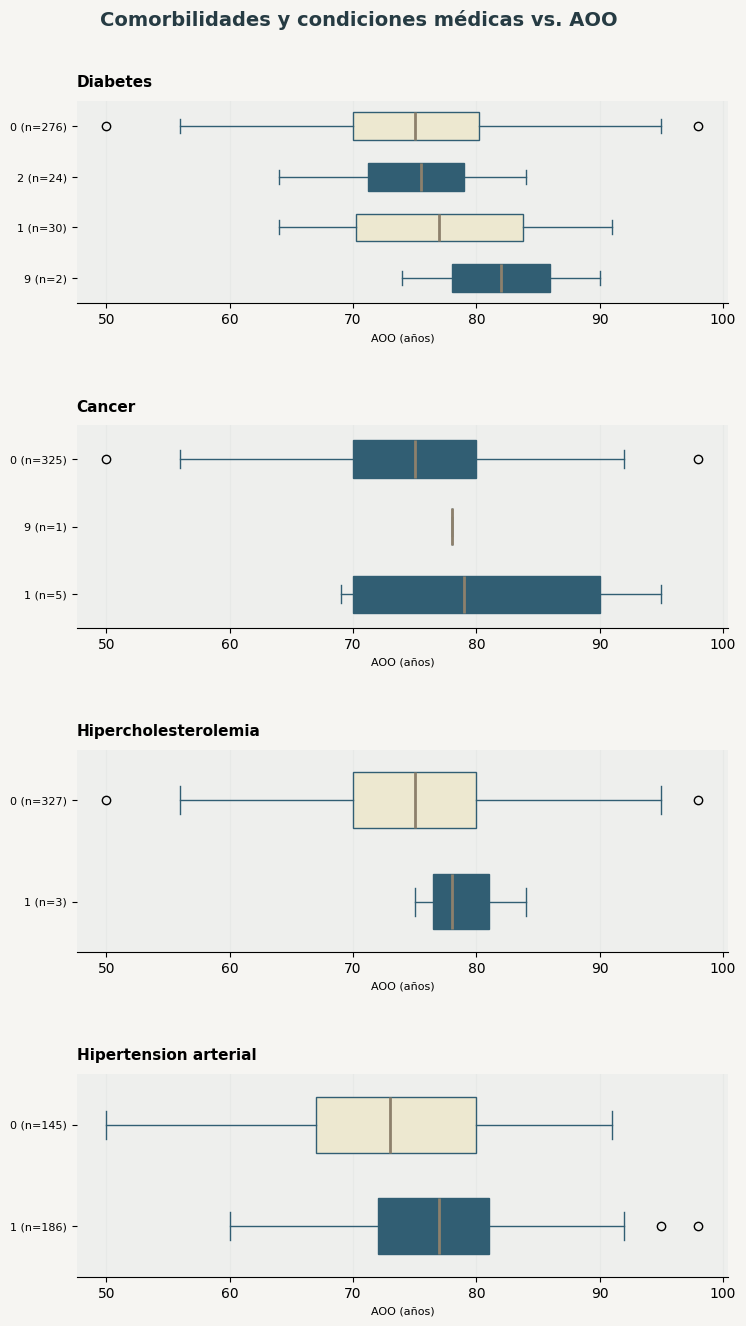

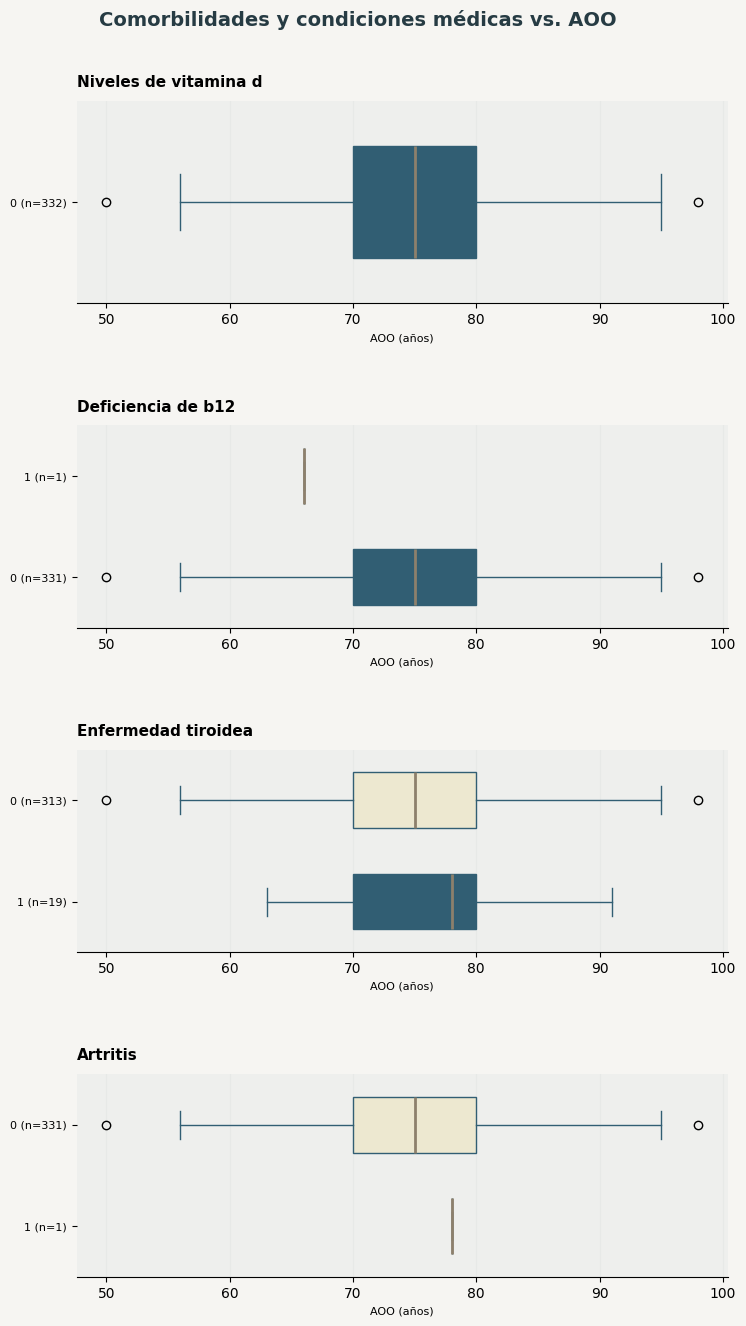

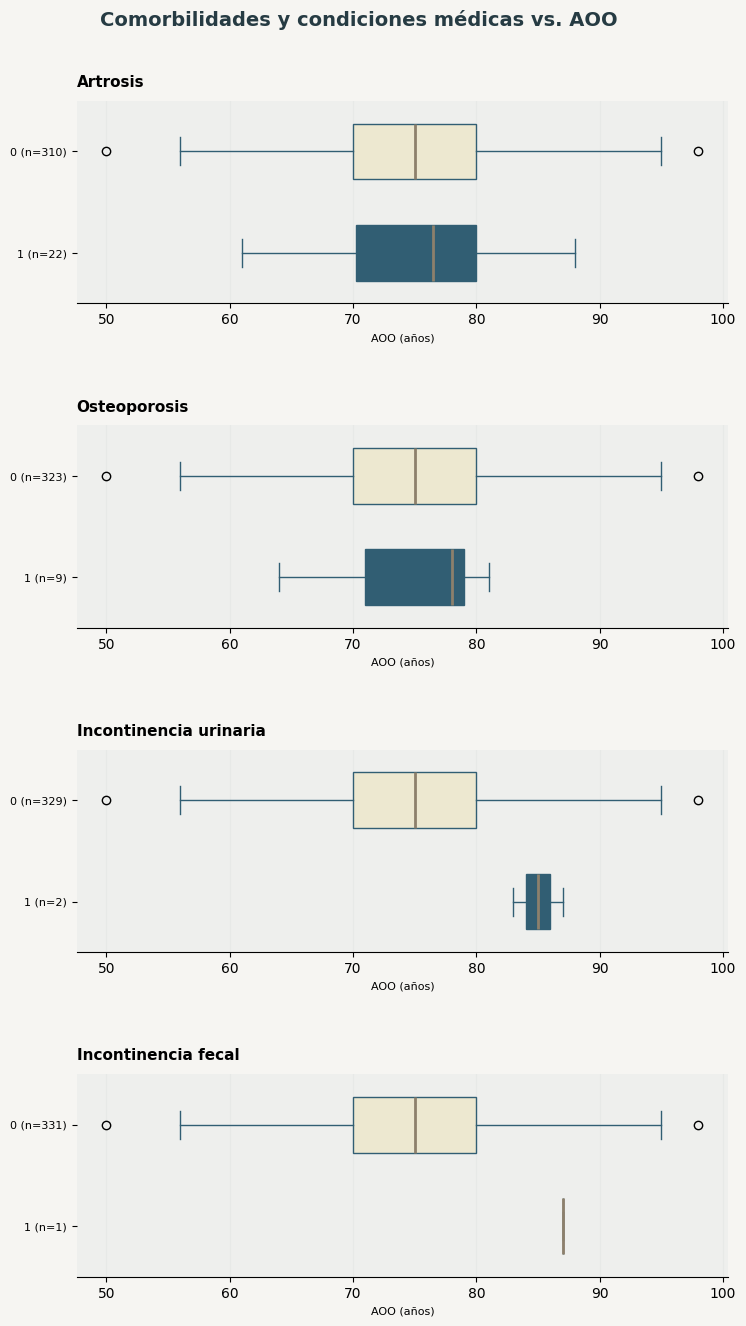

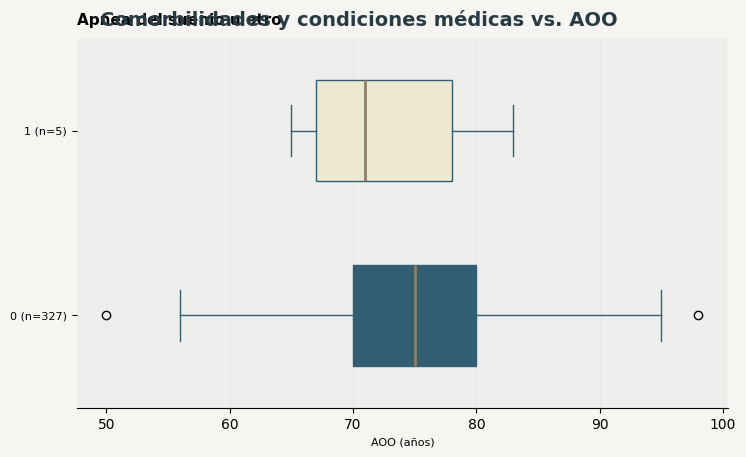

In [68]:
columnas = inventario.loc[(inventario.familia == 'metabolicos_otros') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:', len(columnas))
tabla_biv_comorbilidades = analisis_bivariado_familia(columnas, 'Comorbilidades y condiciones médicas', pruebas_bivariadas_globales)


#### **Hallazgos principales**


### **22.11. AOO y antecedentes psiquiátricos**

Se evalúa si estas variables muestran asociación estadística con la AOO. Una asociación significativa no implica antecedencia temporal confirmada; la columna `riesgo_leakage_aoo` orienta la interpretación de cada resultado.


Variables integradas en la familia: 7


**Pruebas de asociación con AOO — Antecedentes psiquiátricos**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,p_valor,motivo
0,Trastorno de estres postraumatico tept,categórica binaria,Revisar temporalidad,False,NaN,331,NaN,NaN,NaN,NaN,menos de 2 categorías con n>=3
1,Trastorno bipolar,categórica binaria,Revisar temporalidad,False,NaN,332,NaN,NaN,NaN,NaN,menos de 2 categorías con n>=3
2,Esquizofrenia,categórica binaria,Revisar temporalidad,False,NaN,329,NaN,NaN,NaN,NaN,menos de 2 categorías con n>=3
3,Depresion,categórica binaria,Revisar temporalidad,True,U de Mann-Whitney,331,1217.0,-0.2482,r biserial por rangos,0.2980,NaN
4,Ansiedad,categórica binaria,Revisar temporalidad,True,U de Mann-Whitney,332,990.5,-0.5099,r biserial por rangos,0.0797,NaN
5,Trastorno obsesivo compulsivo toc,categórica binaria,Revisar temporalidad,False,NaN,332,NaN,NaN,NaN,NaN,menos de 2 categorías con n>=3
6,Trastornos neuropsiquiatricos del desarrollo por ejemplo trastorno del espectro autista tea deficit de atencion con ...,categórica binaria,Revisar temporalidad,False,NaN,332,NaN,NaN,NaN,NaN,menos de 2 categorías con n>=3


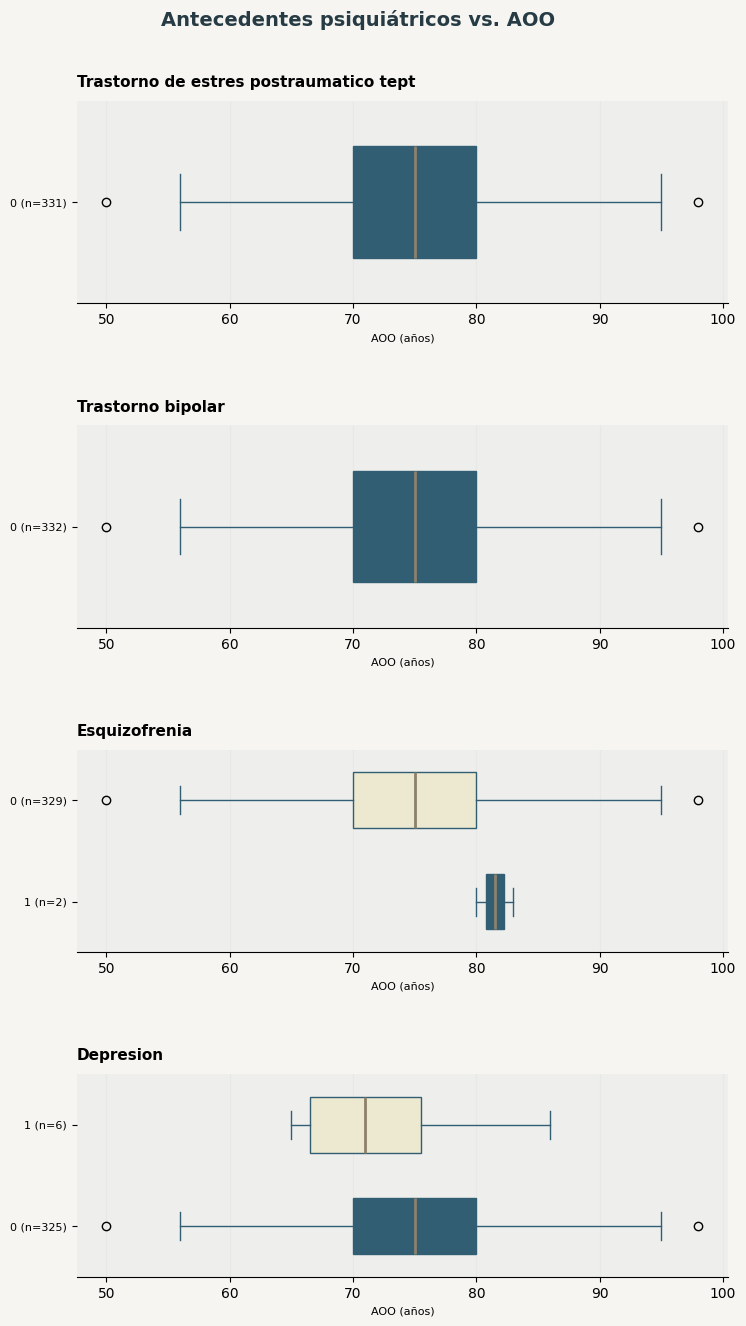

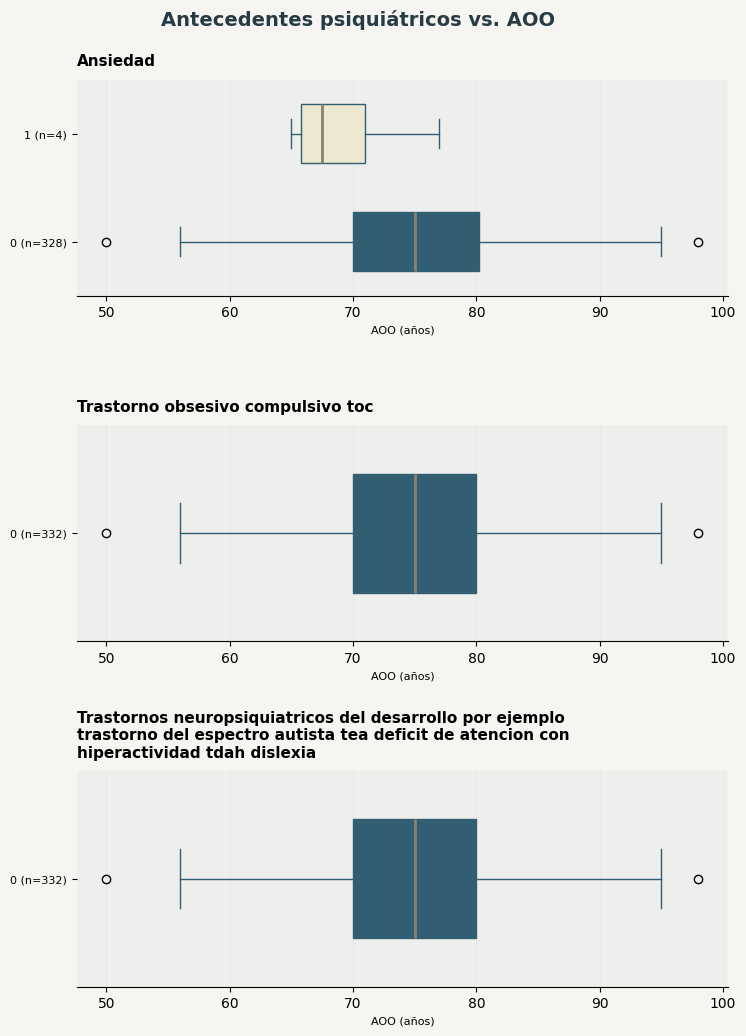

In [69]:
columnas = inventario.loc[(inventario.familia == 'psiquiatricos') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:', len(columnas))
tabla_biv_psiquiatricos = analisis_bivariado_familia(columnas, 'Antecedentes psiquiátricos', pruebas_bivariadas_globales)


#### **Hallazgos principales**


### **22.12. AOO y variables clínicas HXGEN**

Estas variables provienen de la cohorte maestra (`hxgen`); su relación con la temporalidad respecto al inicio de la enfermedad aún no está confirmada (riesgo de leakage «Revisar temporalidad» en la mayoría de los casos).


Variables integradas en la familia: 23


**Pruebas de asociación con AOO — Variables clínicas HXGEN**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,p_valor,motivo
0,Edad,cuantitativa continua,Revisar temporalidad,True,Spearman,331.0,0.8249,0.8249,rho de Spearman,0.0000,NaN
1,Ciudad o municipio de residencia,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,tipo no apto para prueba formal
2,Enfermedad actual,texto libre / alta cardinalidad,Alto,False,NaN,NaN,NaN,NaN,NaN,NaN,tipo no apto para prueba formal
3,Que sintomas presenta,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,tipo no apto para prueba formal
4,El paciente necesita apoyo para realizar las siguientes tareas,texto libre / alta cardinalidad,Alto,False,NaN,NaN,NaN,NaN,NaN,NaN,tipo no apto para prueba formal
5,Indique que estudios previos le han realizado,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,tipo no apto para prueba formal
6,Si le han realizado estudios previos encontraron hallazgos cuales,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,tipo no apto para prueba formal
7,Antecedentes,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,tipo no apto para prueba formal
8,Actualmente se encuentra en algun tratamiento farmacologico,categórica nominal,Revisar temporalidad,True,Kruskal-Wallis (k=5),328.0,5.7773,0.0055,épsilon cuadrado,0.2164,NaN
9,Si la respuesta anterior fue si que medicamentos esta consumiendo,texto libre / alta cardinalidad,Revisar temporalidad,False,NaN,NaN,NaN,NaN,NaN,NaN,tipo no apto para prueba formal


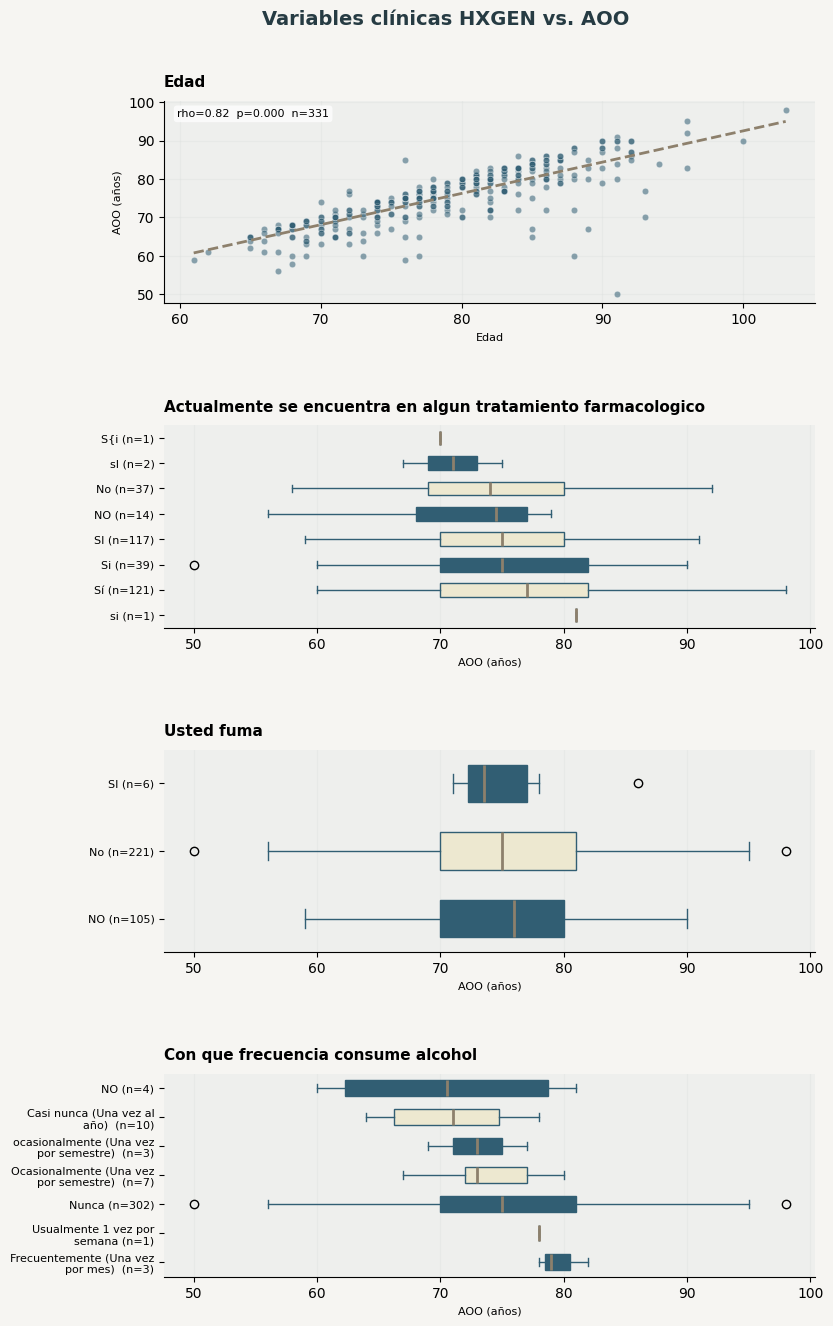

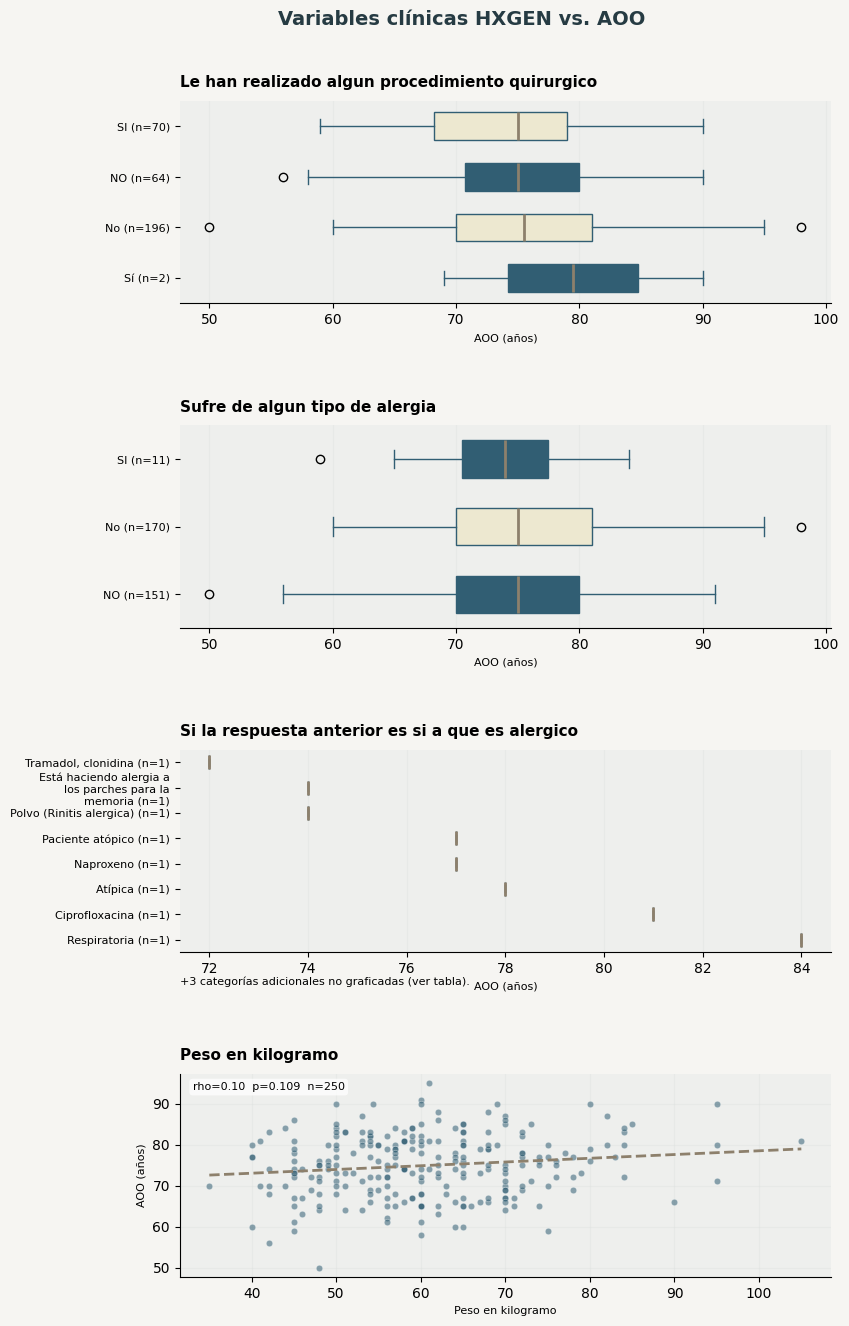

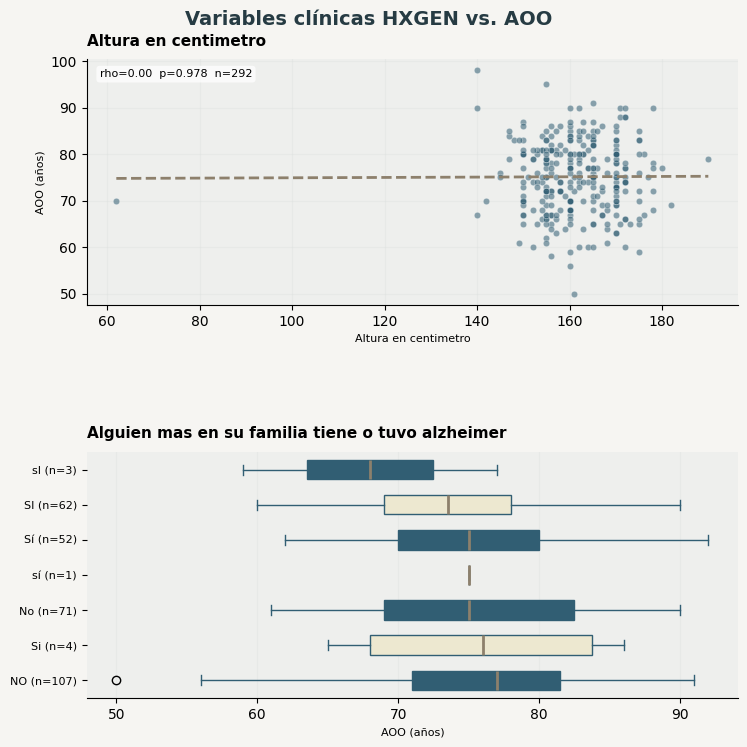

In [70]:
columnas = inventario.loc[(inventario.familia == 'historia_clinica_genetica') &
    ~inventario.tipo_analitico.isin(['identificador','variable auxiliar del EDA']), 'columna'].tolist()
print('Variables integradas en la familia:', len(columnas))
tabla_biv_hxgen = analisis_bivariado_familia(columnas, 'Variables clínicas HXGEN', pruebas_bivariadas_globales)


#### **Hallazgos principales**


### **22.13. Variables neuropsicológicas por dominio vs. AOO**

Siguiendo la misma decisión de diseño de la Sección 21.14, aquí solo se genera una **tabla** de pruebas por dominio (sin un gráfico por variable, dado el volumen de la batería completa). El panel gráfico completo se reserva para MMSE, MoCA y FAST en la Sección 22.14.

**Advertencia de interpretación:** la mayoría de estas variables tiene riesgo de leakage «Alto» o «Potencial» frente a la AOO (columna `riesgo_leakage_aoo` del inventario): son mediciones contemporáneas o posteriores al inicio de la enfermedad. Una correlación con AOO en esta sección **no se interpreta como factor de riesgo** para el inicio temprano o tardío, sino como covariación entre el desempeño cognitivo actual y la edad de inicio.


In [71]:
cols_nps_biv = list(dict.fromkeys([c for c in neuro_norm if c in base_full.columns] +
                                   (['moca__moca'] if 'moca__moca' in base_full.columns else [])))
resultados_nps_biv = [prueba_bivariada_aoo(c) for c in cols_nps_biv]
tabla_nps_biv = pd.DataFrame(resultados_nps_biv)
pruebas_bivariadas_globales.extend(resultados_nps_biv)

columnas_mostrar = ['variable', 'familia', 'tipo_analitico', 'riesgo_leakage_aoo', 'evaluable', 'prueba',
                     'n', 'estadistico', 'medida_efecto', 'medida_efecto_nombre', 'p_valor', 'motivo']
for c in columnas_mostrar:
    if c not in tabla_nps_biv.columns: tabla_nps_biv[c] = np.nan

for dominio, tabla in tabla_nps_biv.groupby('familia', sort=False):
    display(Markdown('**' + dominio.replace('_', ' ').capitalize() + '**'))
    display(tabla[columnas_mostrar].drop(columns='familia').round(4).reset_index(drop=True))

display(Markdown(
    '**Nota de interpretación:** ver advertencia de leakage al inicio de esta subsección. '
    'Las correlaciones de redundancia entre pruebas neuropsicológicas ya figuran en la Sección 20.3 '
    'y no se repiten aquí.'))


**Metadatos nps**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,p_valor,motivo
0,Hay valoracion nps anterior,categórica binaria,Potencial,True,U de Mann-Whitney,326.0,985.5,-0.5303,r biserial por rangos,0.0685,NaN
1,Si tiene anteriormente valoracion nps en que fecha se aplico,texto libre / alta cardinalidad,Potencial,False,NaN,NaN,NaN,NaN,NaN,NaN,tipo no apto para prueba formal


**Cognicion global**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,p_valor,motivo
0,MMSE,cuantitativa discreta,Alto,True,Spearman,329.0,-0.0872,-0.0872,rho de Spearman,0.1144,NaN
1,Esc deterioroglobal,ordinal,Alto,True,Spearman,331.0,-0.0101,-0.0101,rho de Spearman,0.8544,NaN
2,MoCA,cuantitativa discreta,Alto,True,Spearman,331.0,-0.0203,-0.0203,rho de Spearman,0.7134,NaN


**Memoria**

...

**Memoria semantica conocimiento**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,p_valor,motivo
0,Tsmydoral,cuantitativa discreta,Potencial,True,Spearman,307.0,-0.2279,-0.2279,rho de Spearman,0.0001,NaN
1,Tsmyd escr,cuantitativa discreta,Potencial,True,Spearman,307.0,-0.2193,-0.2193,rho de Spearman,0.0001,NaN
2,Benton,cuantitativa discreta,Potencial,True,Spearman,310.0,-0.1641,-0.1641,rho de Spearman,0.0038,NaN


**Funcional afectivo quejas**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,p_valor,motivo
0,Quejas subjetivas,texto libre / alta cardinalidad,Alto,False,NaN,NaN,NaN,NaN,NaN,NaN,tipo no apto para prueba formal
1,Yesavage,cuantitativa discreta,Alto,True,Spearman,318.0,0.0215,0.0215,rho de Spearman,0.7029,NaN
2,Barthel,cuantitativa discreta,Alto,True,Spearman,332.0,-0.0539,-0.0539,rho de Spearman,0.3274,NaN
3,Lawton y brody,cuantitativa discreta,Alto,True,Spearman,332.0,0.1431,0.1431,rho de Spearman,0.0090,NaN
4,Ikatz,cuantitativa discreta,Alto,True,Spearman,332.0,0.0433,0.0433,rho de Spearman,0.4318,NaN
5,FAST,ordinal,Alto,True,Spearman,332.0,0.0376,0.0376,rho de Spearman,0.4949,NaN


**Nota de interpretación:** ver advertencia de leakage al inicio de esta subsección. Las correlaciones de redundancia entre pruebas neuropsicológicas ya figuran en la Sección 20.3 y no se repiten aquí.

#### **Hallazgos principales**


### **22.14. Cognición global y estado funcional (MMSE, MoCA, FAST) vs. AOO**

Panel gráfico completo (dispersión para MMSE y MoCA, cajas por estadio para FAST) para las tres variables priorizadas en la Sección 20.4. Las tres tienen riesgo de leakage «Alto»: se exploran por su relevancia clínica, no como predictores válidos de AOO.


**Pruebas de asociación con AOO — Cognición global y estado funcional: MMSE, MoCA y FAST**

,variable,tipo_analitico,riesgo_leakage_aoo,evaluable,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,p_valor,motivo
0,MMSE,cuantitativa discreta,Alto,True,Spearman,329,-0.0872,-0.0872,rho de Spearman,0.1144,NaN
1,MoCA,cuantitativa discreta,Alto,True,Spearman,331,-0.0203,-0.0203,rho de Spearman,0.7134,NaN
2,FAST,ordinal,Alto,True,Spearman,332,0.0376,0.0376,rho de Spearman,0.4949,NaN


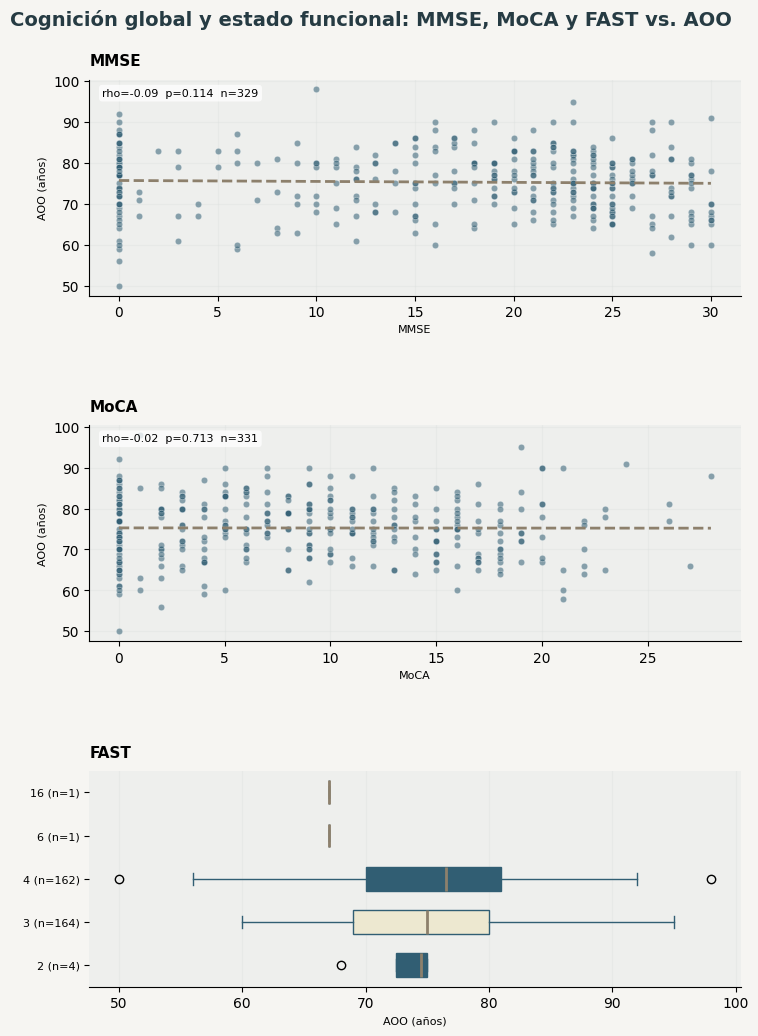

In [72]:
core_bivariado = [c for c in ('neuro__mmse', 'moca__moca', 'neuro__fast') if c in base_full.columns]
tabla_biv_core = analisis_bivariado_familia(
    core_bivariado,
    'Cognición global y estado funcional: MMSE, MoCA y FAST',
    pruebas_bivariadas_globales
)


#### **Hallazgos principales**


### **22.15. Tabla consolidada de asociaciones con AOO y corrección por comparaciones múltiples**

Se consolidan todas las pruebas acumuladas en `pruebas_bivariadas_globales` (una fila por variable única; si una variable fue probada en más de una subsección —p. ej. MMSE, MoCA o FAST, presentes tanto en 22.13 como en 22.14— se conserva un único registro). Sobre el conjunto de pruebas evaluables se aplica la corrección de Benjamini-Hochberg (FDR) para controlar la tasa de falsos descubrimientos dado el número de comparaciones realizadas.

Los resultados se presentan también segmentados por `riesgo_leakage_aoo`, para separar explícitamente las asociaciones más interpretables como posibles covariables previas al inicio (riesgo «Bajo») de aquellas que reflejan sobre todo el estado clínico actual (riesgo «Alto»/«Potencial») o que requieren validar la temporalidad («Revisar temporalidad»).


In [73]:
tabla_global_bivariado = (pd.DataFrame(pruebas_bivariadas_globales)
                           .drop_duplicates(subset='columna')
                           .reset_index(drop=True))
print('Variables únicas evaluadas en el bivariado (incluye no evaluables):', len(tabla_global_bivariado))

evaluables = tabla_global_bivariado.loc[tabla_global_bivariado['evaluable']].copy()
no_evaluables = tabla_global_bivariado.loc[~tabla_global_bivariado['evaluable']].copy()

rechazo, p_ajustado, _, _ = multipletests(evaluables['p_valor'], method='fdr_bh', alpha=.05)
evaluables['p_ajustado_fdr'] = p_ajustado
evaluables['significativo_fdr_005'] = rechazo
evaluables = evaluables.sort_values('p_ajustado_fdr').reset_index(drop=True)

display(Markdown(
    f'**Corrección por comparaciones múltiples (Benjamini-Hochberg, α=0.05):** '
    f'{len(evaluables)} pruebas evaluables de {len(tabla_global_bivariado)} variables inventariadas; '
    f'{int((evaluables.p_valor < .05).sum())} con p crudo < 0.05; '
    f'{int(evaluables.significativo_fdr_005.sum())} significativas tras FDR.'))

columnas_mostrar_global = ['variable', 'familia', 'tipo_analitico', 'riesgo_leakage_aoo', 'prueba', 'n',
                            'estadistico', 'medida_efecto', 'medida_efecto_nombre', 'p_valor',
                            'p_ajustado_fdr', 'significativo_fdr_005']
display(evaluables[columnas_mostrar_global].round(4))


Variables únicas evaluadas en el bivariado (incluye no evaluables): 142


**Corrección por comparaciones múltiples (Benjamini-Hochberg, α=0.05):** 99 pruebas evaluables de 142 variables inventariadas; 29 con p crudo < 0.05; 19 significativas tras FDR.

,variable,familia,tipo_analitico,riesgo_leakage_aoo,prueba,n,estadistico,medida_efecto,medida_efecto_nombre,p_valor,p_ajustado_fdr,significativo_fdr_005
0,Edad,sociodemograficas,cuantitativa continua,Bajo / revisar temporalidad,Spearman,332.0,0.8401,0.8401,rho de Spearman,0.0000,0.0000,True
1,Edad,historia_clinica_genetica,cuantitativa continua,Revisar temporalidad,Spearman,331.0,0.8249,0.8249,rho de Spearman,0.0000,0.0000,True
2,Tscol,funcion_ejecutiva_atencion,cuantitativa discreta,Potencial,Spearman,309.0,-0.2320,-0.2320,rho de Spearman,0.0000,0.0013,True
3,Tsmydoral,memoria_semantica_conocimiento,cuantitativa discreta,Potencial,Spearman,307.0,-0.2279,-0.2279,rho de Spearman,0.0001,0.0014,True
4,Tsmyd escr,memoria_semantica_conocimiento,cuantitativa discreta,Potencial,Spearman,307.0,-0.2193,-0.2193,rho de Spearman,0.0001,0.0021,True
5,Tspal,funcion_ejecutiva_atencion,cuantitativa discreta,Potencial,Spearman,310.0,-0.2042,-0.2042,rho de Spearman,0.0003,0.0042,True
6,Estado habitacional,sociodemograficas,categórica nominal,Bajo / revisar temporalidad,Kruskal-Wallis (k=7),332.0,25.4340,0.0598,épsilon cuadrado,0.0003,0.0042,True
7,Hipertension arterial,metabolicos_otros,categórica binaria,Revisar temporalidad,U de Mann-Whitney,331.0,10487.5000,0.2223,r biserial por rangos,0.0005,0.0064,True
8,Fcrocop,praxia_visuoconstruccion,cuantitativa discreta,Potencial,Spearman,326.0,-0.1809,-0.1809,rho de Spearman,0.0010,0.0114,True
9,Tipo de residencia,sociodemograficas,categórica nominal,Bajo / revisar temporalidad,U de Mann-Whitney,330.0,3570.0000,0.3254,r biserial por rangos,0.0014,0.0128,True


In [74]:
orden_riesgo = ['Bajo', 'Bajo / revisar temporalidad', 'Revisar temporalidad', 'Potencial', 'Alto', 'Revisar']
for riesgo in orden_riesgo:
    sub = evaluables.loc[evaluables.riesgo_leakage_aoo.eq(riesgo)].sort_values('p_ajustado_fdr')
    if sub.empty:
        continue
    display(Markdown(
        f'**Riesgo de leakage: {riesgo}** '
        f'({int(sub.significativo_fdr_005.sum())} de {len(sub)} significativas tras FDR)'))
    display(sub[['variable', 'familia', 'prueba', 'n', 'medida_efecto', 'p_valor',
                 'p_ajustado_fdr', 'significativo_fdr_005']].round(4).reset_index(drop=True))


**Riesgo de leakage: Bajo** (1 de 4 significativas tras FDR)

,variable,familia,prueba,n,medida_efecto,p_valor,p_ajustado_fdr,significativo_fdr_005
0,Nivel educativo,sociodemograficas,Spearman,331.0,-0.1656,0.0025,0.0207,True
1,Lateralidad,sociodemograficas,U de Mann-Whitney,331.0,-0.5122,0.0784,0.2092,False
2,Familiar afectado,historia_familiar,Kruskal-Wallis (k=7),327.0,0.0129,0.1189,0.2676,False
3,Genero,sociodemograficas,U de Mann-Whitney,332.0,-0.0934,0.1668,0.3372,False


**Riesgo de leakage: Bajo / revisar temporalidad** (4 de 6 significativas tras FDR)

,variable,familia,prueba,n,medida_efecto,p_valor,p_ajustado_fdr,significativo_fdr_005
0,Edad,sociodemograficas,Spearman,332.0,0.8401,0.0000,0.0000,True
1,Estado habitacional,sociodemograficas,Kruskal-Wallis (k=7),332.0,0.0598,0.0003,0.0042,True
2,Tipo de residencia,sociodemograficas,U de Mann-Whitney,330.0,0.3254,0.0014,0.0128,True
3,Estado civil,sociodemograficas,Kruskal-Wallis (k=6),332.0,0.0352,0.0056,0.0325,True
4,Nivel de independencia,sociodemograficas,Spearman,331.0,0.1174,0.0328,0.1159,False
5,Hay miembros afectados de la familia padres biologicos hermanos consanguineos completos comparten ambos padres o hij...,historia_familiar,Kruskal-Wallis (k=4),330.0,0.0019,0.3052,0.4721,False


**Riesgo de leakage: Revisar temporalidad** (2 de 34 significativas tras FDR)

,variable,familia,prueba,n,medida_efecto,p_valor,p_ajustado_fdr,significativo_fdr_005
0,Edad,historia_clinica_genetica,Spearman,331.0,0.8249,0.0000,0.0000,True
1,Hipertension arterial,metabolicos_otros,U de Mann-Whitney,331.0,0.2223,0.0005,0.0064,True
2,Relacion del informante,informante_red_apoyo,Kruskal-Wallis (k=6),332.0,0.0301,0.0112,0.0504,False
3,Fibrilacion auricular,cardiovasculares_cerebrovasculares,U de Mann-Whitney,331.0,0.5400,0.0234,0.0894,False
4,Si el informante no vive con el sujeto con que frecuencia tiene contacto telefonico con el,informante_red_apoyo,Kruskal-Wallis (k=3),326.0,0.0145,0.0355,0.1211,False
5,Si el informante no vive con el sujeto con que frecuencia visita personalmente al sujeto,informante_red_apoyo,Kruskal-Wallis (k=4),326.0,0.0142,0.0558,0.1842,False
6,Ansiedad,psiquiatricos,U de Mann-Whitney,332.0,-0.5099,0.0797,0.2092,False
7,Alguien mas en su familia tiene o tuvo alzheimer,historia_clinica_genetica,Kruskal-Wallis (k=6),299.0,0.0165,0.0803,0.2092,False
8,Peso en kilogramo,historia_clinica_genetica,Spearman,250.0,0.1016,0.1092,0.2573,False
9,Talla,antropometria,Spearman,297.0,0.0890,0.1258,0.2767,False


**Riesgo de leakage: Potencial** (11 de 47 significativas tras FDR)

,variable,familia,prueba,n,medida_efecto,p_valor,p_ajustado_fdr,significativo_fdr_005
0,Tscol,funcion_ejecutiva_atencion,Spearman,309.0,-0.2320,0.0000,0.0013,True
1,Tsmydoral,memoria_semantica_conocimiento,Spearman,307.0,-0.2279,0.0001,0.0014,True
2,Tsmyd escr,memoria_semantica_conocimiento,Spearman,307.0,-0.2193,0.0001,0.0021,True
3,Tspal,funcion_ejecutiva_atencion,Spearman,310.0,-0.2042,0.0003,0.0042,True
4,Fcrocop,praxia_visuoconstruccion,Spearman,326.0,-0.1809,0.0010,0.0114,True
5,Tspalcol,funcion_ejecutiva_atencion,Spearman,309.0,-0.1809,0.0014,0.0128,True
6,Cmweschler,memoria,Spearman,321.0,-0.1644,0.0031,0.0239,True
7,Benton,memoria_semantica_conocimiento,Spearman,310.0,-0.1641,0.0038,0.0253,True
8,Tmtb,funcion_ejecutiva_atencion,Spearman,255.0,-0.1794,0.0041,0.0253,True
9,Taavrey7,memoria,Spearman,323.0,-0.1594,0.0041,0.0253,True


**Riesgo de leakage: Alto** (1 de 8 significativas tras FDR)

,variable,familia,prueba,n,medida_efecto,p_valor,p_ajustado_fdr,significativo_fdr_005
0,Lawton y brody,funcional_afectivo_quejas,Spearman,332.0,0.1431,0.0090,0.0471,True
1,MMSE,cognicion_global,Spearman,329.0,-0.0872,0.1144,0.2633,False
2,Barthel,funcional_afectivo_quejas,Spearman,332.0,-0.0539,0.3274,0.4922,False
3,Ikatz,funcional_afectivo_quejas,Spearman,332.0,0.0433,0.4318,0.5480,False
4,FAST,funcional_afectivo_quejas,Spearman,332.0,0.0376,0.4949,0.6049,False
5,Yesavage,funcional_afectivo_quejas,Spearman,318.0,0.0215,0.7029,0.7759,False
6,MoCA,cognicion_global,Spearman,331.0,-0.0203,0.7134,0.7759,False
7,Esc deterioroglobal,cognicion_global,Spearman,331.0,-0.0101,0.8544,0.8813,False


ValueError: Invalid RGBA argument: 'Bajo'

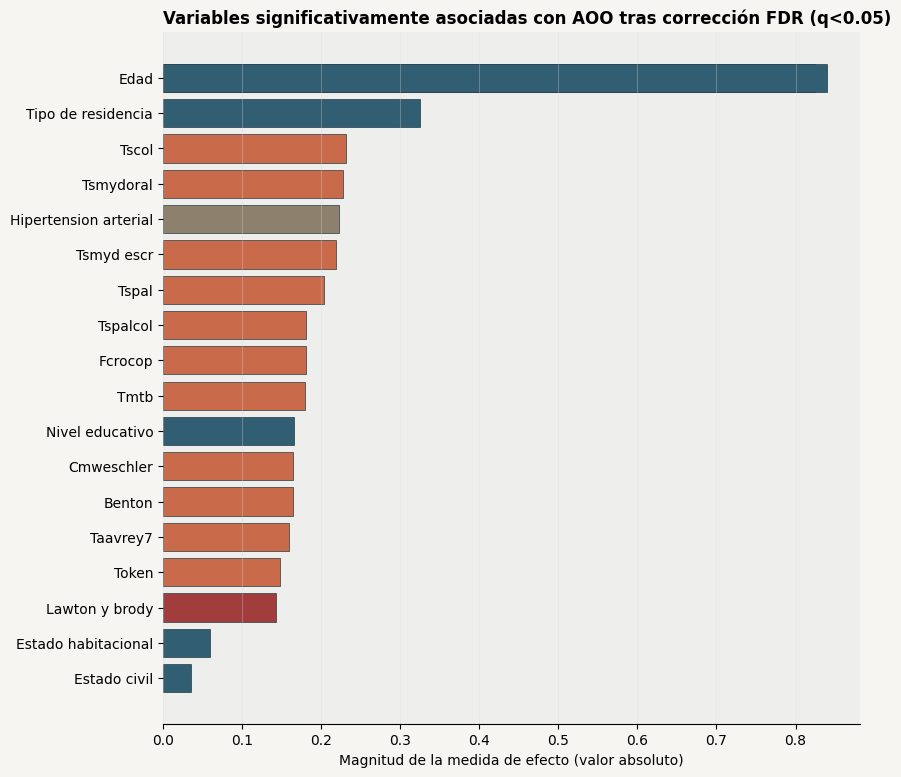

In [75]:
sig = evaluables.loc[evaluables.significativo_fdr_005].copy()
if sig.empty:
    display(Markdown('Ninguna variable resultó significativa tras la corrección por FDR (q<0.05).'))
else:
    sig['efecto_abs'] = sig['medida_efecto'].abs()
    sig = sig.sort_values('efecto_abs')
    colores_riesgo = {'Bajo': COLOR, 'Bajo / revisar temporalidad': COLOR,
                       'Revisar temporalidad': '#8d806c', 'Potencial': '#c96b4a',
                       'Alto': '#a13d3d', 'Revisar': COLOR_SUAVE}
    colores = [colores_riesgo.get(r, COLOR_SUAVE) for r in sig.riesgo_leakage_aoo]
    fig, ax = plt.subplots(figsize=(9, max(3.5, .42 * len(sig) + 1)))
    fig.patch.set_facecolor(FONDO_FIGURA)
    ax.set_facecolor(FONDO_PANEL)
    ax.barh(sig.variable, sig.efecto_abs, color=colores, edgecolor='#263b43', linewidth=.5)
    ax.set_xlabel('Magnitud de la medida de efecto (valor absoluto)')
    ax.set_title('Variables significativamente asociadas con AOO tras corrección FDR (q<0.05)',
                 loc='left', fontweight='bold')
    ax.grid(axis='x', color='#d8dcda', lw=.8); ax.grid(axis='y', visible=False)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in
               ['Bajo', 'Revisar temporalidad', 'Potencial', 'Alto']]
    plt.tight_layout(); plt.show()
    display(Markdown(
        '**Color por riesgo de leakage:** azul = Bajo, café = Revisar temporalidad, '
        'naranja = Potencial, rojo = Alto. Solo las barras azules son candidatas razonables '
        'a covariables *previas* al inicio; el resto requiere validar temporalidad o refleja '
        'estado clínico contemporáneo.'))


#### **Hallazgos principales**


### **22.16. Resumen de hallazgos bivariados y pendientes**

Se caracteriza el conjunto completo de pruebas bivariadas realizadas, sin seleccionar predictores finales ni construir un modelo: esa etapa corresponde a una fase multivariada posterior (para la cual ya están importados `StandardScaler`, `PCA`, `KMeans` y `statsmodels`, aún sin usar), que además deberá incorporar las variables genéticas mencionadas en el objetivo general una vez estén disponibles y merged (Sección 23, discrepancia formal ya documentada en la Sección 3).


In [ ]:
resumen_22 = pd.DataFrame([{
    'pacientes_cohorte': len(base_full),
    'AOO_disponible': int(base_full['aoo'].notna().sum()),
    'variables_evaluadas_bivariado': len(tabla_global_bivariado),
    'variables_evaluables': len(evaluables),
    'variables_no_evaluables': len(no_evaluables),
    'significativas_p_crudo_005': int((evaluables.p_valor < .05).sum()),
    'significativas_fdr_005': int(evaluables.significativo_fdr_005.sum())
}])
display(resumen_22)

if no_evaluables.empty:
    display(Markdown('**Variables no evaluables:** ninguna.'))
else:
    display(Markdown('**Variables no evaluables para prueba formal, con motivo:**'))
    display(no_evaluables[['variable', 'familia', 'tipo_analitico', 'motivo']].reset_index(drop=True))

assert len(base_full) == 391 and base_full['id'].is_unique


> **NOTA METODOLÓGICA:** todos los resultados de esta sección son preliminares en dos sentidos: (1) la AOO solo está disponible para el 85.2% de la cohorte maestra, sin imputar; (2) varias covariables con asociación estadística (incluidas las de riesgo «Alto»/«Potencial») no tienen su temporalidad confirmada respecto al inicio de la enfermedad, por lo que ninguna asociación de esta sección debe leerse como causal o como factor de riesgo confirmado. La selección final de covariables para un modelo explicativo de AOO debe hacerse en la fase multivariada, integrando estos resultados con la validación de temporalidad pendiente y, cuando esté disponible, la información genética.
